# accDM: skąd bierze się nieregularność profilu χ²?

Notebook analizuje **surowe, zapisane fity**: sąsiedztwo w \((\log_{10}m_{\rm acc},\log_{10}f_{\rm acc})\),
parametry nuisance, granice, liniowe i jednoloopowe widma oraz test zamiany nuisance.
Nie poprawia odstających wartości ani nie uzupełnia braków interpolacją.

**Uruchomienie:** umieść plik w projekcie `lyalpha_one_loop` albo jego podkatalogu i wybierz **Run All**.
Jeżeli katalog nie zostanie znaleziony, ustaw `PROJECT_ROOT_OVERRIDE` w następnej komórce.
Potrzebne są NumPy, pandas, Matplotlib i SciPy. Do widm/P1D potrzebny jest również kod `lyalpha_pt`
z tego samego projektu oraz zapisane dane obserwacyjne. Użyj środowiska, w którym działał `fit_p1d.py`.

Domyślnie notebook **nie uruchamia CLASS ani nowych fitów**. Opcjonalny kontrolny refit jest wyłączony.
Odczyt widm i obliczenia P1D mogą potrwać kilka minut, ale dotyczą tylko wybranych sąsiedztw.
Nowe CSV, PNG i podsumowanie JSON są zapisywane do osobnego katalogu z datą w
`runs/accdm/analysis_neighbor_diagnostics/`.

Znane ścieżki bazowe:

| Środowisko | Katalog projektu |
|---|---|
| Klaster, zapisany w wynikach | `/home/2/ks405818/Master/lyalpha_one_loop` |
| Komputer lokalny, wcześniejsza konfiguracja | `/home/krzysztof/Workspace/lyalpha_one_loop` |

W każdej kampanii notebook oczekuje `manifest.csv`, `fits/<point_id>.json`, `theory/<point_id>.npz`
oraz markerów `status/fit/` i `status/theory/`. Konkretne nazwy wszystkich znanych kampanii są w konfiguracji.
Ścieżki z klastra są przenoszone do bieżącego projektu z zachowaniem części po `lyalpha_one_loop/`.

**Dwa tryby danych:** `auto` czyta dostępne kampanie. Gdy nie ma żadnego manifestu, odczytuje
`updated_hybrid_sampled_profile_likelihood.csv`. `csv` wymusza analizę tego snapshotu.
`CSV_OVERRIDE` pozwala wskazać jego inne położenie. Sam CSV wystarcza do map nuisance i wstępnej diagnostyki χ²;
brak JSON/NPZ oznacza pominięcie odpowiednich testów z podaniem przyczyny, a nie pozytywny wynik testu.


## 1. Konfiguracja

Najczęściej wystarczy zmienić katalog projektu. `SELECTED_COORDINATES=[]` wybiera przykłady automatycznie. Wpisz własne pary `(log10m, log10f)`, jeśli chcesz zbadać konkretny fragment. Współrzędne masy odpowiadają masie w GeV.

In [10]:
from pathlib import Path
from datetime import datetime, timezone
from functools import lru_cache
import hashlib
import json
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string() if hasattr(value, 'to_string') else value)

# Ustaw tę jedną ścieżkę, jeśli notebook nie znajduje się w projekcie.
PROJECT_ROOT_OVERRIDE = os.environ.get('ACCDM_PROJECT_ROOT', '')
LEGACY_PROJECT_ROOT = Path('/home/2/ks405818/Master/lyalpha_one_loop')

def find_project_root():
    if PROJECT_ROOT_OVERRIDE:
        return Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / 'lyalpha_pt').is_dir() or (p / 'runs/accdm').is_dir():
            return p
    if LEGACY_PROJECT_ROOT.is_dir():
        return LEGACY_PROJECT_ROOT
    return cwd

PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / 'runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1'
# auto: bieżące manifesty i JSON; CSV tylko gdy żaden manifest nie jest dostępny.
# csv: jawna analiza snapshotu, nawet jeżeli dostępne są kampanie.
INPUT_MODE = os.environ.get('ACCDM_DIAGNOSTIC_MODE', 'auto')
CSV_OVERRIDE = os.environ.get('ACCDM_DIAGNOSTIC_CSV', '')
SAVE_OUTPUTS = os.environ.get('ACCDM_SAVE_OUTPUTS', '1') != '0'
OUTPUT_DIR = PROJECT_ROOT / 'runs/accdm/analysis_neighbor_diagnostics' / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')

PARAMETER_NAMES = ['log_alpha_F', 'beta_F', 'alpha_bias', 'beta_bias', 'alpha_ct', 'beta_ct']
TRANSITION_LOGF = -1.0
BOUND_WARNING_FRACTION = 0.05  # próg przeglądu, nie kryterium odrzucenia
FOCUS_DELTA_CHI2 = 25.0        # dotyczy wyboru przykładów, nie pełnych tabel
MAX_STENCILS = 3
SELECTED_COORDINATES = [
        # Dwa izolowane punkty o znacznie zawyżonym chi²
    (14.7142857143, -1.375),
    (15.0000000000, -1.375),

    # Przykład gwałtownej zmiany nuisance
    (14.7142857143, -0.1),

    # Punkty z beta_bias na granicy, blisko konturu 5.991
    (17.1428571429, -0.3),
    (17.2857142857, -0.2),

]     # np. [(14.7142857142857, -1.375), (15., -1.375)]
RUN_SPECTRA = True
RUN_CROSS_EVALUATION = True
RUN_TARGETED_REFITS = True   # opcjonalne; bez CLASS, na zapisanej teorii
REFIT_MAX_NFEV = 3000
DIAGONAL_ATOL = 1e-4
DIAGONAL_RTOL = 1e-7
CROSS_IMPROVEMENT_TOL = 1e-3  # tolerancja diagnozy optymalizatora, nie próg statystyczny
FIT_CONFIG_OVERRIDE = {}      # tylko świadome uzupełnienie brakujących metadanych

# region/priorytety zachowują wybór kampanii z notebooków 05 i 08.
_campaign_specs = [
    ('low_q1001', 'accdm_scan_lowf_q1001_v2', 'low', 1001, 10),
    ('low_q2501_recovery', 'accdm_lowf_recovery_q2501_10core_v1', 'low', 2501, 20),
    ('high_q5001_original', 'accdm_scan_highf_q5001_v1', 'high', 5001, 10),
    ('high_q5001_recovery_10core', 'accdm_scan_highf_q5001_recovery_10core_v1', 'high', 5001, 20),
    ('high_q5001_pilot_20core', 'accdm_highf_q5001_20core_pilot_v2', 'high', 5001, 30),
    ('high_q5001_special_20core', 'accdm_highf_q5001_20core_recovery_v2', 'high', 5001, 30),
    ('loweps_low_q1001', 'accdm_scan_loweps_lowf_q1001_v1', 'low', 1001, 100),
    ('loweps_high_q5001', 'accdm_scan_loweps_highf_q5001_v1', 'high', 5001, 100),
    ('high_q1001_scout', 'accdm_scan_highf_q1001_scout_v1', 'diagnostic', 1001, 0),
]
CAMPAIGNS = [dict(label=l, directory=PROJECT_ROOT / 'runs/accdm' / d,
                  region=r, momentum_bins=q, priority=p) for l,d,r,q,p in _campaign_specs]

def remap_path(value):
    """Przenieś ścieżkę klastra do bieżącego projektu; nie wyszukuj po samej nazwie."""
    if value is None or (not isinstance(value, (str, Path)) and pd.isna(value)):
        return None
    raw = str(value).strip()
    if not raw or raw.lower() == 'nan':
        return None
    p = Path(raw).expanduser()
    if not p.is_absolute():
        return PROJECT_ROOT / p
    # Najpierw lokalna kopia projektu, potem oryginalna ścieżka.
    marker = '/lyalpha_one_loop/'
    if marker in raw:
        candidate = PROJECT_ROOT / raw.split(marker, 1)[1]
        if candidate.exists() or not p.exists():
            return candidate
    return p

def coord_key(m, f):
    return f'{float(m):.10f}|{float(f):.10f}'

def bool_value(value):
    if value is None or pd.isna(value):
        return None
    text = str(value).strip().lower()
    if text in {'true', '1', '1.0', 'yes'}: return True
    if text in {'false', '0', '0.0', 'no'}: return False
    return None

def number(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def save_table(name, frame):
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        frame.to_csv(OUTPUT_DIR / f'{name}.csv', index=False)

def show_figure(name, fig):
    fig.tight_layout()
    if SAVE_OUTPUTS:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(OUTPUT_DIR / f'{name}.png', dpi=170, bbox_inches='tight')
    plt.show()
    plt.close(fig)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .15})
print('Projekt:', PROJECT_ROOT)
print('Tryb:', INPUT_MODE)
print('Wyniki:', OUTPUT_DIR if SAVE_OUTPUTS else 'zapis wyłączony')


Projekt: /home/2/ks405818/Master/lyalpha_one_loop
Tryb: auto
Wyniki: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_neighbor_diagnostics/20260923T090610_432416Z


## 2. Odczyt kampanii i pochodzenie punktów

Wybór odpowiada notebookom 05/08: low-f korzysta z Nq=1001 i celowanych odzysków Nq=2501,
high-f z Nq=5001. Scout high-f Nq=1001 pozostaje w inwentarzu, ale nie zastępuje głównego profilu.
Nq oznacza liczbę binów **pędów CLASS**, nie siatkę całki jednoloopowej.

Przy kilku ukończonych fitach tego samego punktu decyduje jawny priorytet kampanii, następnie nazwa źródła.
Remisy są oznaczane, wszystkie duplikaty zachowane. Nie wybieramy innej teorii tylko dlatego, że dała niższe χ².
Nie odrzucamy fitów z dużym χ², `optimizer_success=False` albo nuisance blisko granicy.
Plik z markerem niepowodzenia nie jest ukończonym fitem. Zakres inwentarza obejmuje dostępne manifesty;
brak całej kampanii nie oznacza, że jej punkty nigdy nie istniały.


In [11]:
PAYLOADS = {}
LOAD_ERRORS = []
BOUND_ROWS = []

def read_fit(path):
    path = Path(path)
    if str(path) not in PAYLOADS:
        PAYLOADS[str(path)] = json.loads(path.read_text(encoding='utf-8'))
    return PAYLOADS[str(path)]

def parse_fit(path):
    payload = read_fit(path)
    fit = payload.get('fits', {}).get('one_loop', {})
    chi2 = number(fit.get('chi2'))
    if not np.isfinite(chi2):
        raise ValueError('Brak skończonego fits.one_loop.chi2')
    out = {'chi2_one_loop': chi2, 'optimizer_success': bool_value(fit.get('optimizer_success')),
           'optimizer_message': fit.get('optimizer_message'),
           'chi2_linear': number(payload.get('fits', {}).get('linear', {}).get('chi2')),
           'covariance_mode': fit.get('covariance_mode'),
           'k_uv_cut_hmpc': number(fit.get('k_uv_cut_hmpc')),
           'theory_digest': fit.get('theory_digest'),
           'metadata_source': 'fit_json'}
    starts = np.array([number(x) for x in fit.get('multistart_chi2', [])])
    starts = np.sort(starts[np.isfinite(starts)])
    out['multistart_count'] = len(starts)
    if len(starts):
        out['multistart_best'] = starts[0]
        out['multistart_span'] = starts[-1]-starts[0]
        out['multistart_second_gap'] = starts[1]-starts[0] if len(starts)>1 else np.nan
    out['search_candidates_json'] = json.dumps(fit.get('search_candidates', []), ensure_ascii=False)
    out['fit_stages_json'] = json.dumps(fit.get('fit_stages', []), ensure_ascii=False)
    for name, val in fit.get('parameters', {}).items():
        out['parameter_' + name] = number(val)
    diagnostics = fit.get('boundary_diagnostics', [])
    distances = []
    for d in diagnostics:
        name = d['parameter']
        lower, upper = number(d.get('lower')), number(d.get('upper'))
        value = out.get('parameter_' + name, number(d.get('value')))
        width = upper - lower
        distance = min(value-lower, upper-value) / width if width > 0 else np.nan
        out['parameter_box_width_' + name] = width
        out['lower_' + name], out['upper_' + name] = lower, upper
        out['bound_distance_' + name] = distance
        if np.isfinite(distance):
            distances.append((distance, name))
    if distances:
        out['minimum_bound_distance'], out['minimum_bound_parameter'] = min(distances)
    return out

inventory_rows = []
campaign_rows = []
for source in CAMPAIGNS:
    directory = source['directory']
    manifest = directory / 'manifest.csv'
    campaign_rows.append(dict(source=source['label'], directory=str(directory), manifest_exists=manifest.is_file()))
    if INPUT_MODE == 'csv' or not manifest.is_file():
        continue
    records = pd.read_csv(manifest)
    for r in records.to_dict('records'):
        if 'active' in r and bool_value(r['active']) is not True:
            continue
        point = str(r['point_id'])
        fp, tp = directory/'fits'/f'{point}.json', directory/'theory'/f'{point}.npz'
        row = dict(r, coordinate_key=coord_key(r['log10m_acc'], r['log10f_acc']),
                   source_label=source['label'], source_priority=source['priority'],
                   policy_region=source['region'], source_directory=str(directory),
                   momentum_bins=source['momentum_bins'], fit_path=str(fp), theory_path=str(tp),
                   chi2_one_loop=np.nan)
        for stage, path in [('fit', fp), ('theory', tp)]:
            failed = (directory/'status'/stage/f'{point}.failed.json').is_file()
            done = (directory/'status'/stage/f'{point}.done.json').is_file()
            row[stage+'_failed'] = failed
            row[stage+'_complete'] = path.is_file() and done and not failed
            row[stage+'_file_exists'] = path.is_file()
        if row['fit_complete']:
            try:
                row.update(parse_fit(fp))
            except Exception as exc:
                LOAD_ERRORS.append(dict(path=str(fp), error=str(exc)))
                row['fit_parse_failed'] = True
        inventory_rows.append(row)

campaign_inventory = pd.DataFrame(campaign_rows)
display(campaign_inventory)
if INPUT_MODE not in {'auto', 'csv'}:
    raise ValueError("INPUT_MODE musi być 'auto' albo 'csv'.")

csv_path = None
if inventory_rows:
    inventory = pd.DataFrame(inventory_rows)
    input_origin = 'live_campaigns'
    expected_complete = True
else:
    if INPUT_MODE == 'auto' and campaign_inventory.manifest_exists.any():
        raise RuntimeError('Manifesty istnieją, lecz nie zawierają aktywnych punktów. Nie zastępuję ich snapshotem.')
    candidates = ([Path(CSV_OVERRIDE).expanduser()] if CSV_OVERRIDE else [
        ANALYSIS_DIR/'updated_hybrid_sampled_profile_likelihood.csv',
        PROJECT_ROOT/'updated_hybrid_sampled_profile_likelihood.csv',
        Path.cwd()/'updated_hybrid_sampled_profile_likelihood.csv'])
    csv_path = next((p for p in candidates if p.is_file()), None)
    if csv_path is None:
        raise FileNotFoundError('Brak manifestów i tabeli CSV. Ustaw PROJECT_ROOT_OVERRIDE lub CSV_OVERRIDE w konfiguracji.')
    inventory = pd.read_csv(csv_path)
    input_origin = 'csv_snapshot'
    expected_complete = False
    inventory['metadata_source'] = 'csv_snapshot'
    required = {'log10m_acc', 'log10f_acc', 'chi2_one_loop'}
    if not required.issubset(inventory):
        raise ValueError(f'CSV nie zawiera: {sorted(required-set(inventory.columns))}')
    inventory['coordinate_key'] = [coord_key(m,f) for m,f in zip(inventory.log10m_acc, inventory.log10f_acc)]
    if 'source_label' not in inventory:
        inventory['source_label'] = 'snapshot'
    inventory['policy_region'] = np.where(inventory.log10f_acc <= TRANSITION_LOGF, 'low', 'high')
    # Snapshot pozostaje snapshotem: JSON uzupełnia brakujące metadane tylko przy zgodnym χ².
    for idx, row in inventory.iterrows():
        fp = remap_path(row.get('fit_path'))
        if fp is not None and fp.is_file():
            try:
                detail = parse_fit(fp)
                if not np.isclose(detail['chi2_one_loop'], row['chi2_one_loop'], atol=DIAGONAL_ATOL, rtol=DIAGONAL_RTOL):
                    raise ValueError('Bieżący JSON ma inne χ² niż snapshot. Użyj trybu auto dla bieżących wyników.')
                for key, val in detail.items():
                    inventory.loc[idx, key] = val
            except Exception as exc:
                LOAD_ERRORS.append(dict(path=str(fp), error=str(exc)))
    # Tabela braków umożliwia niewiązanie sąsiadów przez niedokończone punkty.
    missing_path = csv_path.with_name('updated_hybrid_cross_markers.csv')
    if missing_path.is_file():
        missing = pd.read_csv(missing_path)
        if {'log10m_acc','log10f_acc'}.issubset(missing):
            missing['coordinate_key'] = [coord_key(m,f) for m,f in zip(missing.log10m_acc, missing.log10f_acc)]
            missing['chi2_one_loop'] = np.nan
            missing['policy_region'] = np.where(missing.log10f_acc <= TRANSITION_LOGF, 'low', 'high')
            missing['source_label'] = 'missing_snapshot'
            inventory = pd.concat([inventory, missing], ignore_index=True, sort=False)
            expected_complete = True

for c in ['source_priority','momentum_bins']:
    if c not in inventory:
        inventory[c] = np.nan
    inventory[c] = pd.to_numeric(inventory[c], errors='coerce')
inventory['chi2_one_loop'] = pd.to_numeric(inventory['chi2_one_loop'], errors='coerce')
for c in ['fit_path','theory_path']:
    if c not in inventory:
        inventory[c] = None
    inventory[c] = inventory[c].map(lambda x: str(remap_path(x)) if remap_path(x) is not None else None)
    inventory[c.replace('_path','_available')] = inventory[c].map(lambda x: Path(x).is_file() if x else False)
inventory[['log10m_acc','log10f_acc']] = inventory[['log10m_acc','log10f_acc']].astype(float).round(10)
eligible = ((inventory.policy_region == 'low') & (inventory.log10f_acc <= TRANSITION_LOGF+1e-10)) | ((inventory.policy_region == 'high') & (inventory.log10f_acc > TRANSITION_LOGF+1e-10))
expected = inventory.loc[eligible, ['coordinate_key','log10m_acc','log10f_acc']].drop_duplicates('coordinate_key')
valid = eligible & np.isfinite(pd.to_numeric(inventory.chi2_one_loop, errors='coerce'))
for col in ['fit_failed','theory_failed']:
    if col in inventory:
        valid &= ~inventory[col].map(bool_value).eq(True)
if 'fit_complete' in inventory:
    valid &= inventory.fit_complete.map(bool_value).eq(True)
candidates = inventory.loc[valid].copy()
if candidates.empty:
    raise RuntimeError('Nie ma ukończonych, skończonych fitów spełniających politykę wyboru. Sprawdź inventory i LOAD_ERRORS.')
candidates['_priority'] = candidates.source_priority.fillna(-1)
candidates = candidates.sort_values(['coordinate_key','_priority','source_label'])
duplicates = candidates.loc[candidates.duplicated('coordinate_key', keep=False)].copy()
points = candidates.drop_duplicates('coordinate_key', keep='last').drop(columns='_priority').reset_index(drop=True)
points['delta_chi2_sampled'] = points.chi2_one_loop - points.chi2_one_loop.min()
points['selection_tie'] = [sum((candidates.coordinate_key == r.coordinate_key) & (candidates._priority == (r.source_priority if pd.notna(r.source_priority) else -1))) > 1 for r in points.itertuples()]
points = points.set_index('coordinate_key', drop=False)
for name in PARAMETER_NAMES:
    for col in ['parameter_'+name, 'parameter_box_width_'+name, 'bound_distance_'+name, 'lower_'+name, 'upper_'+name]:
        if col not in points:
            points[col] = np.nan
for col in ['minimum_bound_distance','optimizer_success']:
    if col not in points:
        points[col] = np.nan

print(f'Źródło: {input_origin}; ukończone punkty: {len(points)}; oczekiwane/zidentyfikowane: {len(expected)}')
print('Dostępne JSON / NPZ:', int(points.fit_available.sum()), '/', int(points.theory_available.sum()))
print('Siatka oczekiwana znana w zakresie dostępnych manifestów/tabeli braków:', expected_complete)
print('Błędy odczytu:', len(LOAD_ERRORS), '; punkty z remisem priorytetu:', int(points.selection_tie.sum()))
if not expected_complete:
    print('Sąsiedztwo dotyczy znanych punktów. Duże luki są oznaczane; nie zakładamy, że snapshot zawiera całą siatkę.')
display(points.groupby(['source_label','momentum_bins'], dropna=False).size().rename('points').to_frame())
if LOAD_ERRORS:
    display(pd.DataFrame(LOAD_ERRORS).head(10))
save_table('campaign_inventory', campaign_inventory)
save_table('all_records', inventory)
save_table('source_duplicates', duplicates)
save_table('selected_raw_points', points)
save_table('load_errors', pd.DataFrame(LOAD_ERRORS))


,source,directory,manifest_exists
0,low_q1001,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
1,low_q2501_recovery,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
2,high_q5001_original,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
3,high_q5001_recovery_10core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
4,high_q5001_pilot_20core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
5,high_q5001_special_20core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
6,loweps_low_q1001,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
7,loweps_high_q5001,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True
8,high_q1001_scout,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,True


Źródło: live_campaigns; ukończone punkty: 1600; oczekiwane/zidentyfikowane: 1740
Dostępne JSON / NPZ: 1600 / 1600
Siatka oczekiwana znana w zakresie dostępnych manifestów/tabeli braków: True
Błędy odczytu: 0 ; punkty z remisem priorytetu: 0


,,points
source_label,momentum_bins,
high_q5001_original,5001,99
high_q5001_recovery_10core,5001,476
low_q1001,1001,842
low_q2501_recovery,2501,8
loweps_high_q5001,5001,8
loweps_low_q1001,1001,167


## 3. Bezpośredni sąsiedzi i ranking nieregularności

Sąsiedzi leżą w kolejnym punkcie tej samej osi siatki, przy drugim parametrze stałym.
Jeśli znamy brakujący punkt pomiędzy nimi, nie tworzymy krawędzi przez tę lukę.
Przy samym snapshotcie bez tabeli braków nie da się udowodnić kompletności siatki;
odstępy większe niż 1,6 mediany odstępów na przekroju są dodatkowo oznaczone jako `large_gap`.

Dla trójki \(x_-<x_0<x_+\) zapisujemy
\[
R=\chi^2(x_0)-\left[\chi^2(x_-)+\frac{x_0-x_-}{x_+-x_-}\bigl(\chi^2(x_+)-\chi^2(x_-)\bigr)\right].
\]
To miara lokalnej krzywizny używana **do wyboru miejsc do sprawdzenia**, nie estymator błędu ani dowód artefaktu.
Prawdziwe minimum również może mieć duże \(|R|\). Tabele zachowują zmianę źródła oraz Nq.
Automatyczny wybór obejmuje trzy podejrzane miejsca i jedno gładkie miejsce kontrolne.


In [12]:
# Krawędzie i trójki z kolejnych punktów oczekiwanej siatki w oryginalnych osiach.
# Brakujący fit przerywa krawędź. Bez interpolowania braków i bez poprawiania χ².
pair_rows, triple_rows = [], []
for axis, fixed in [('log10m_acc','log10f_acc'), ('log10f_acc','log10m_acc')]:
    for value, group in expected.groupby(fixed):
        group = group.sort_values(axis)
        keys, x = group.coordinate_key.tolist(), group[axis].to_numpy(float)
        spacings = np.diff(x)
        base_step = np.median(spacings[spacings > 1e-9]) if np.any(spacings > 1e-9) else np.nan
        for a,b,xa,xb in zip(keys[:-1],keys[1:],x[:-1],x[1:]):
            if a not in points.index or b not in points.index or xb <= xa:
                continue
            ra, rb = points.loc[a], points.loc[b]
            dchi = rb.chi2_one_loop-ra.chi2_one_loop
            row = dict(a=a,b=b,axis=axis,fixed_value=value,step=xb-xa,
                       large_gap=(xb-xa)>1.6*base_step,delta_chi2=dchi,abs_delta_chi2=abs(dchi),
                       slope=dchi/(xb-xa),source_a=ra.source_label,source_b=rb.source_label,
                       source_changed=ra.source_label != rb.source_label,
                       momentum_bins_a=ra.momentum_bins,momentum_bins_b=rb.momentum_bins,
                       resolution_changed=(ra.momentum_bins != rb.momentum_bins) if pd.notna(ra.momentum_bins) and pd.notna(rb.momentum_bins) else None,
                       min_delta_chi2=min(ra.delta_chi2_sampled,rb.delta_chi2_sampled))
            shifts=[]
            for name in PARAMETER_NAMES:
                va,vb=ra['parameter_'+name],rb['parameter_'+name]
                wa,wb=ra['parameter_box_width_'+name],rb['parameter_box_width_'+name]
                equal_width=np.isfinite(wa) and np.isfinite(wb) and wa>0 and np.isclose(wa,wb)
                shift=(vb-va)/wa if equal_width else np.nan
                row['shift_'+name]=vb-va
                row['box_shift_'+name]=shift
                if np.isfinite(shift): shifts.append(abs(shift))
            row['max_abs_box_shift']=max(shifts,default=np.nan)
            pair_rows.append(row)
        for i in range(1,len(keys)-1):
            a,b,c=keys[i-1:i+2]
            if not all(k in points.index for k in (a,b,c)):
                continue
            xa,xb,xc=x[i-1:i+2]
            if not xa<xb<xc: continue
            ya,yb,yc=[points.loc[k,'chi2_one_loop'] for k in (a,b,c)]
            weight=(xb-xa)/(xc-xa)
            baseline=ya+(yc-ya)*weight
            sources=points.loc[[a,b,c],'source_label']
            q=points.loc[[a,b,c],'momentum_bins']
            triple_rows.append(dict(center=b,left=a,right=c,axis=axis,fixed_value=value,
                x=xb,chi2=yb,linear_neighbor_baseline=baseline,roughness=yb-baseline,
                abs_roughness=abs(yb-baseline),left_step=xb-xa,right_step=xc-xb,
                large_gap=max(xb-xa,xc-xb)>1.6*base_step,
                is_local_extremum=(yb-ya)*(yc-yb)<0,
                source_changed=sources.nunique()>1,
                resolution_changed=q.nunique()>1,
                min_delta_chi2=min(ya,yb,yc)-points.chi2_one_loop.min()))
pairs=pd.DataFrame(pair_rows)
triples=pd.DataFrame(triple_rows)
if pairs.empty:
    raise RuntimeError('Brak osiowych par sąsiadów. Sprawdź siatkę i współrzędne.')
if triples.empty:
    raise RuntimeError('Brak pełnych trójek sąsiadów potrzebnych do rankingu. Potrzebne są co najmniej 3 punkty na przekroju.')
ranked=triples.sort_values('abs_roughness',ascending=False).reset_index(drop=True)
point_roughness=triples.groupby('center').abs_roughness.max()
points['roughness_max']=points.index.map(point_roughness)
save_table('neighbor_pairs',pairs)
save_table('neighbor_triples',ranked)
display(ranked.head(20))

if SELECTED_COORDINATES:
    center_keys=[coord_key(m,f) for m,f in SELECTED_COORDINATES]
    unknown=[k for k in center_keys if k not in points.index]
    if unknown: raise ValueError(f'Wybrane współrzędne nie mają ukończonego fitu: {unknown}')
else:
    focus=ranked.loc[(ranked.min_delta_chi2<=FOCUS_DELTA_CHI2)&(~ranked.large_gap)]
    center_keys=[]
    covered=set()
    for r in focus.itertuples():
        if r.center in covered: continue
        center_keys.append(r.center)
        covered.update([r.left,r.center,r.right])
        if len(center_keys)>=MAX_STENCILS: break
    if not center_keys:
        fallback=ranked.loc[~ranked.large_gap]
        if not fallback.empty: center_keys=[fallback.iloc[0].center]

stencils=[]
for center in center_keys:
    adjacent=pairs.loc[((pairs.a==center)|(pairs.b==center))&(~pairs.large_gap)]
    keys=[center]+sorted(set(adjacent.a).union(adjacent.b)-{center})
    stencils.append(dict(center=center,keys=keys,kind='suspect'))
# Kontrolny punkt o małej lokalnej krzywiźnie w istotnej części profilu.
occupied=set(k for s in stencils for k in s['keys'])
control=ranked.loc[(ranked.min_delta_chi2<=FOCUS_DELTA_CHI2)&(~ranked.large_gap)&(~ranked.source_changed)&(~ranked.center.isin(occupied))].sort_values('abs_roughness')
if not control.empty:
    c=control.iloc[0]
    stencils.append(dict(center=c.center,keys=[c.center,c.left,c.right],kind='control'))
selected_keys=list(dict.fromkeys(k for s in stencils for k in s['keys']))
selected_points=points.loc[selected_keys].copy()
selected_points['stencil_membership']=[';'.join(f"{i}:{s['kind']}" for i,s in enumerate(stencils) if k in s['keys']) for k in selected_keys]
save_table('selected_stencil_points',selected_points)
print('Punkty do widm i testów nuisance:',len(selected_keys))
display(selected_points[['log10m_acc','log10f_acc','chi2_one_loop','minimum_bound_distance','optimizer_success','fit_available','theory_available','stencil_membership']])


,center,left,right,axis,fixed_value,x,chi2,linear_neighbor_baseline,roughness,abs_roughness,left_step,right_step,large_gap,is_local_extremum,source_changed,resolution_changed,min_delta_chi2
0,16.0000000000|0.0000000000,15.8571428571|0.0000000000,16.1428571429|0.0000000000,log10m_acc,0.000000,16.000000,827.847664,732.867341,94.980323,94.980323,0.142857,0.142857,False,True,False,False,491.085955
1,16.1428571429|-0.3000000000,16.1428571429|-0.4000000000,16.1428571429|-0.2000000000,log10f_acc,16.142857,-0.300000,450.467397,370.159521,80.307876,80.307876,0.100000,0.100000,False,True,False,False,114.484058
2,16.2857142857|-0.3000000000,16.2857142857|-0.4000000000,16.2857142857|-0.2000000000,log10f_acc,16.285714,-0.300000,350.648563,272.428804,78.219759,78.219759,0.100000,0.100000,False,True,False,False,53.746489
3,16.1428571429|-0.3000000000,16.0000000000|-0.3000000000,16.2857142857|-0.3000000000,log10m_acc,-0.300000,16.142857,450.467397,381.694166,68.773231,68.773231,0.142857,0.142857,False,True,False,False,162.218966
4,16.4285714286|-0.2000000000,16.4285714286|-0.3000000000,16.4285714286|-0.1000000000,log10f_acc,16.428571,-0.200000,292.896977,227.880591,65.016386,65.016386,0.100000,0.100000,False,True,False,False,26.817183
5,16.2857142857|-0.2000000000,16.1428571429|-0.2000000000,16.4285714286|-0.2000000000,log10m_acc,-0.200000,16.285714,302.681522,365.151182,-62.469660,62.469660,0.142857,0.142857,False,False,False,False,104.467379
6,16.4285714286|-0.3000000000,16.2857142857|-0.3000000000,16.5714285714|-0.3000000000,log10m_acc,-0.300000,16.428571,215.246780,276.868750,-61.621970,61.621970,0.142857,0.142857,False,False,False,False,14.659340
7,16.1428571429|0.0000000000,16.0000000000|0.0000000000,16.2857142857|0.0000000000,log10m_acc,0.000000,16.142857,679.515552,624.102465,55.413087,55.413087,0.142857,0.142857,False,False,False,False,231.927669
8,16.4285714286|0.0000000000,16.2857142857|0.0000000000,16.5714285714|0.0000000000,log10m_acc,0.000000,16.428571,262.590710,316.512745,-53.922036,53.922036,0.142857,0.142857,False,False,False,False,24.238627
9,16.1428571429|-0.4000000000,16.1428571429|-0.4750000000,16.1428571429|-0.3000000000,log10f_acc,16.142857,-0.400000,302.913656,356.221980,-53.308324,53.308324,0.075000,0.100000,False,False,False,False,97.108319


Punkty do widm i testów nuisance: 23


,log10m_acc,log10f_acc,chi2_one_loop,minimum_bound_distance,optimizer_success,fit_available,theory_available,stencil_membership
coordinate_key,,,,,,,,
14.7142857143|-1.3750000000,14.714286,-1.375,228.833338,1.288367e-01,True,True,True,0:suspect
14.5714285714|-1.3750000000,14.571429,-1.375,192.334840,2.868022e-01,True,True,True,0:suspect
14.7142857143|-1.3000000000,14.714286,-1.300,191.786268,2.840000e-01,True,True,True,0:suspect
14.7142857143|-1.4500000000,14.714286,-1.450,192.094637,2.890047e-01,True,True,True,0:suspect
14.8571428571|-1.3750000000,14.857143,-1.375,192.735457,2.755300e-01,True,True,True,0:suspect;1:suspect
15.0000000000|-1.3750000000,15.000000,-1.375,231.245070,1.268348e-01,True,True,True,1:suspect
15.0000000000|-1.3000000000,15.000000,-1.300,194.034045,2.737055e-01,True,True,True,1:suspect
15.0000000000|-1.4500000000,15.000000,-1.450,193.483125,2.937934e-01,True,True,True,1:suspect
15.1428571429|-1.3750000000,15.142857,-1.375,193.720937,2.798692e-01,True,True,True,1:suspect


## 4. χ², wartości nuisance i bliskość granic

Wszystkie mapy pokazują rzeczywiście zapisane punkty. Czerwone okręgi oznaczają wybrane miejsca,
czarny — kontrolę. Obcięcie koloru mapy Δχ² do 25 nie zmienia liczb w tabelach ani rankingu.
Δχ² jest liczone względem najmniejszego χ² dostępnej próbki, bez przypisywania poziomów ufności.

Odległość od granicy to \(d=\min(\eta-L,U-\eta)/(U-L)\), w parametryzacji optymalizatora.
`log_alpha_F` jest współrzędną logarytmiczną. Próg 5% oznacza potrzebę przeglądu, a nie odrzucenie punktu.
Duży skok nuisance może wynikać z degeneracji. Granica fizyczna może definiować poprawne minimum ograniczone.
Pełne granice każdego nuisance są odczytywane z `boundary_diagnostics` w JSON.
CSV ze znaną tylko najbliższą granicą nie wystarcza do odtworzenia wszystkich sześciu zakresów.
`optimizer_audit.csv` zachowuje status, komunikat, rozrzut `multistart_chi2` i historię etapów, jeśli są zapisane.
Lista wyników startowych może obejmować etapy kontynuacji; zerowy odstęp między dwoma najlepszymi wynikami
nie dowodzi osiągnięcia minimum globalnego.


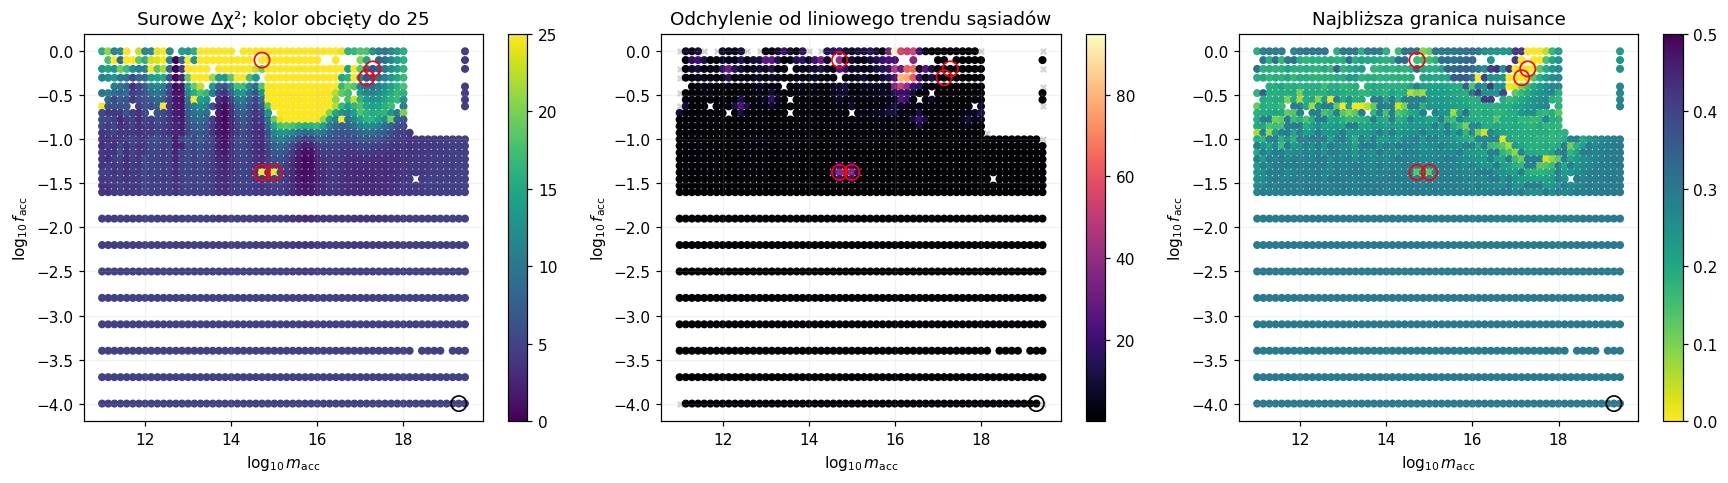

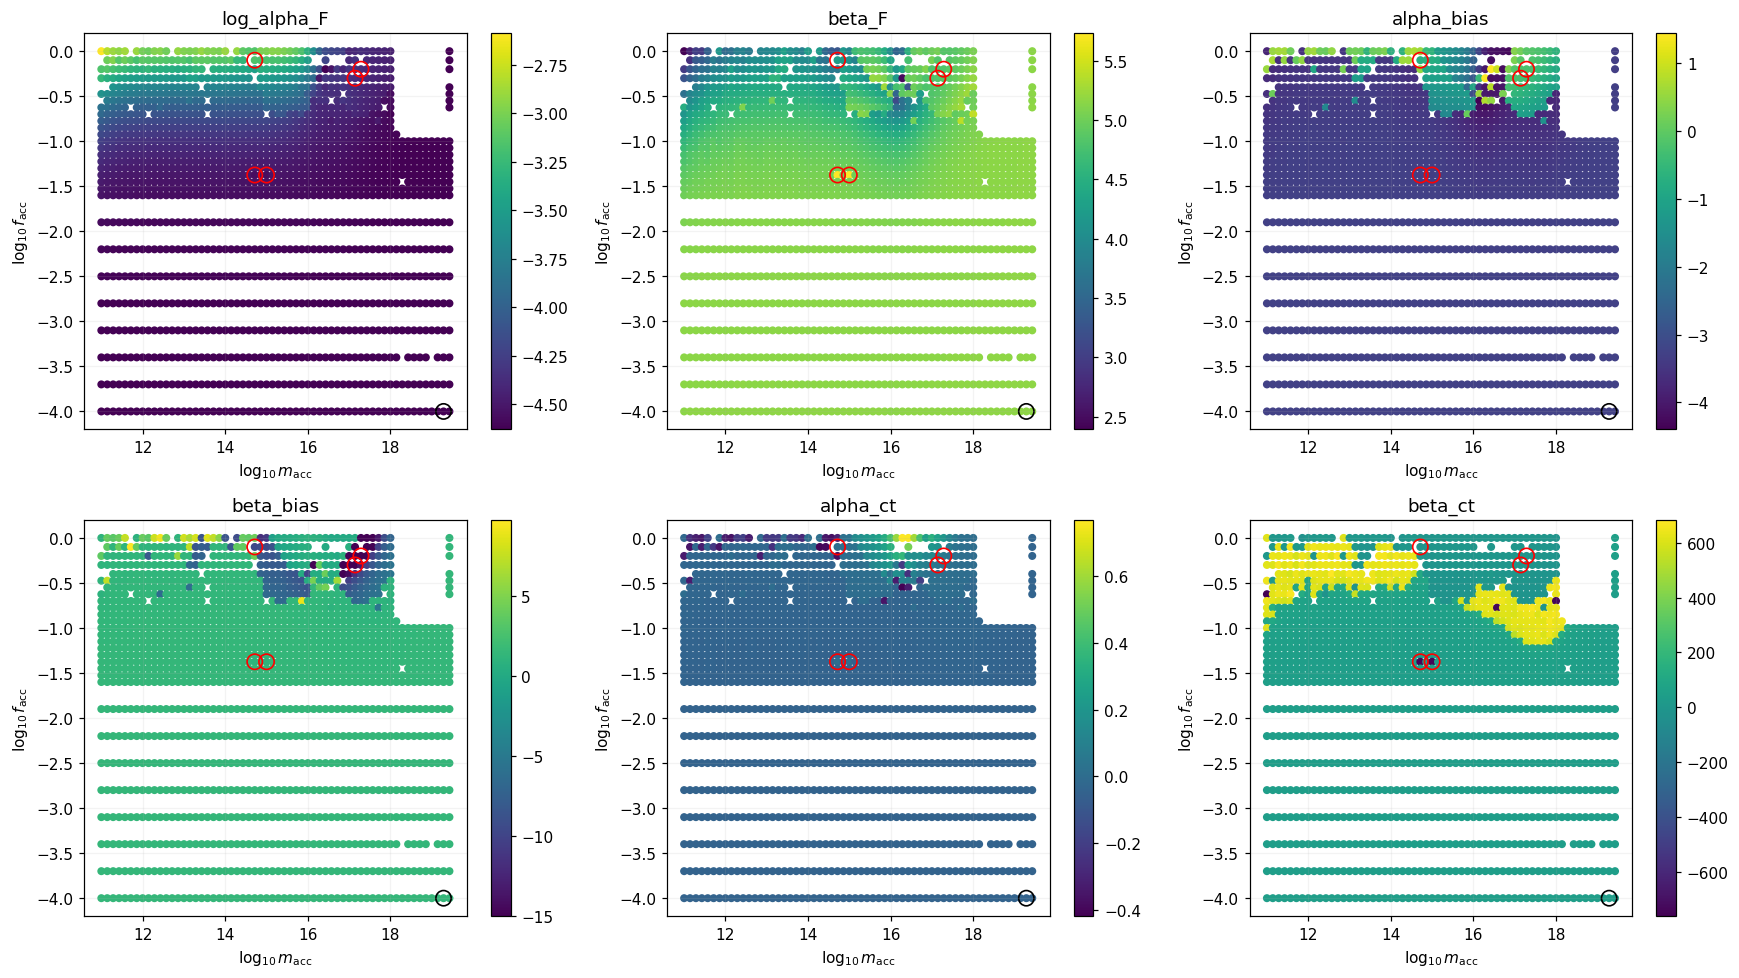

Rozrzut zapisanych startów (może obejmować etapy kontynuacji):


,coordinate_key,log10m_acc,log10f_acc,chi2_one_loop,optimizer_success,optimizer_message,multistart_count,multistart_best,multistart_span,multistart_second_gap,search_candidates_json,fit_stages_json
coordinate_key,,,,,,,,,,,,
16.2857142857|0.0000000000,16.2857142857|0.0000000000,16.285714,0.00,420.357266,True,profiled continuation; selected nelder-mead,10.0,420.357266,217.406000,1.136868e-13,"[{""chi2"": 420.3572664073939, ""source"": ""contin...","[{""chi2"": 420.3572664073937, ""stage"": ""base""},..."
16.1428571429|-0.2000000000,16.1428571429|-0.2000000000,16.142857,-0.20,437.405387,True,profiled continuation; selected nelder-mead,10.0,437.405387,178.500217,5.684342e-14,"[{""chi2"": 437.4053867274456, ""source"": ""contin...","[{""chi2"": 437.4053867274457, ""stage"": ""base""},..."
16.2857142857|-0.2000000000,16.2857142857|-0.2000000000,16.285714,-0.20,302.681522,True,profiled continuation; selected nelder-mead,10.0,302.681522,121.473510,5.684342e-14,"[{""chi2"": 302.6815220016648, ""source"": ""contin...","[{""chi2"": 302.68152200166463, ""stage"": ""base""}..."
16.4285714286|0.0000000000,16.4285714286|0.0000000000,16.428571,0.00,262.590710,True,profiled amplitudes; selected interior_de_neld...,10.0,262.590710,115.515684,1.705303e-13,"[{""chi2"": 262.59070958060863, ""source"": ""inter...","[{""chi2"": 262.5907095766087, ""stage"": ""base""},..."
16.4285714286|-0.1000000000,16.4285714286|-0.1000000000,16.428571,-0.10,240.514401,True,profiled amplitudes; selected interior_de_neld...,10.0,240.514401,84.563593,0.000000e+00,"[{""chi2"": 240.5144011877544, ""source"": ""interi...","[{""chi2"": 240.51440114935954, ""stage"": ""base""}..."
16.4285714286|-0.3000000000,16.4285714286|-0.3000000000,16.428571,-0.30,215.246780,True,profiled continuation; selected powell,10.0,215.246780,63.337246,4.831691e-13,"[{""chi2"": 215.24678022833618, ""source"": ""conti...","[{""chi2"": 215.2467802283363, ""stage"": ""base""},..."
16.1428571429|-0.4000000000,16.1428571429|-0.4000000000,16.142857,-0.40,302.913656,True,profiled amplitudes; selected interior_de_neld...,10.0,302.913656,54.634134,2.273737e-13,"[{""chi2"": 302.91365557924064, ""source"": ""inter...","[{""chi2"": 302.91365552843575, ""stage"": ""base""}..."
14.5714285714|0.0000000000,14.5714285714|0.0000000000,14.571429,0.00,214.431770,True,profiled amplitudes; selected beta_ct_upper_de...,10.0,214.431770,53.907267,0.000000e+00,"[{""chi2"": 268.33903694478704, ""source"": ""inter...","[{""chi2"": 214.4317702714076, ""stage"": ""base""},..."
16.5714285714|0.0000000000,16.5714285714|0.0000000000,16.571429,0.00,212.668225,True,profiled amplitudes; selected interior_de_neld...,10.0,212.668225,53.763083,1.989520e-13,"[{""chi2"": 212.66822464941077, ""source"": ""inter...","[{""chi2"": 212.66822462851965, ""stage"": ""base""}..."


Status najbliższej granicy (unknown oznacza brak informacji):


,points
bound_status,
above_threshold_known,1574
near,26


,log10m_acc,log10f_acc,chi2_one_loop,minimum_bound_distance,roughness_max,minimum_bound_parameter,bound_status
coordinate_key,,,,,,,
17.1428571429|-0.2000000000,17.142857,-0.2,197.520048,0.000000e+00,3.302427,beta_bias,near
17.5714285714|0.0000000000,17.571429,0.0,198.235419,0.000000e+00,1.012571,beta_bias,near
16.1428571429|-0.3000000000,16.142857,-0.3,450.467397,0.000000e+00,80.307876,beta_bias,near
17.4285714286|0.0000000000,17.428571,0.0,198.687732,0.000000e+00,0.952716,beta_bias,near
16.8571428571|-0.3000000000,16.857143,-0.3,213.883810,0.000000e+00,11.753138,beta_bias,near
17.0000000000|-0.2000000000,17.000000,-0.2,207.243726,0.000000e+00,2.938955,beta_bias,near
17.1428571429|-0.1000000000,17.142857,-0.1,202.987163,0.000000e+00,1.061928,beta_bias,near
17.4285714286|-0.1000000000,17.428571,-0.1,196.178580,0.000000e+00,0.892404,beta_bias,near
17.1428571429|-0.3000000000,17.142857,-0.3,194.352828,0.000000e+00,2.973776,beta_bias,near


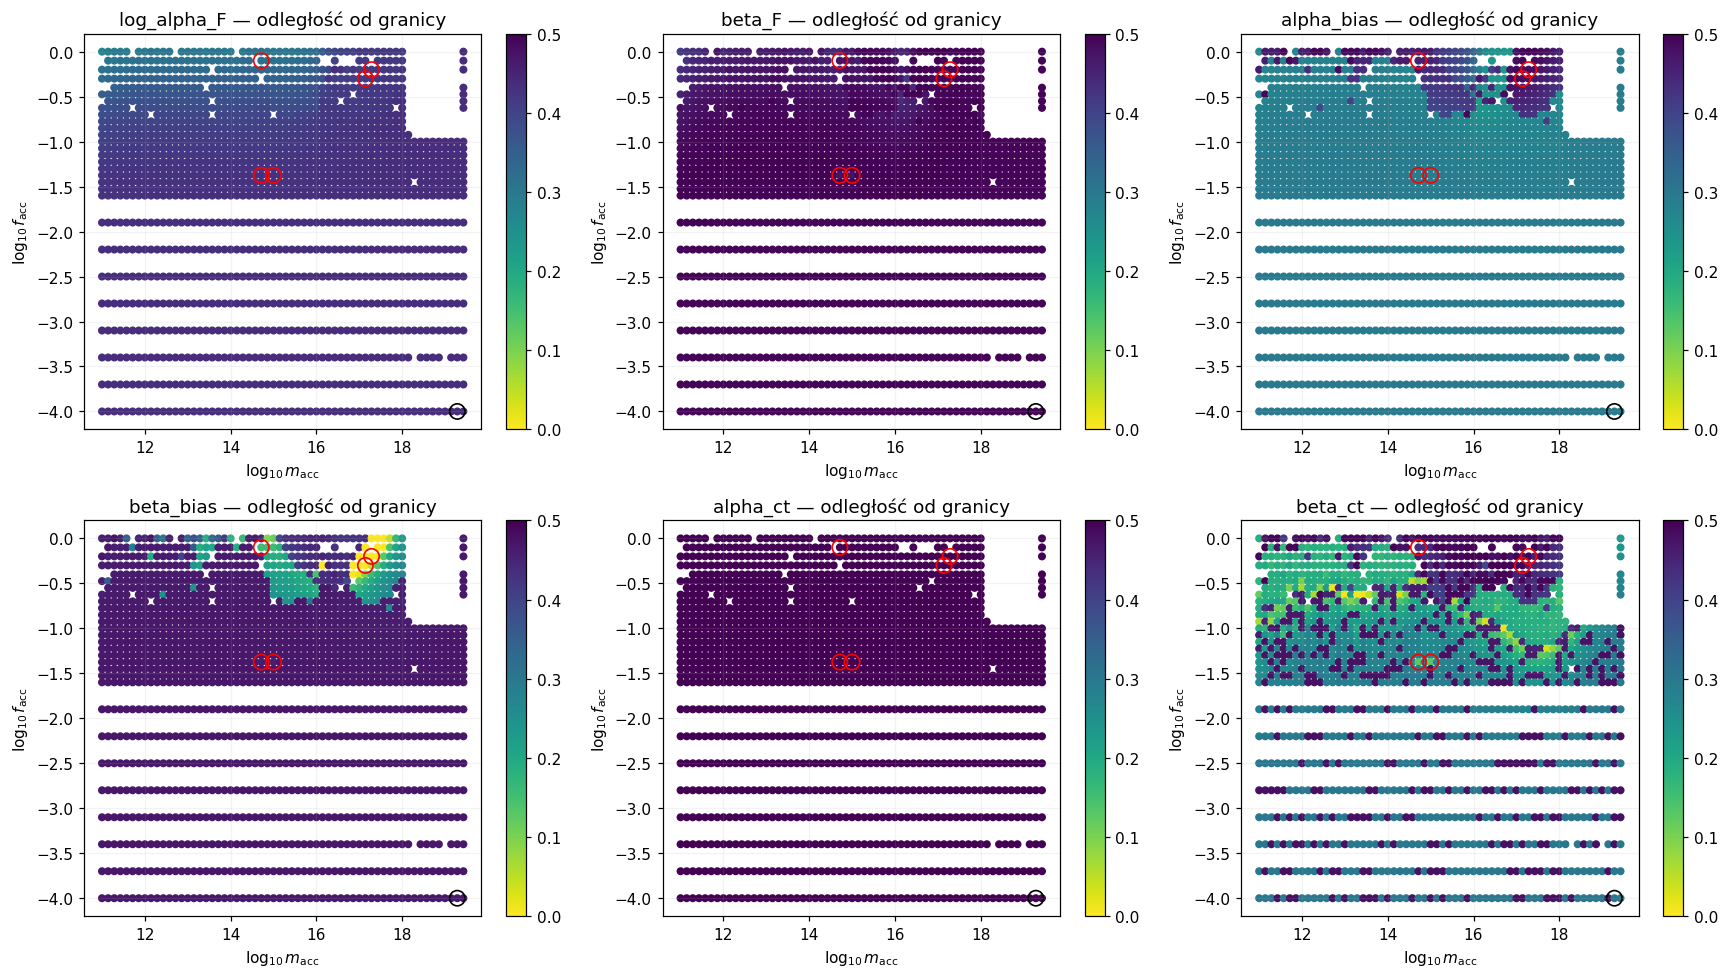

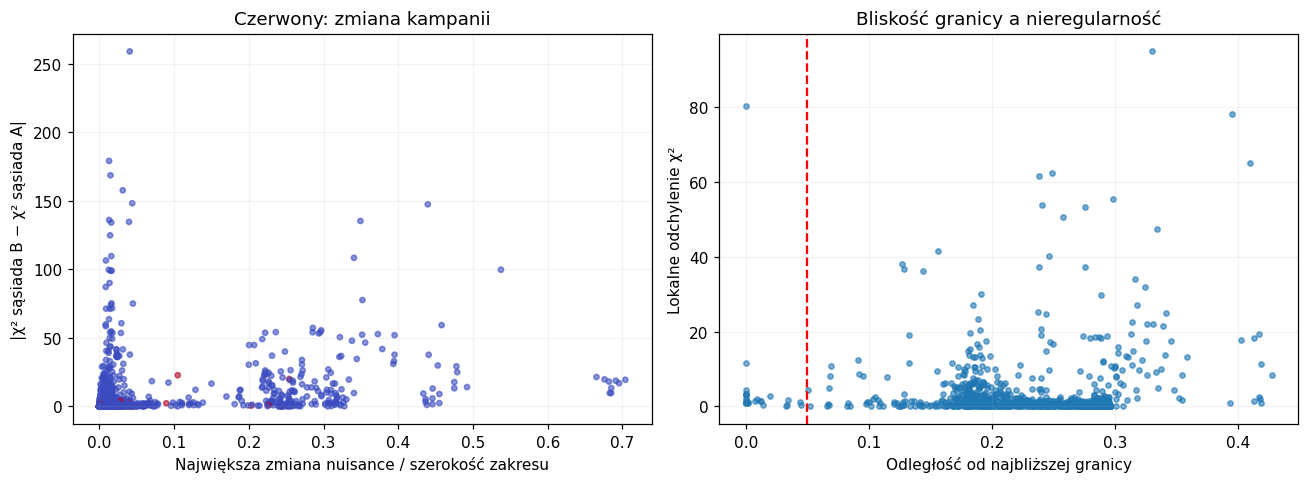

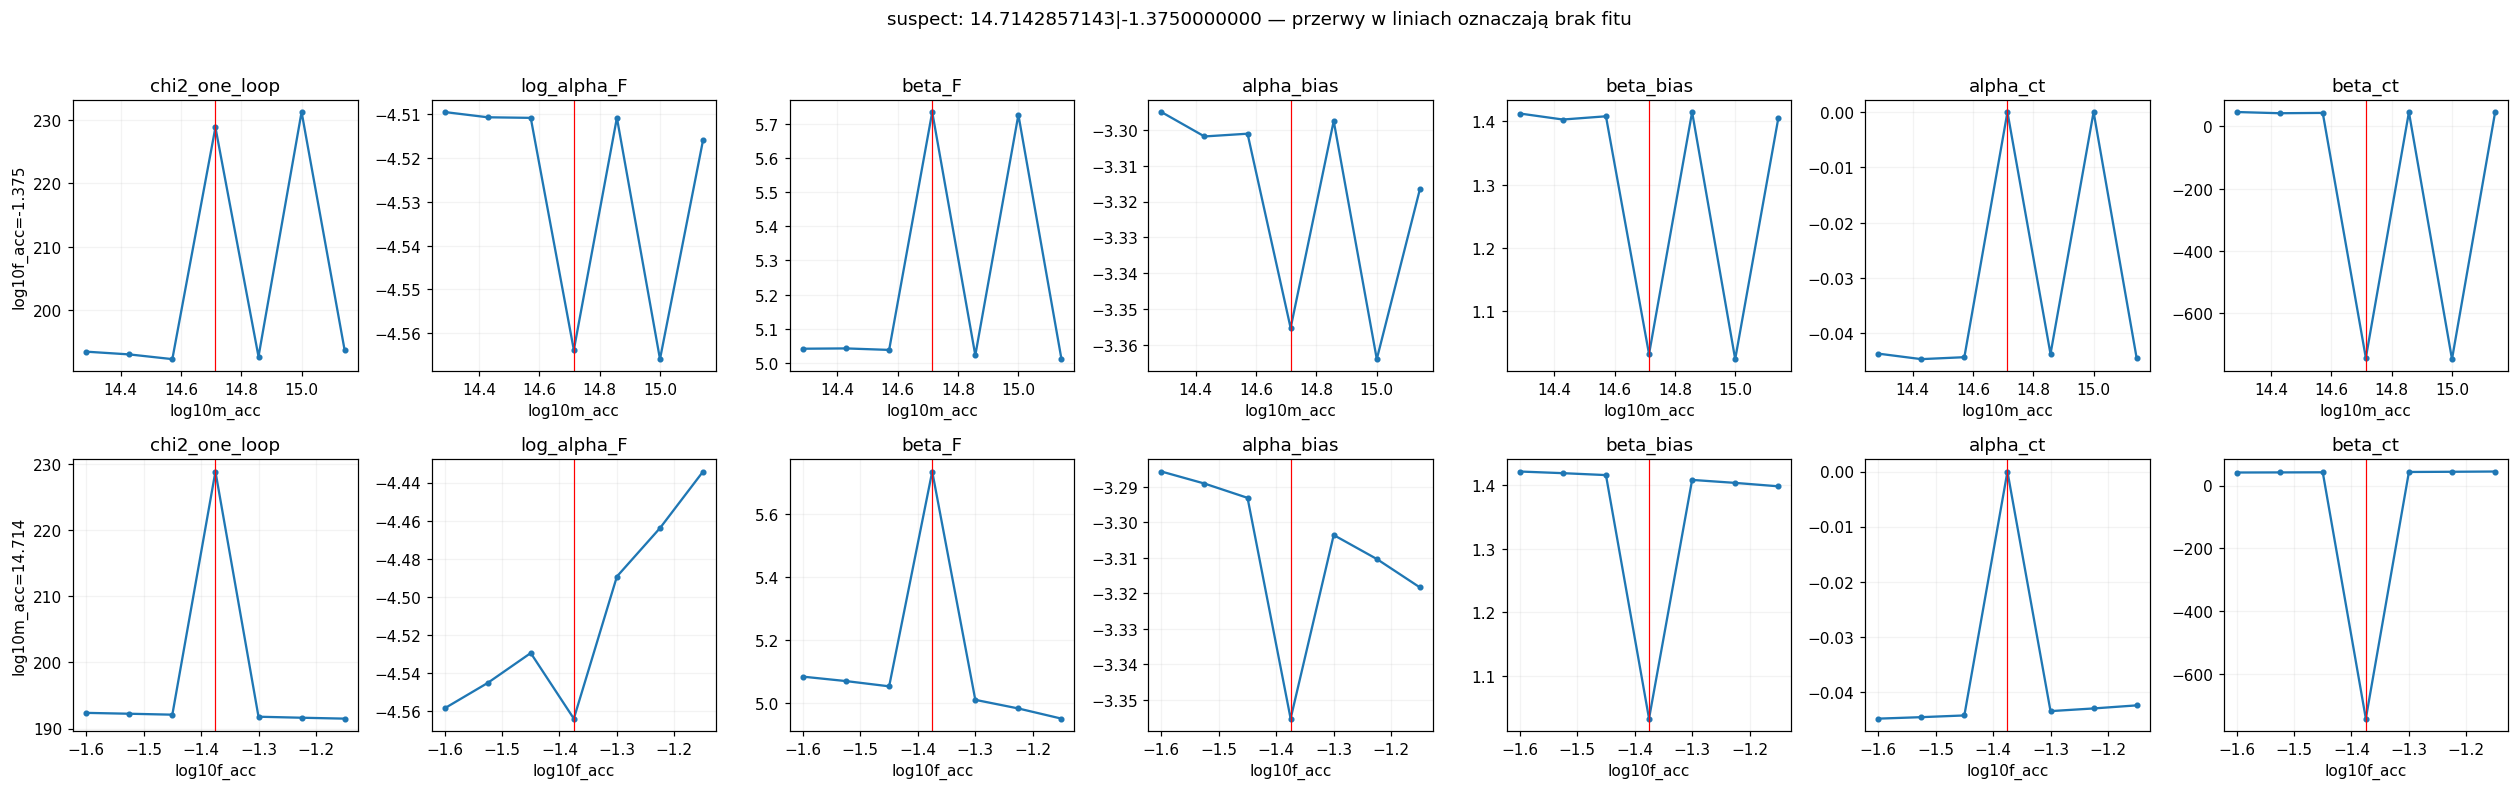

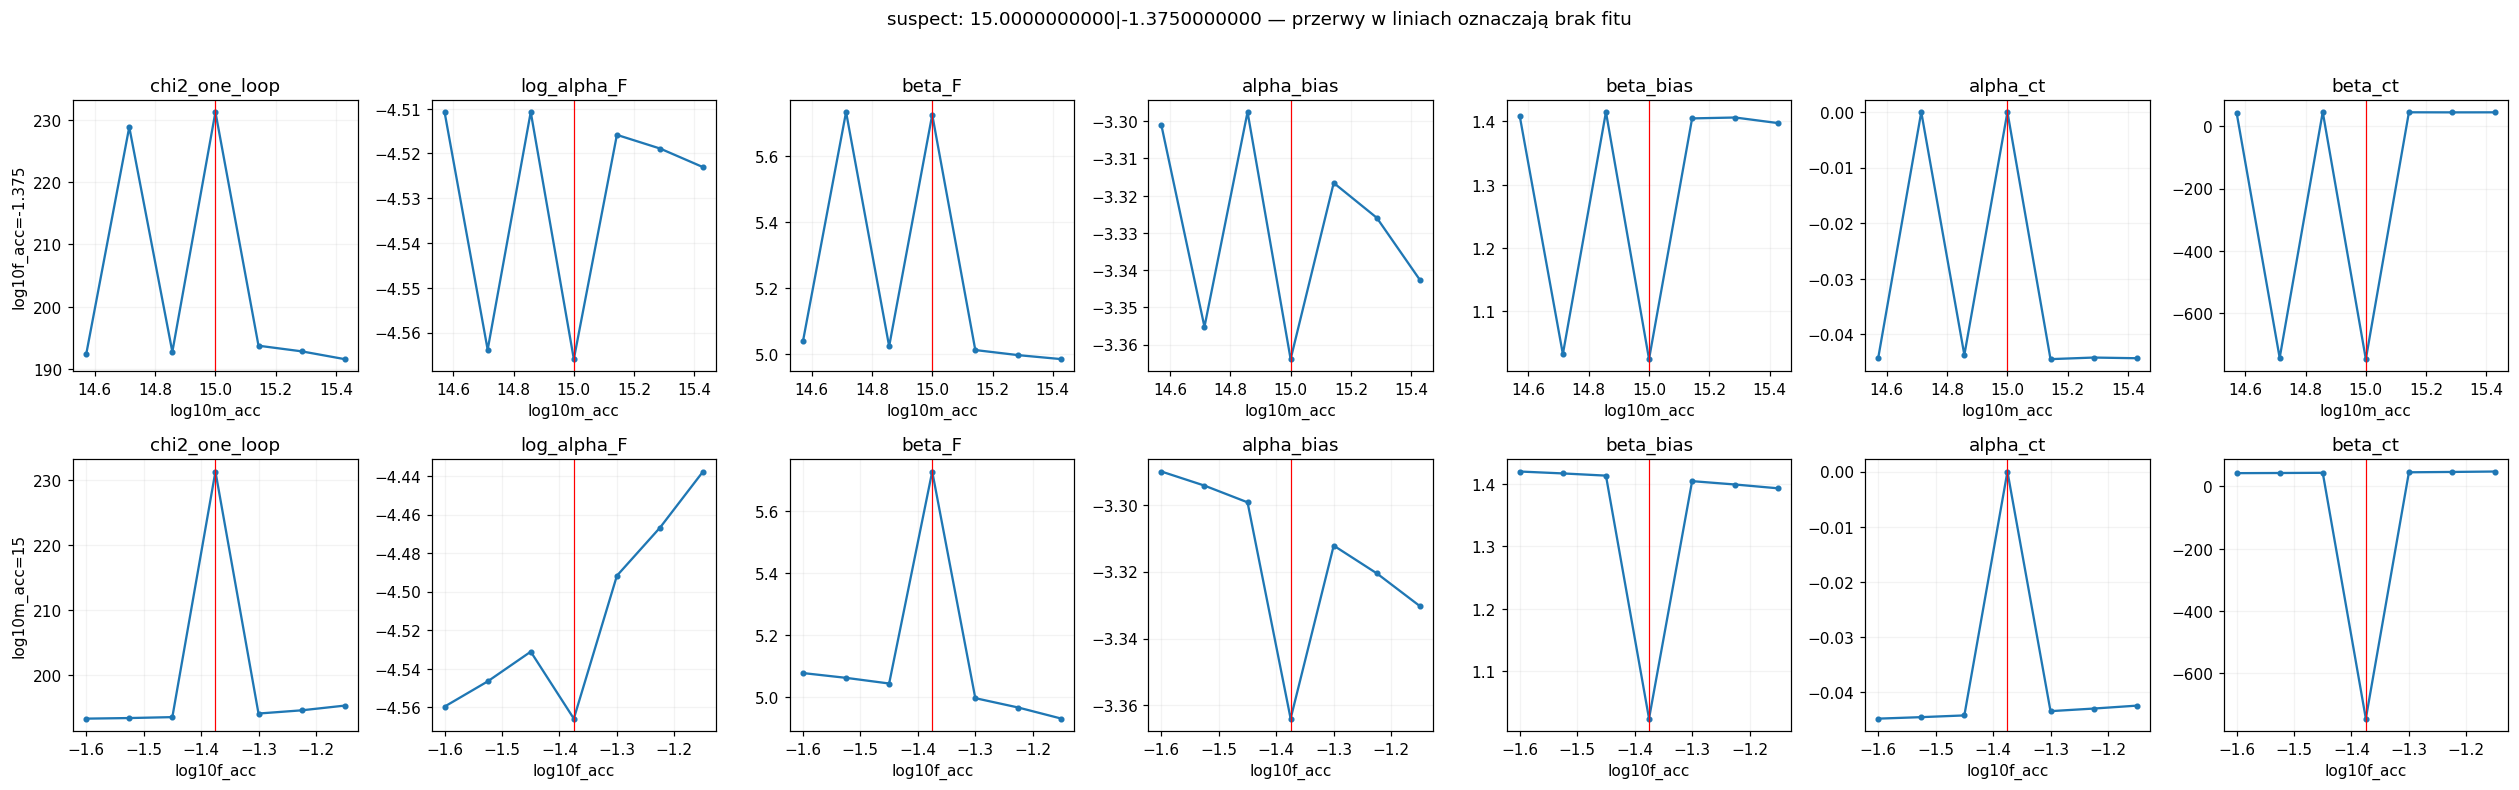

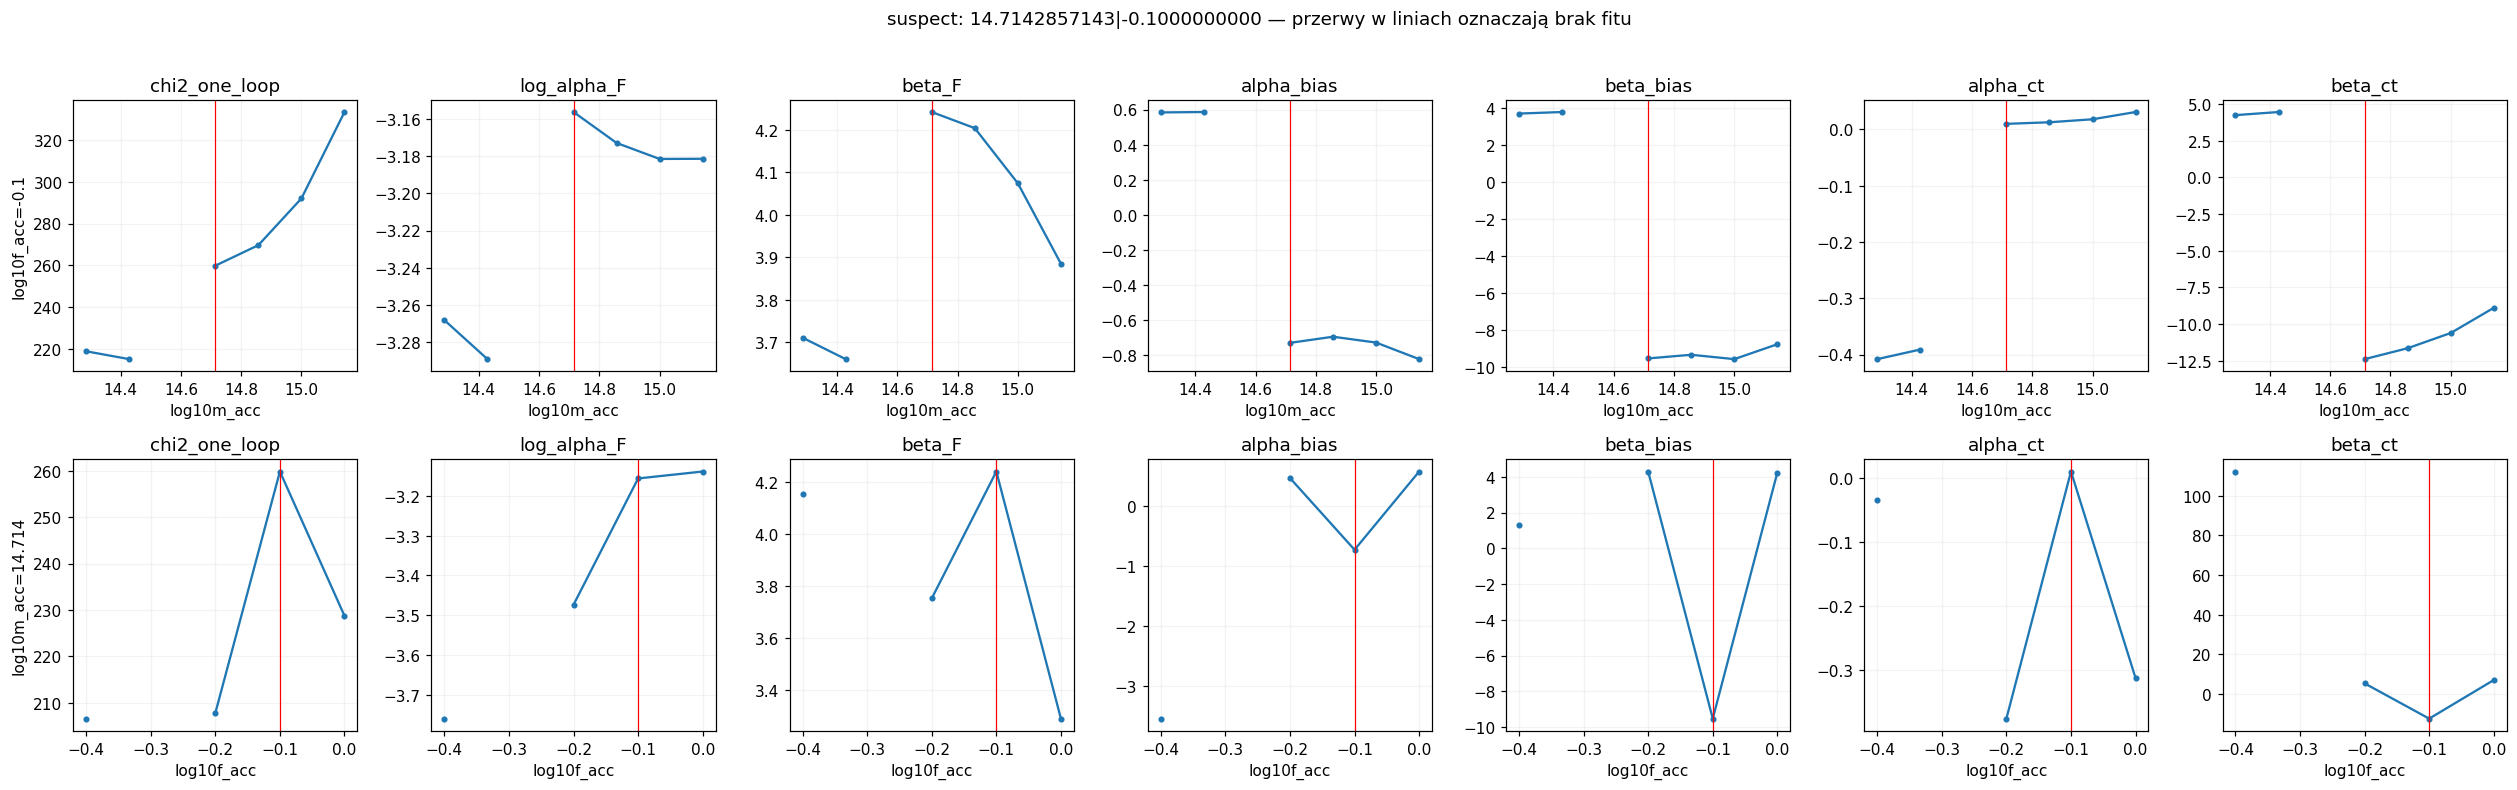

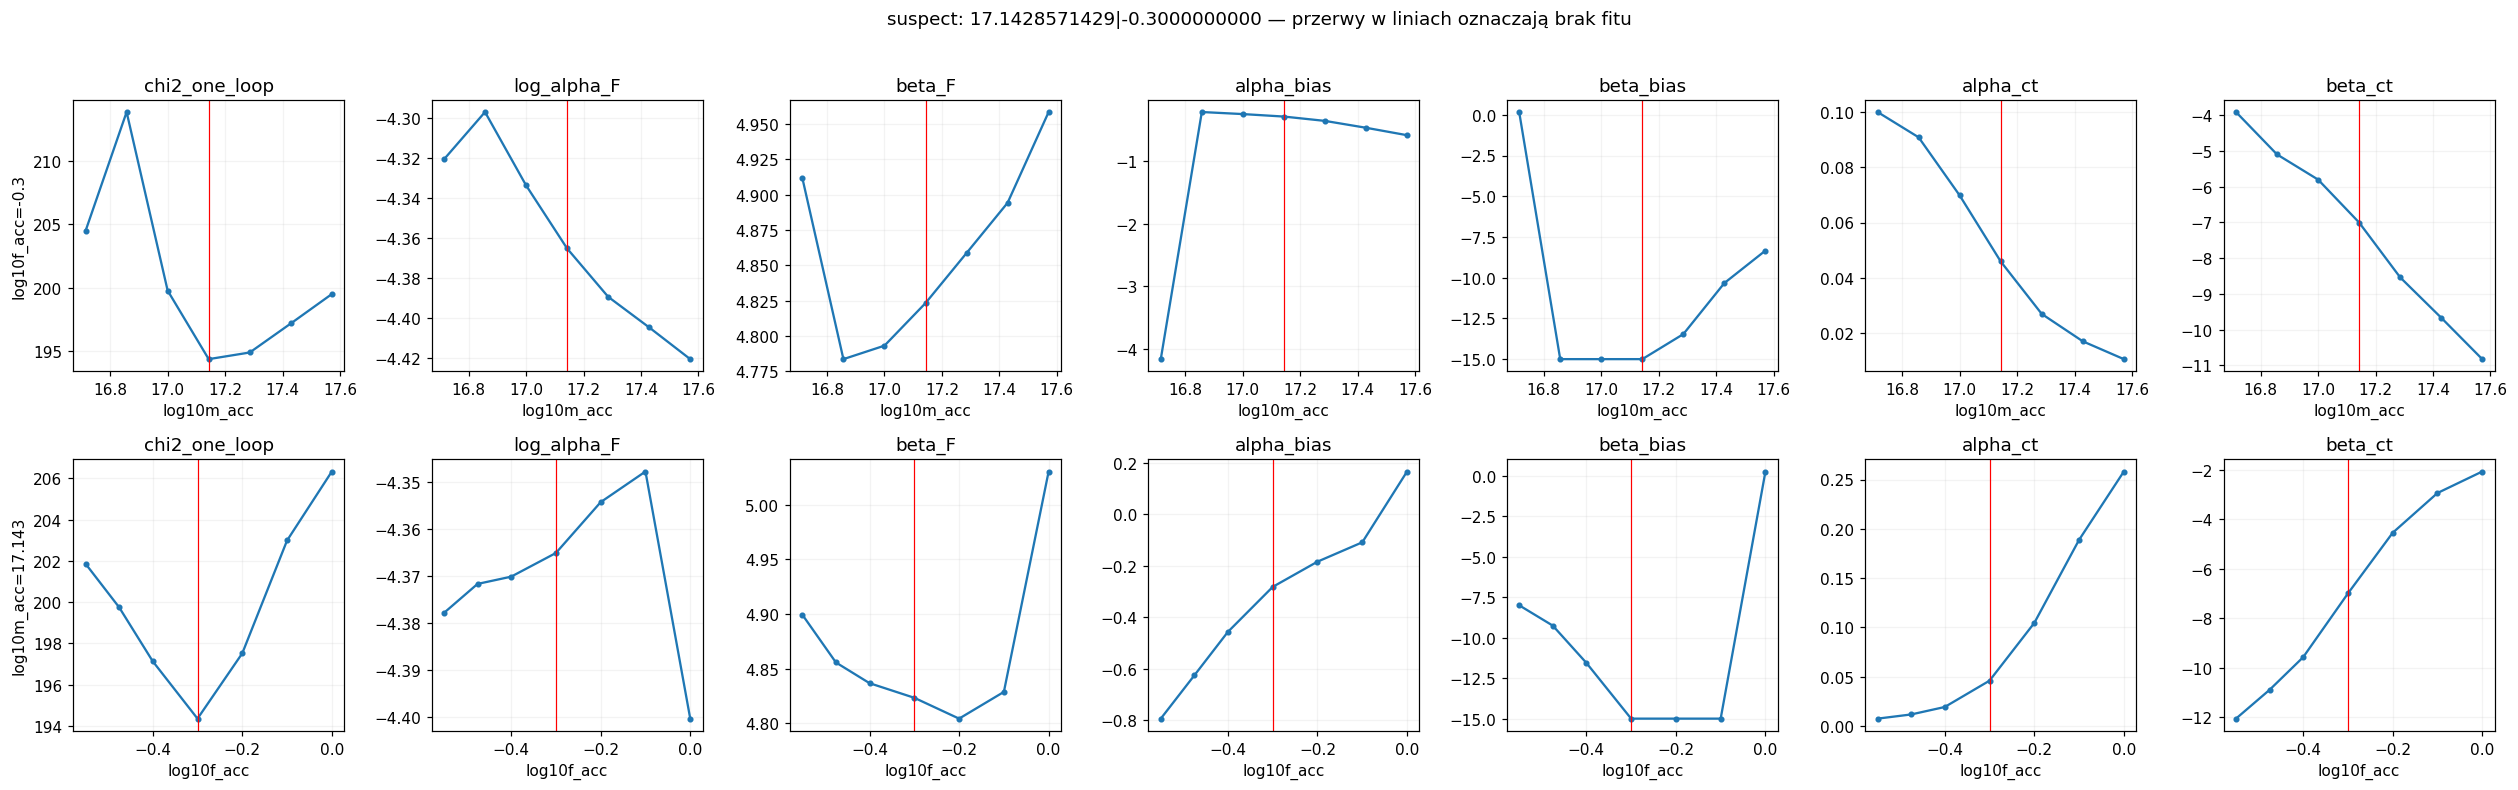

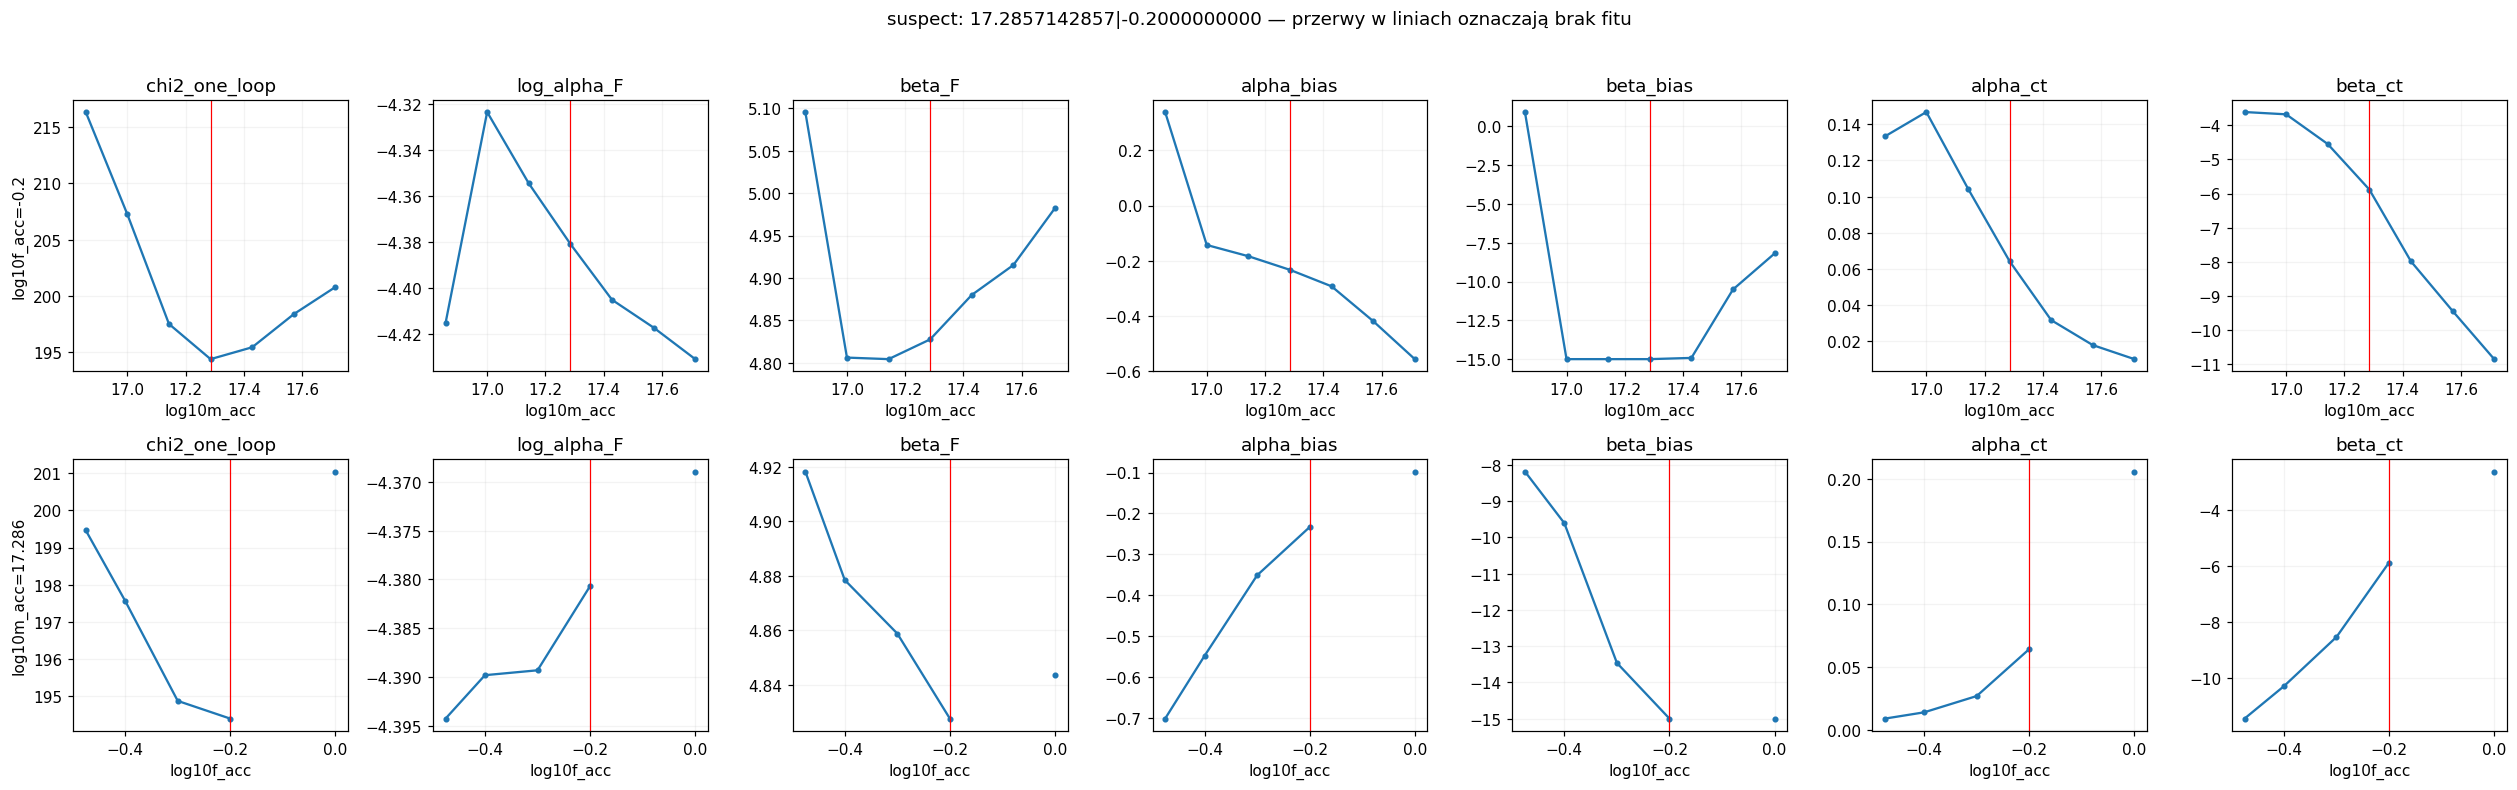

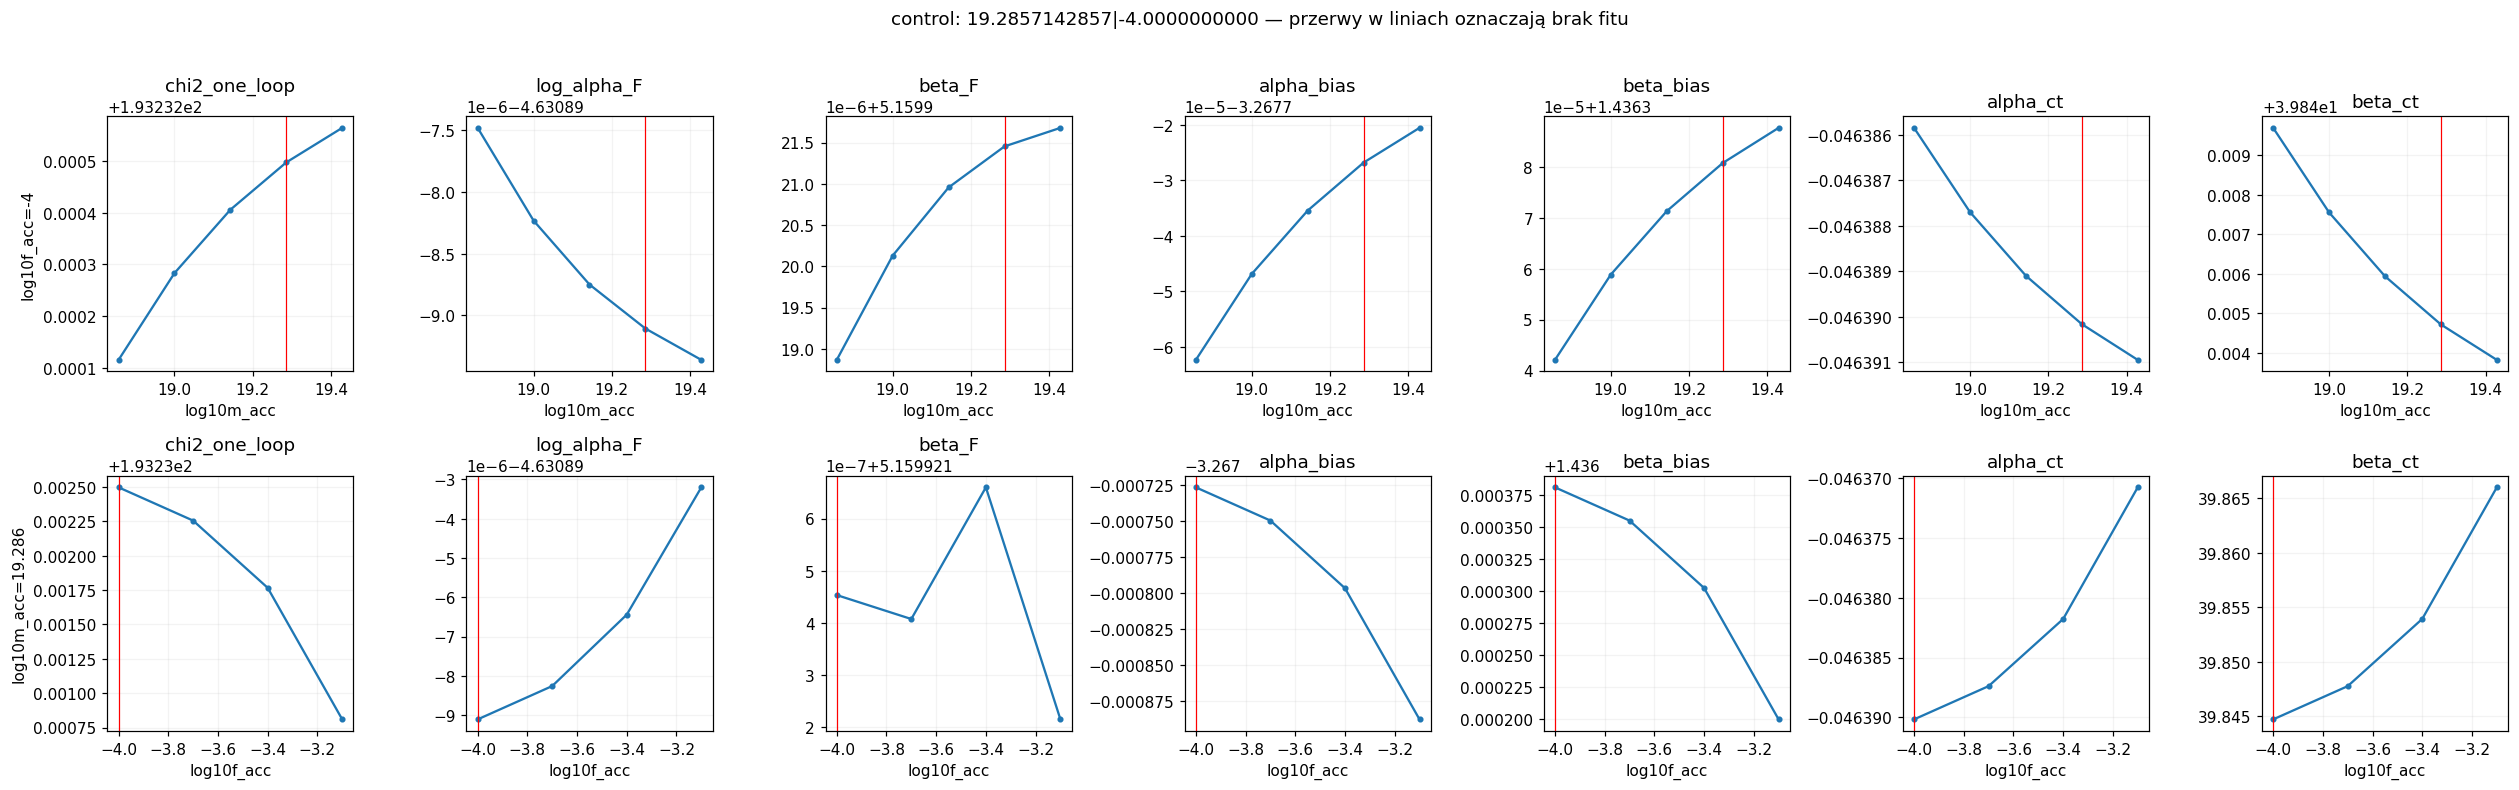

In [13]:
def map_points(ax, values, title, cmap='viridis', **kwargs):
    val=pd.to_numeric(values,errors='coerce')
    good=np.isfinite(val)
    if (~good).any():
        ax.scatter(points.loc[~good,'log10m_acc'],points.loc[~good,'log10f_acc'],s=12,color='lightgrey',marker='x')
    if good.any():
        sc=ax.scatter(points.loc[good,'log10m_acc'],points.loc[good,'log10f_acc'],c=val[good],s=18,cmap=cmap,**kwargs)
        ax.figure.colorbar(sc,ax=ax)
    ax.set(xlabel=r'$\log_{10}m_{\rm acc}$',ylabel=r'$\log_{10}f_{\rm acc}$',title=title)
    for s in stencils:
        r=points.loc[s['center']]
        ax.scatter([r.log10m_acc],[r.log10f_acc],marker='o',s=100,facecolor='none',edgecolor='red' if s['kind']=='suspect' else 'black',linewidth=1.1)

fig,axes=plt.subplots(1,3,figsize=(16,4.5))
map_points(axes[0],points.delta_chi2_sampled,'Surowe Δχ²; kolor obcięty do 25',vmin=0,vmax=25)
map_points(axes[1],points.roughness_max,'Odchylenie od liniowego trendu sąsiadów',cmap='magma')
map_points(axes[2],points.minimum_bound_distance,'Najbliższa granica nuisance',cmap='viridis_r',vmin=0,vmax=.5)
show_figure('raw_maps',fig)

fig,axes=plt.subplots(2,3,figsize=(16,9))
for ax,name in zip(axes.flat,PARAMETER_NAMES):
    map_points(ax,points['parameter_'+name],name)
show_figure('nuisance_parameter_maps',fig)

bound_rows=[]
for key,r in points.iterrows():
    for name in PARAMETER_NAMES:
        lower,upper,value=r['lower_'+name],r['upper_'+name],r['parameter_'+name]
        d=r['bound_distance_'+name]
        bound_rows.append(dict(coordinate_key=key,parameter=name,value=value,lower=lower,upper=upper,
            relative_distance=d,bounds_known=np.isfinite(lower) and np.isfinite(upper),
            outside_box=(value<lower or value>upper) if np.isfinite(d) else None,
            near_bound=(d<=BOUND_WARNING_FRACTION) if np.isfinite(d) else None))
bound_detail=pd.DataFrame(bound_rows)
save_table('nuisance_bounds_all_parameters',bound_detail)
nearest=points[['log10m_acc','log10f_acc','chi2_one_loop','minimum_bound_distance','roughness_max']].copy()
if 'minimum_bound_parameter' in points: nearest['minimum_bound_parameter']=points.minimum_bound_parameter
nearest['bound_status']=np.where(nearest.minimum_bound_distance.isna(),'unknown',np.where(nearest.minimum_bound_distance<=BOUND_WARNING_FRACTION,'near','above_threshold_known'))
save_table('nearest_bound_audit',nearest.reset_index(drop=True))
optimizer_columns=[c for c in ['coordinate_key','log10m_acc','log10f_acc','chi2_one_loop','optimizer_success','optimizer_message','multistart_count','multistart_best','multistart_span','multistart_second_gap','search_candidates_json','fit_stages_json'] if c in points]
optimizer_audit=points[optimizer_columns].copy()
save_table('optimizer_audit',optimizer_audit)
if 'multistart_span' in optimizer_audit:
    print('Rozrzut zapisanych startów (może obejmować etapy kontynuacji):')
    display(optimizer_audit.sort_values('multistart_span',ascending=False).head(10))
print('Status najbliższej granicy (unknown oznacza brak informacji):')
display(nearest.bound_status.value_counts().rename('points').to_frame())
display(nearest.sort_values('minimum_bound_distance').head(15))
if bound_detail.bounds_known.any():
    fig,axes=plt.subplots(2,3,figsize=(16,9))
    for ax,name in zip(axes.flat,PARAMETER_NAMES):
        map_points(ax,points['bound_distance_'+name],name+' — odległość od granicy',cmap='viridis_r',vmin=0,vmax=.5)
    show_figure('individual_bound_maps',fig)
else:
    print('CSV zawiera szerokości zakresów i najbliższą granicę, ale nie pełne dolne/górne bounds. Nie odtwarzam ich przez zgadywanie.')

# Nuisance a nieregularność χ²: korelacja jest wskazówką, nie rozstrzygnięciem.
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].scatter(pairs.max_abs_box_shift,pairs.abs_delta_chi2,c=pairs.source_changed.astype(int),cmap='coolwarm',s=12,alpha=.6)
axes[0].set(xlabel='Największa zmiana nuisance / szerokość zakresu',ylabel='|χ² sąsiada B − χ² sąsiada A|',title='Czerwony: zmiana kampanii')
axes[1].scatter(points.minimum_bound_distance,points.roughness_max,s=12,alpha=.6)
axes[1].axvline(BOUND_WARNING_FRACTION,color='red',ls='--')
axes[1].set(xlabel='Odległość od najbliższej granicy',ylabel='Lokalne odchylenie χ²',title='Bliskość granicy a nieregularność')
show_figure('roughness_vs_nuisance',fig)

# Krótkie przekroje przez każdy wybrany środek: wartości surowe i każdy nuisance.
for si,s in enumerate(stencils):
    center=points.loc[s['center']]
    fig,axes=plt.subplots(2,7,figsize=(23,7))
    for row,(axis,fixed) in enumerate([('log10m_acc','log10f_acc'),('log10f_acc','log10m_acc')]):
        group=expected.loc[np.isclose(expected[fixed],center[fixed],rtol=0,atol=1e-9)].sort_values(axis)
        at=np.flatnonzero(group.coordinate_key.to_numpy()==s['center'])[0]
        group=group.iloc[max(0,at-3):at+4]
        local=group.set_index('coordinate_key').join(points.drop(columns=['coordinate_key','log10m_acc','log10f_acc']),how='left')
        for ax,col in zip(axes[row],['chi2_one_loop']+['parameter_'+n for n in PARAMETER_NAMES]):
            ax.plot(local[axis],local[col],'o-',ms=3)
            ax.axvline(center[axis],color='red',lw=.8)
            ax.set(xlabel=axis,title=col.replace('parameter_',''))
        axes[row,0].set_ylabel(f'{fixed}={center[fixed]:.5g}')
    fig.suptitle(f"{s['kind']}: {s['center']} — przerwy w liniach oznaczają brak fitu",y=1.02)
    show_figure(f'stencil_{si:02d}_chi2_and_nuisance',fig)


## 5. Widma przed dopasowaniem

Porównujemy `p_tree` i trzy `channels_one_loop`, a jeśli istnieją również P22 i P13.
Używamy kanonicznego `lyalpha_pt.theory.load_theory`, zamiast zgadywać klucze NPZ.
Porównanie obejmuje wszystkie wspólne redshifty w tabeli i trzy reprezentatywne redshifty na wykresach.
Widma są interpolowane liniowo w \(\log k\) na sumie obu siatek, wyłącznie w ich wspólnym zakresie.
Interpolacja jest tutaj potrzebna do porównania **widm**, nie do naprawy mapy χ².

Różnicę normalizujemy do \(|P_{\rm tree}|\) pierwszego punktu, co unika dzielenia przez zero składnika pętlowego.
RMS jest nieważoną średnią po wspólnej siatce k i nie jest miarą odległości likelihood.
Zestawiamy osobno `k_le_2`, cały wspólny zakres bundle oraz zakres projekcji, gdy zapisany cutoff jest znany.
Brak zmian przy k≤2 nie potwierdza stabilności P1D całkowanego do większego k.


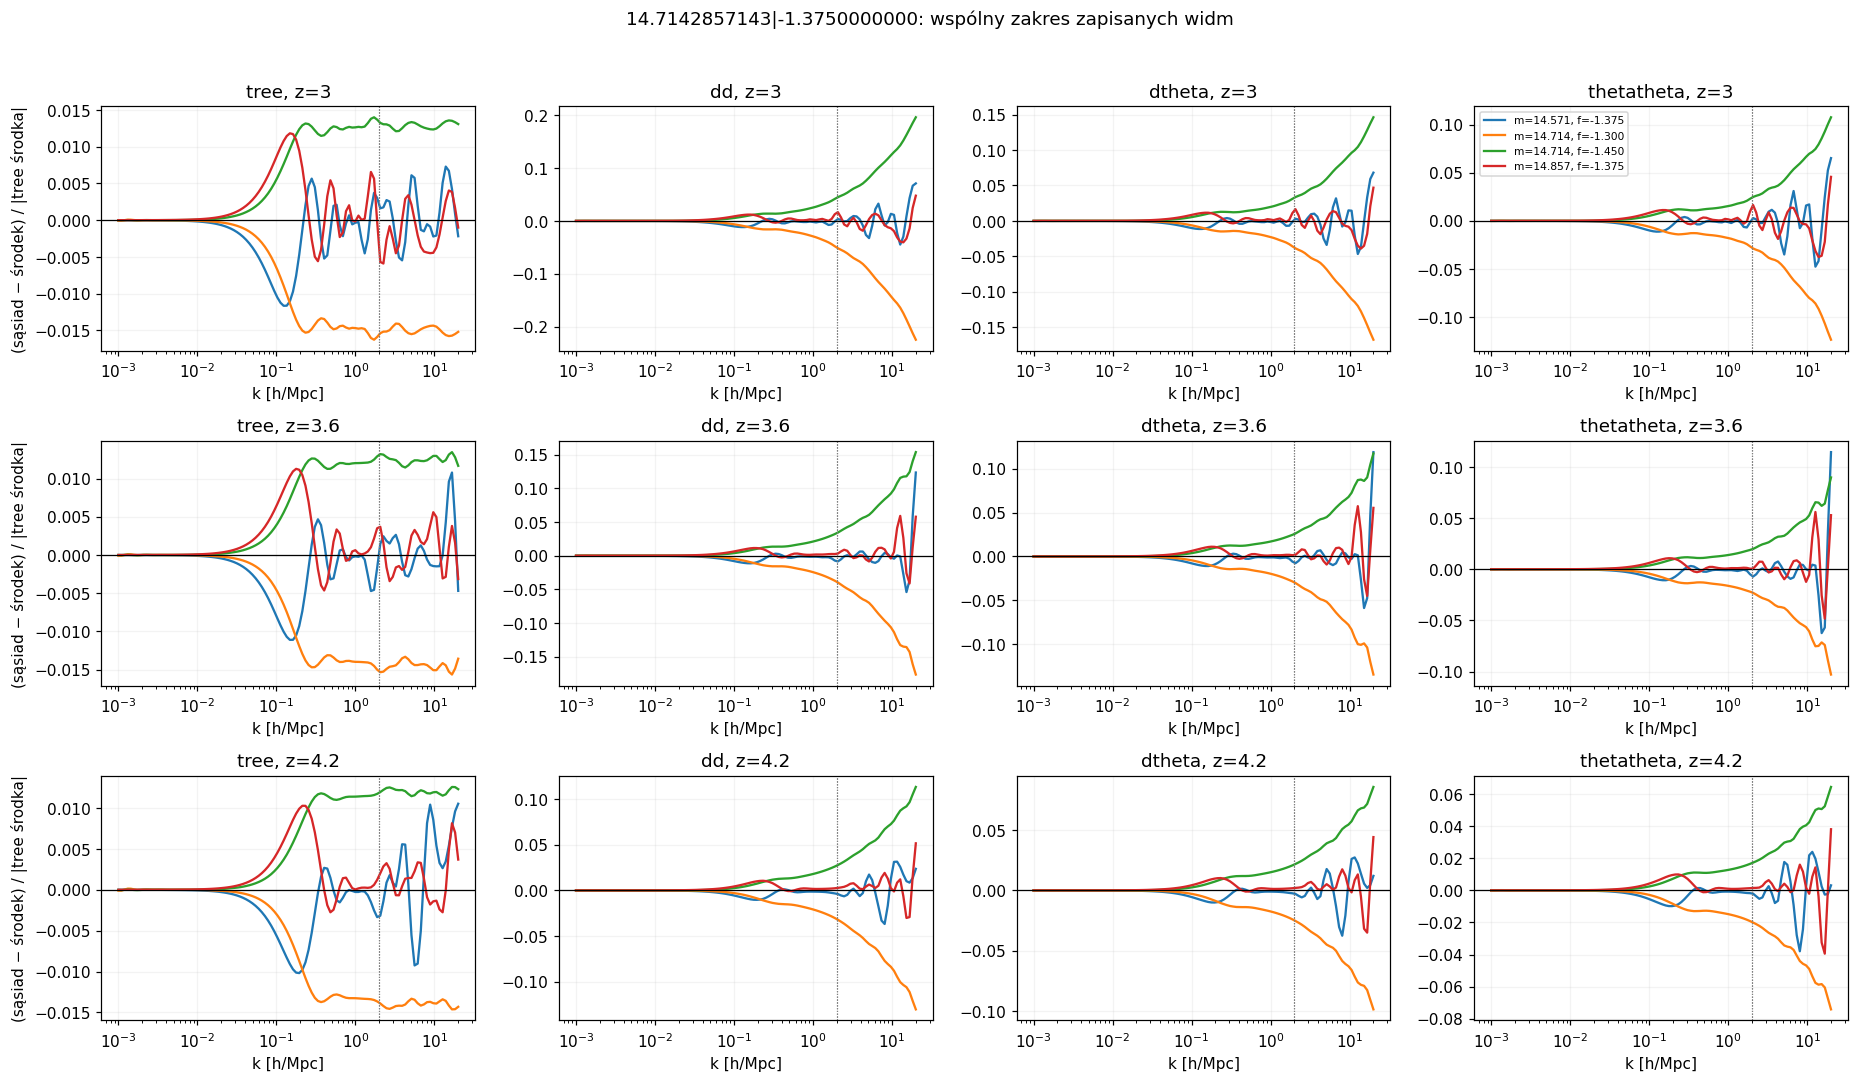

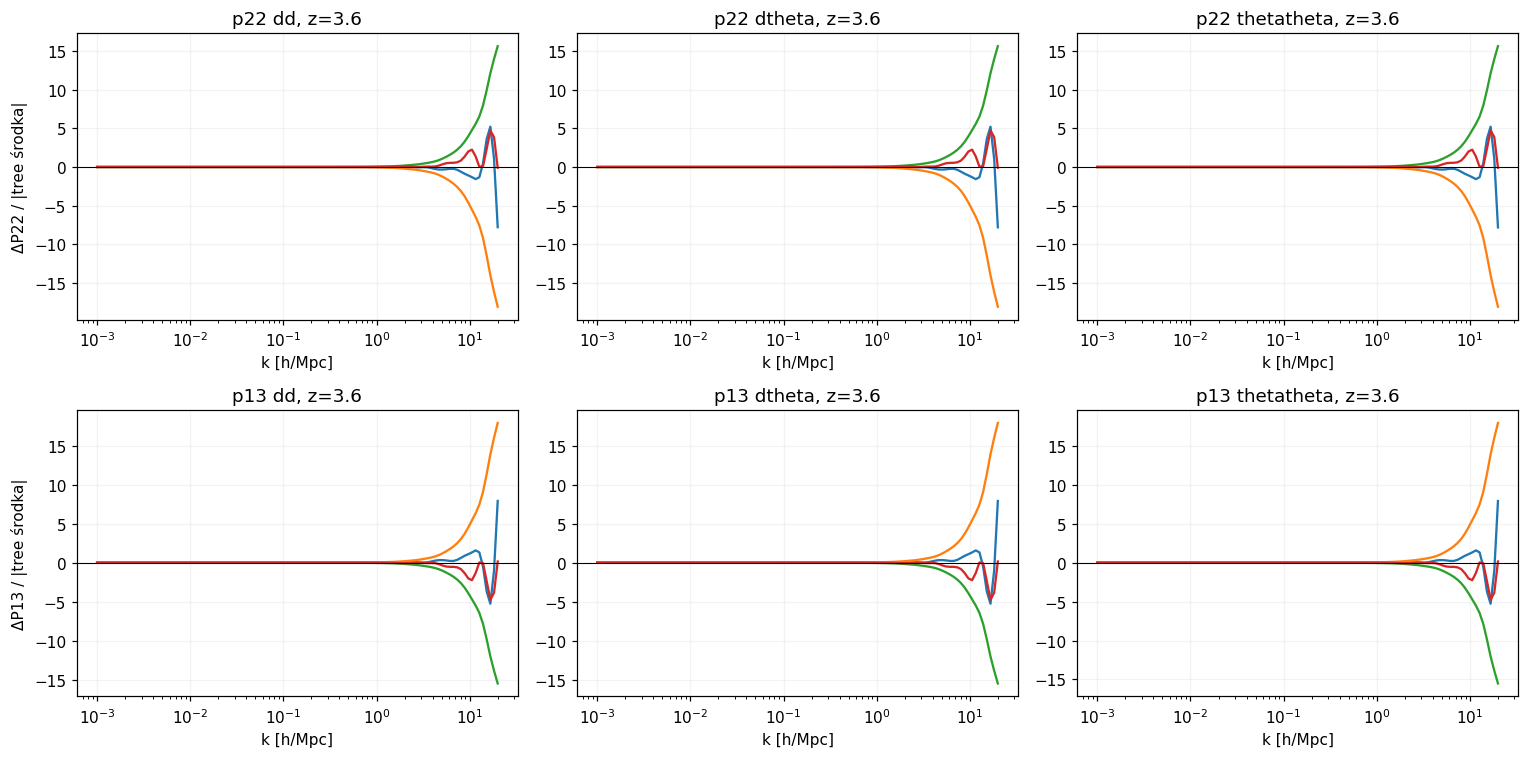

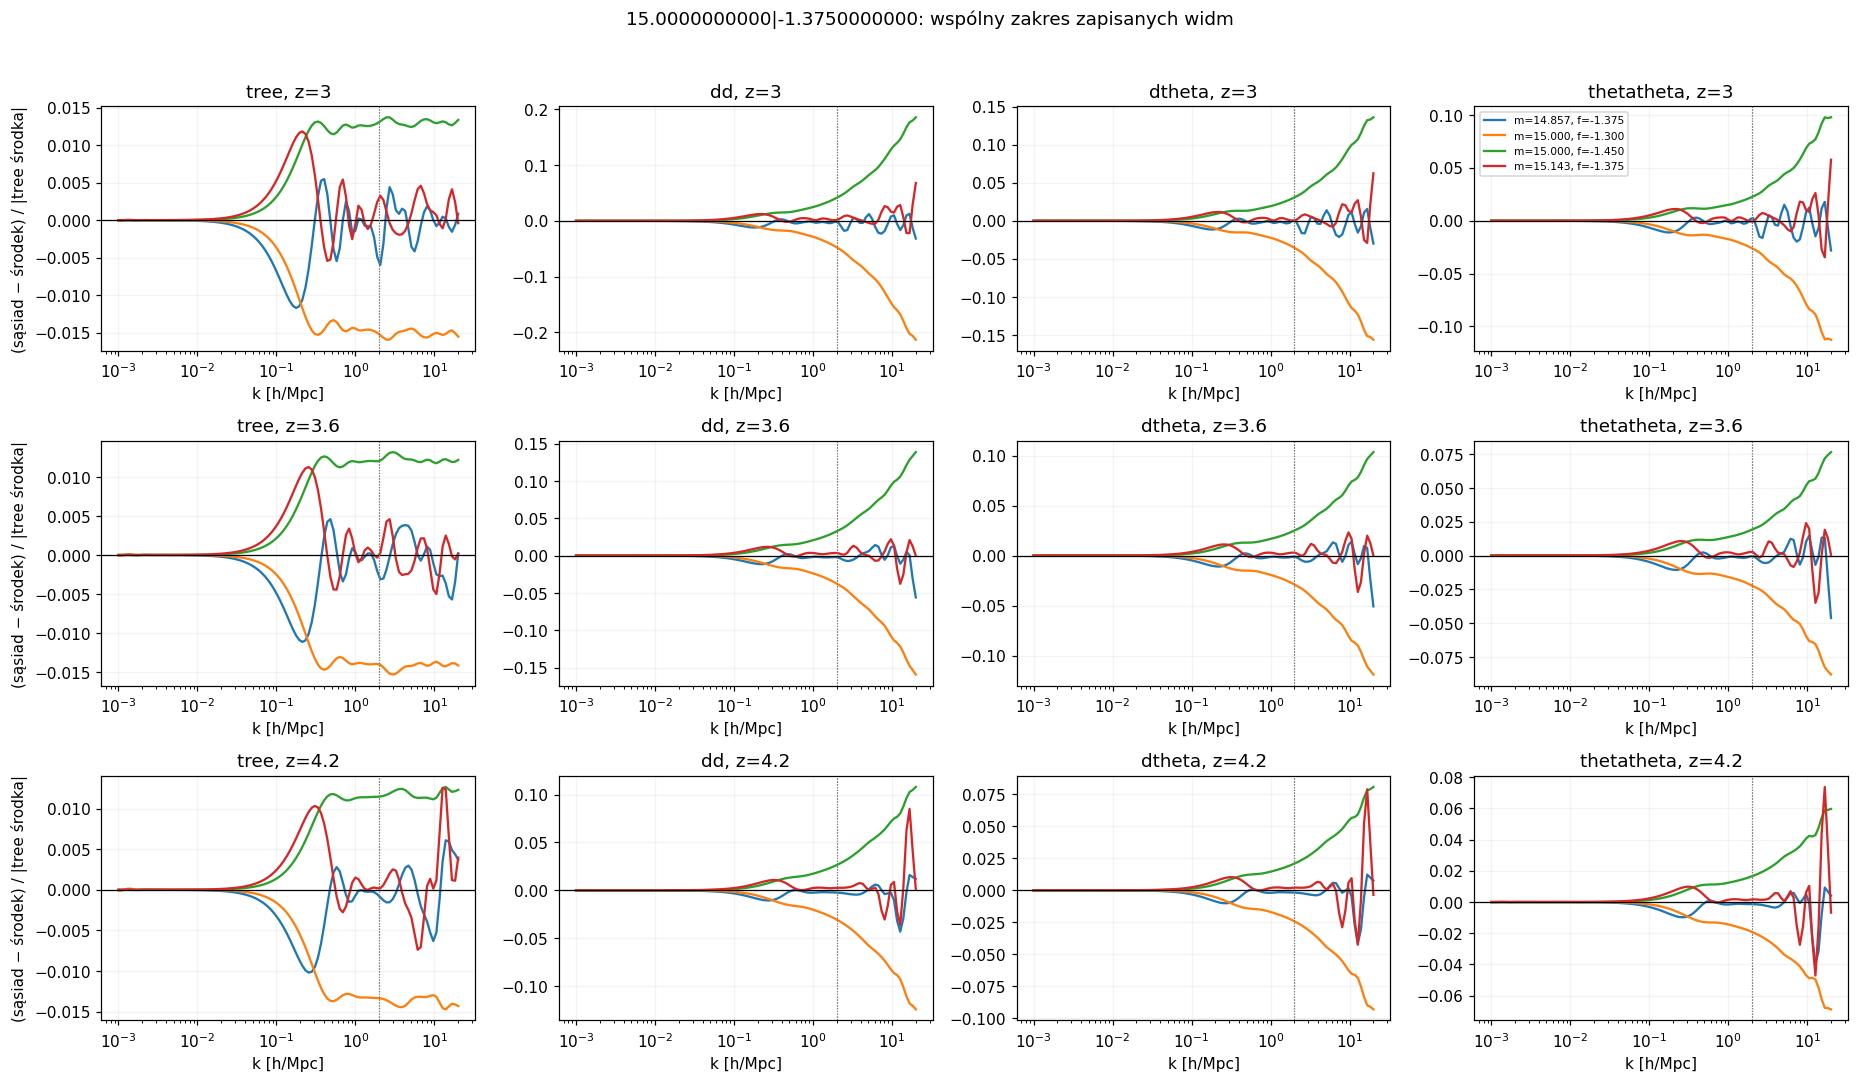

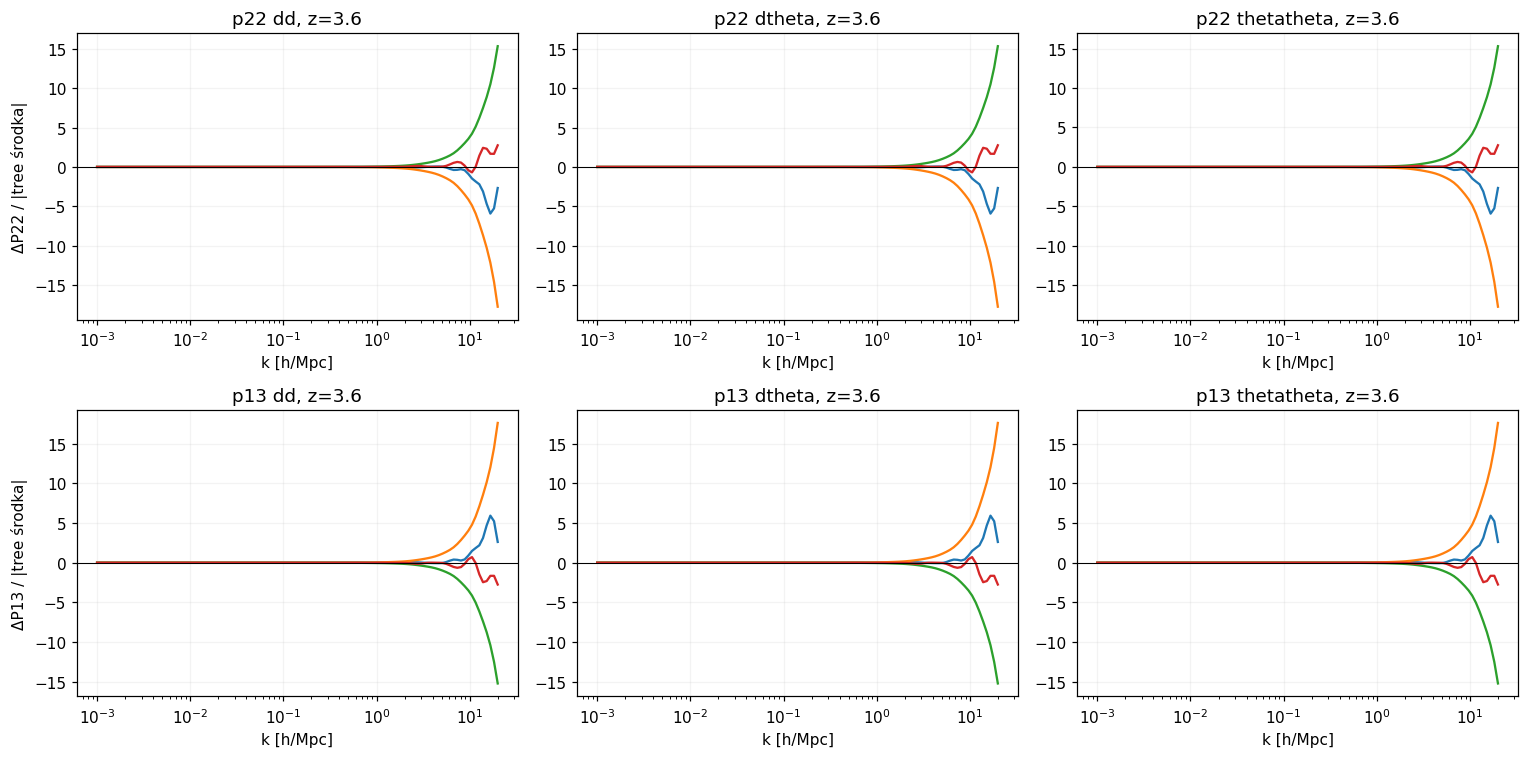

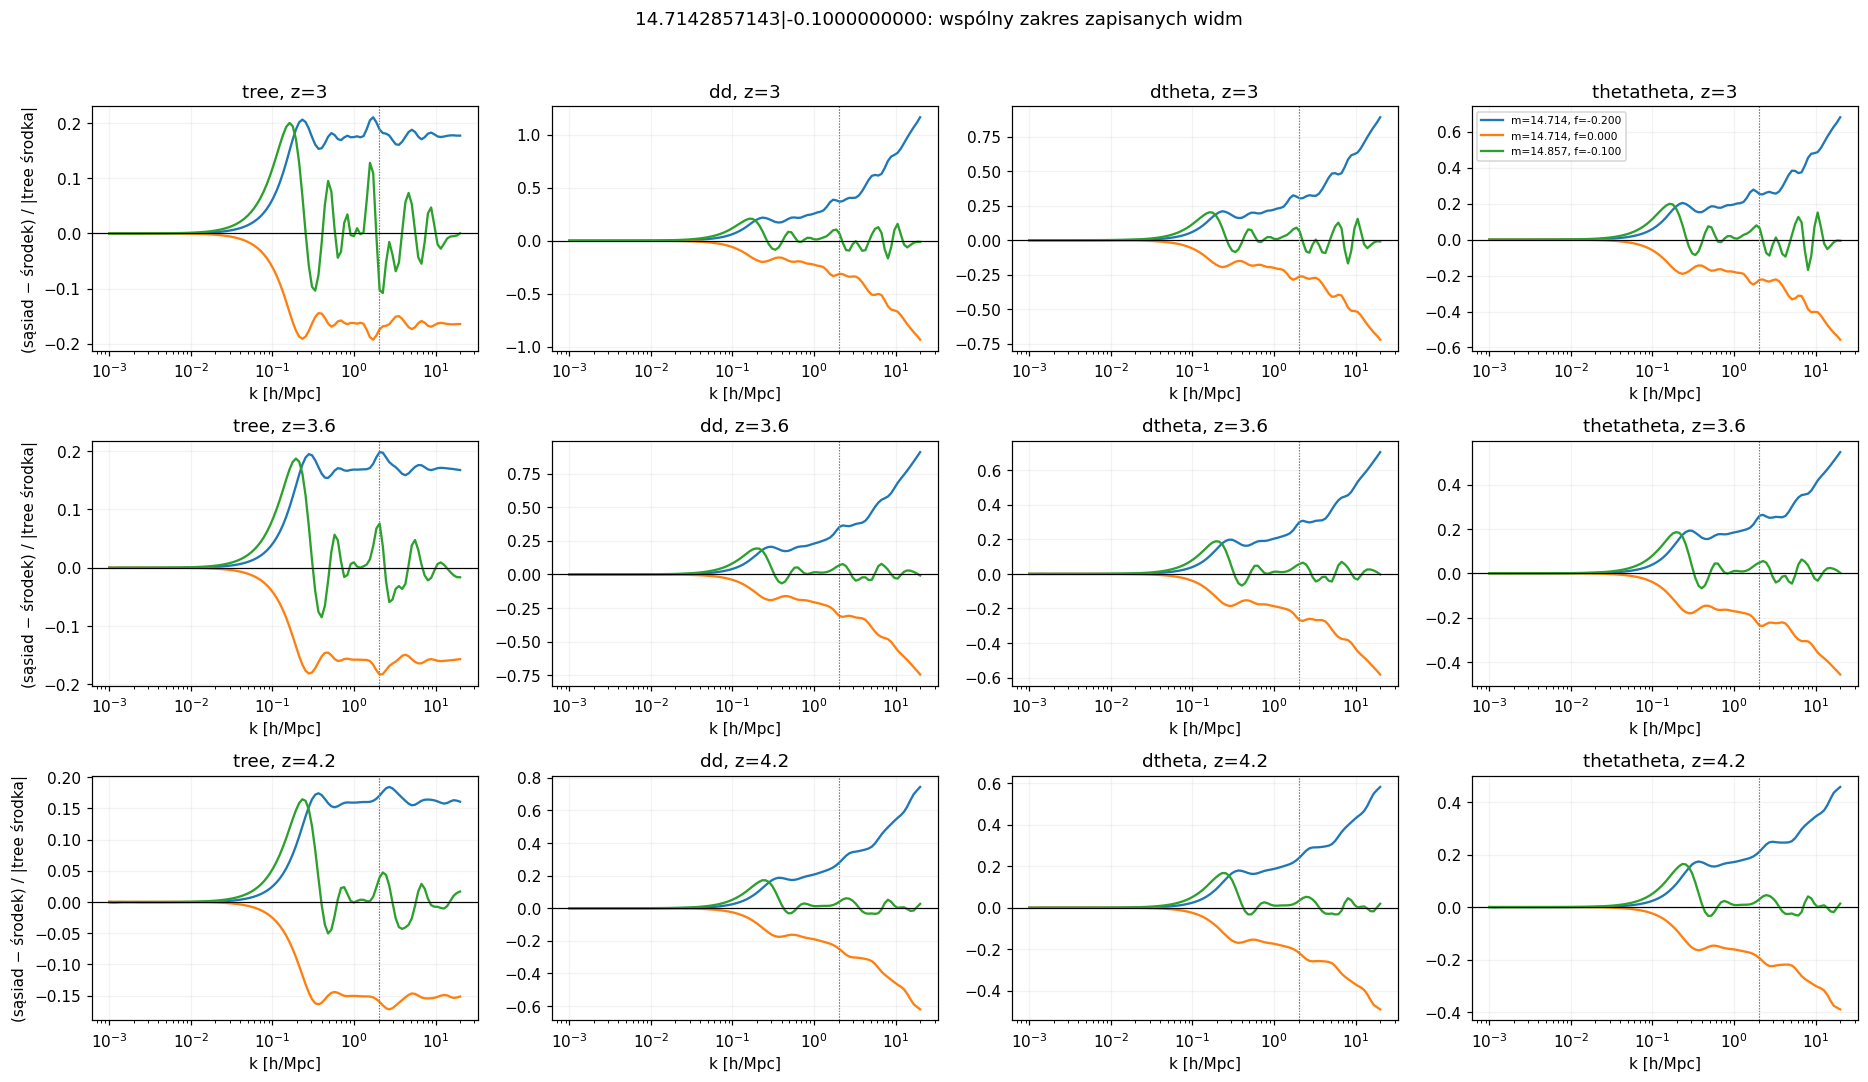

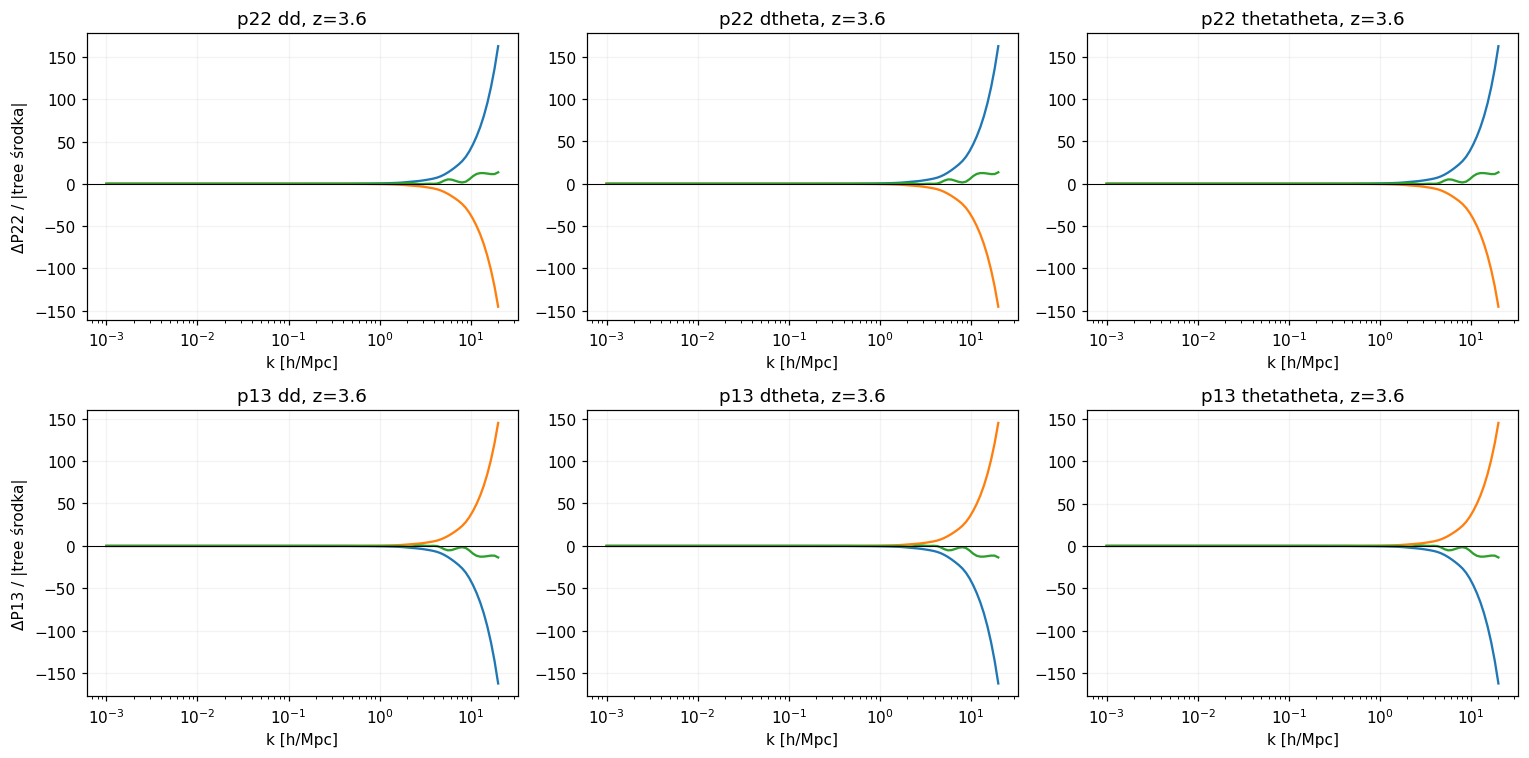

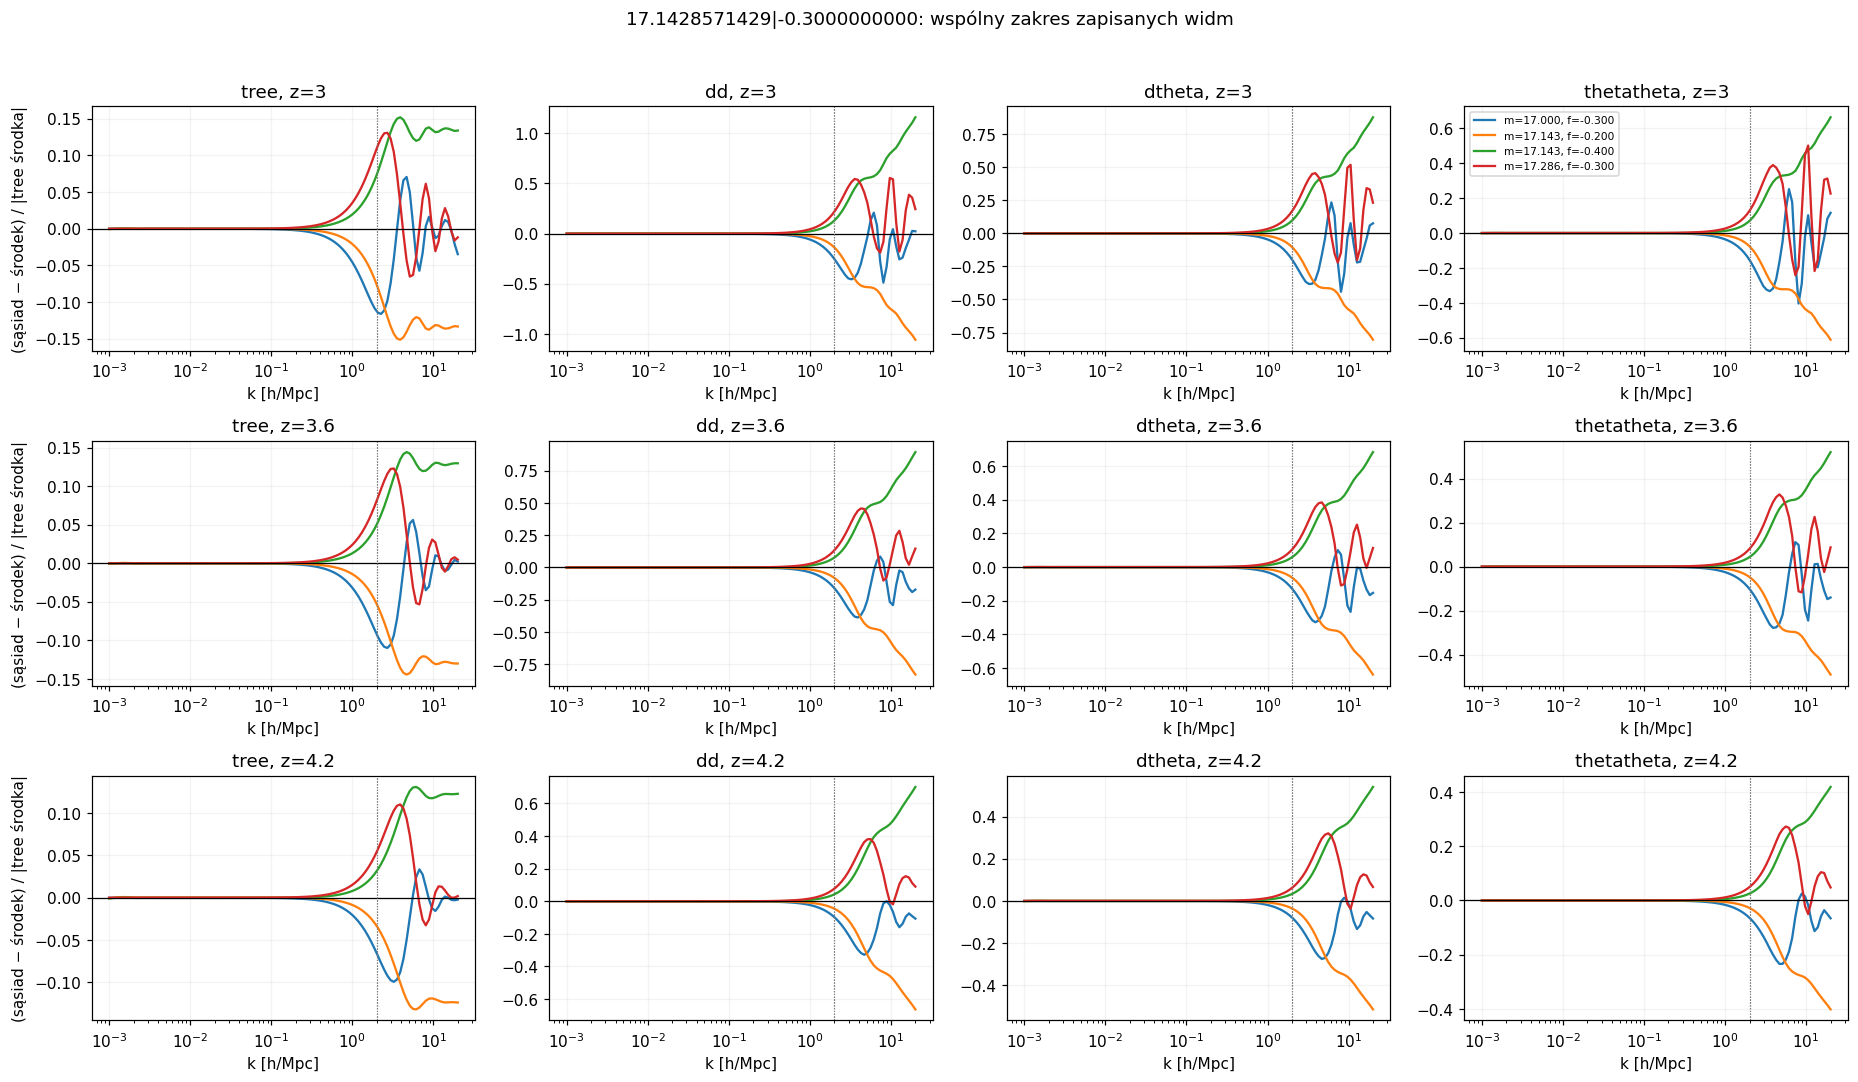

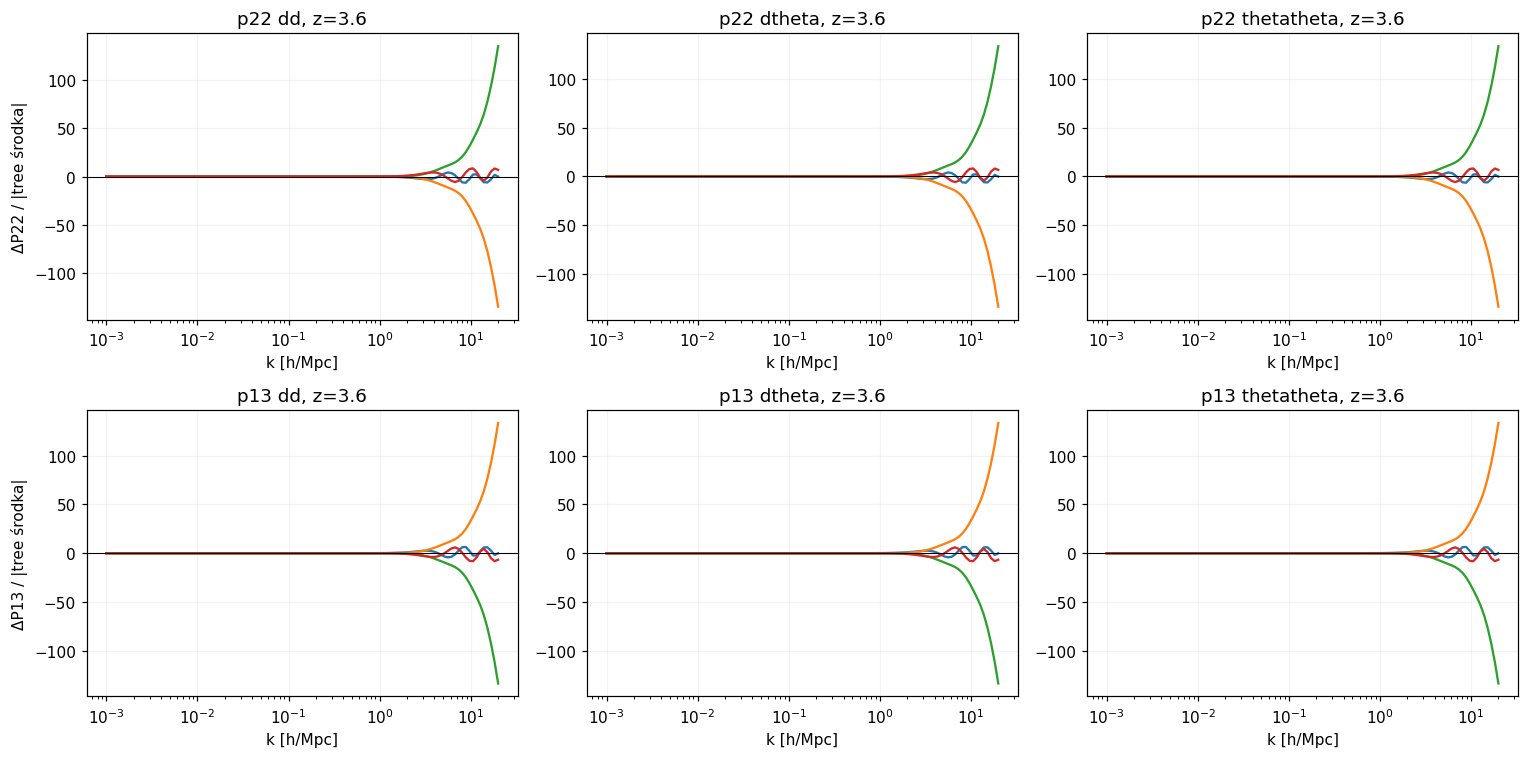

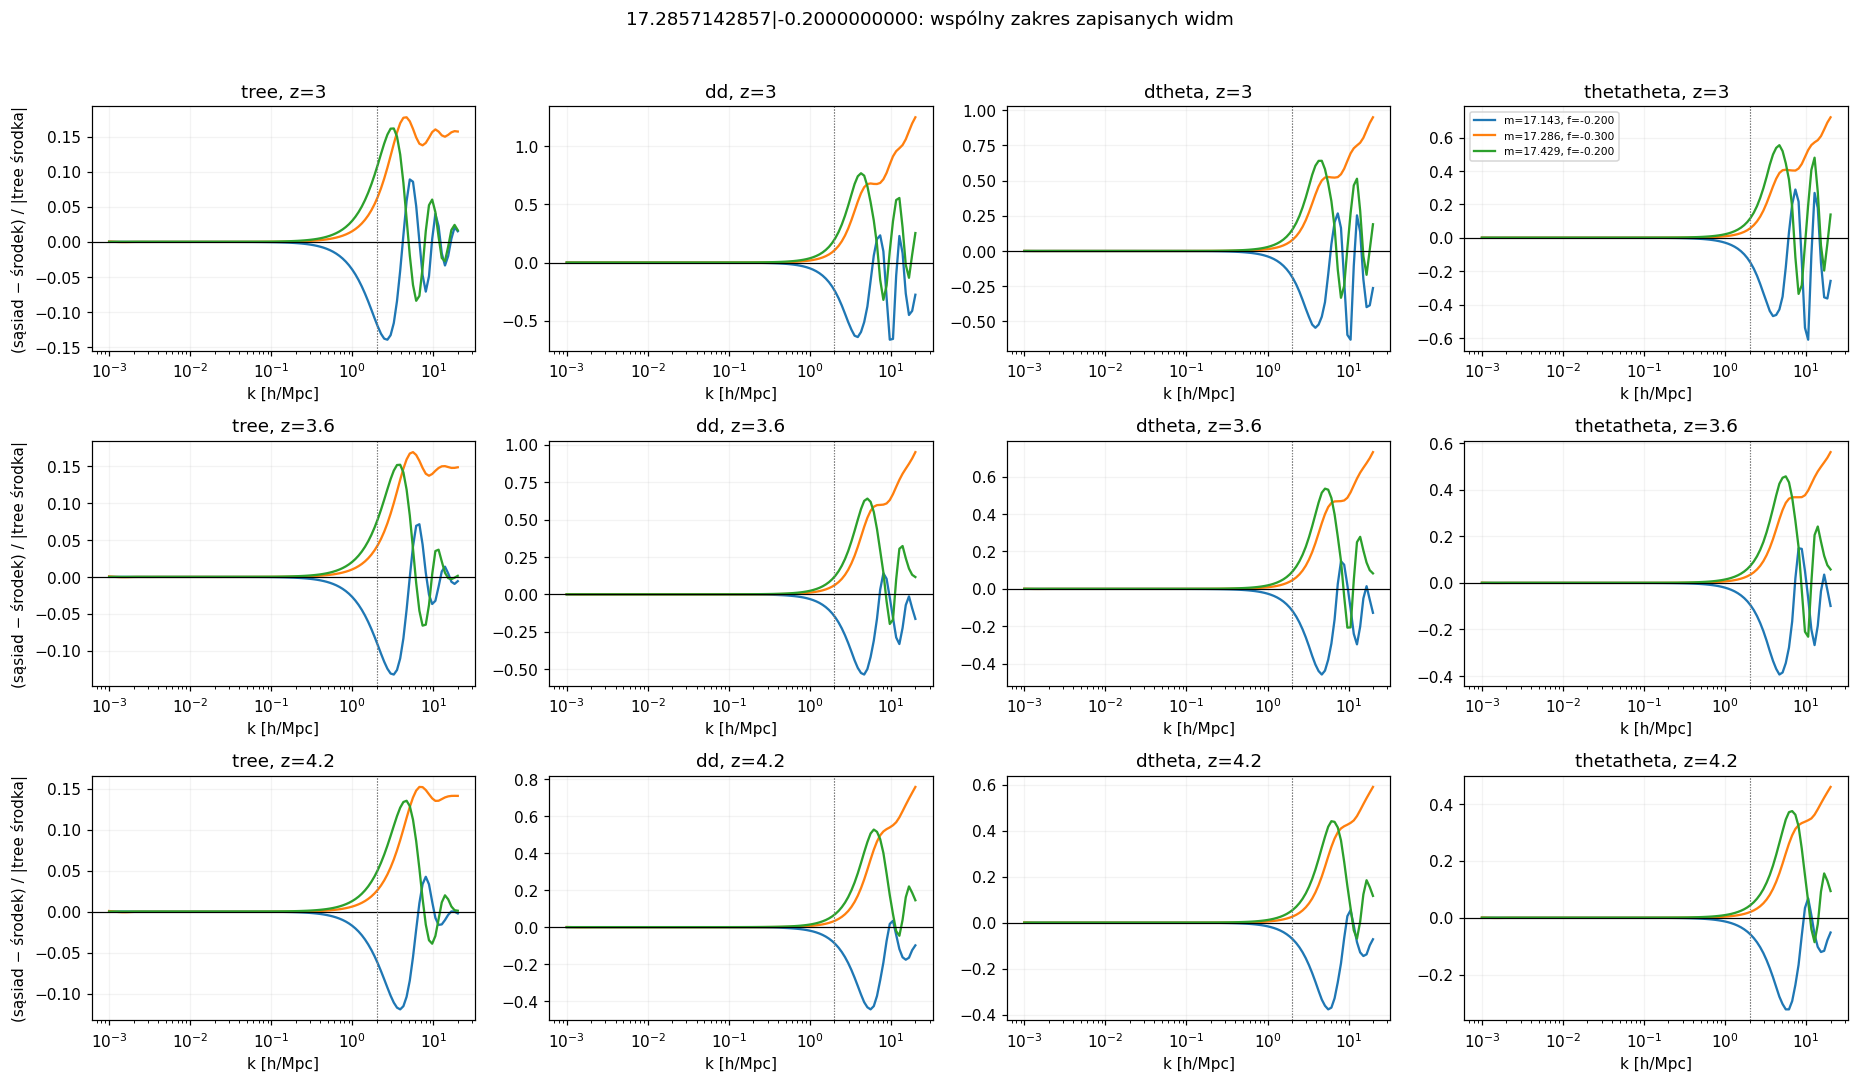

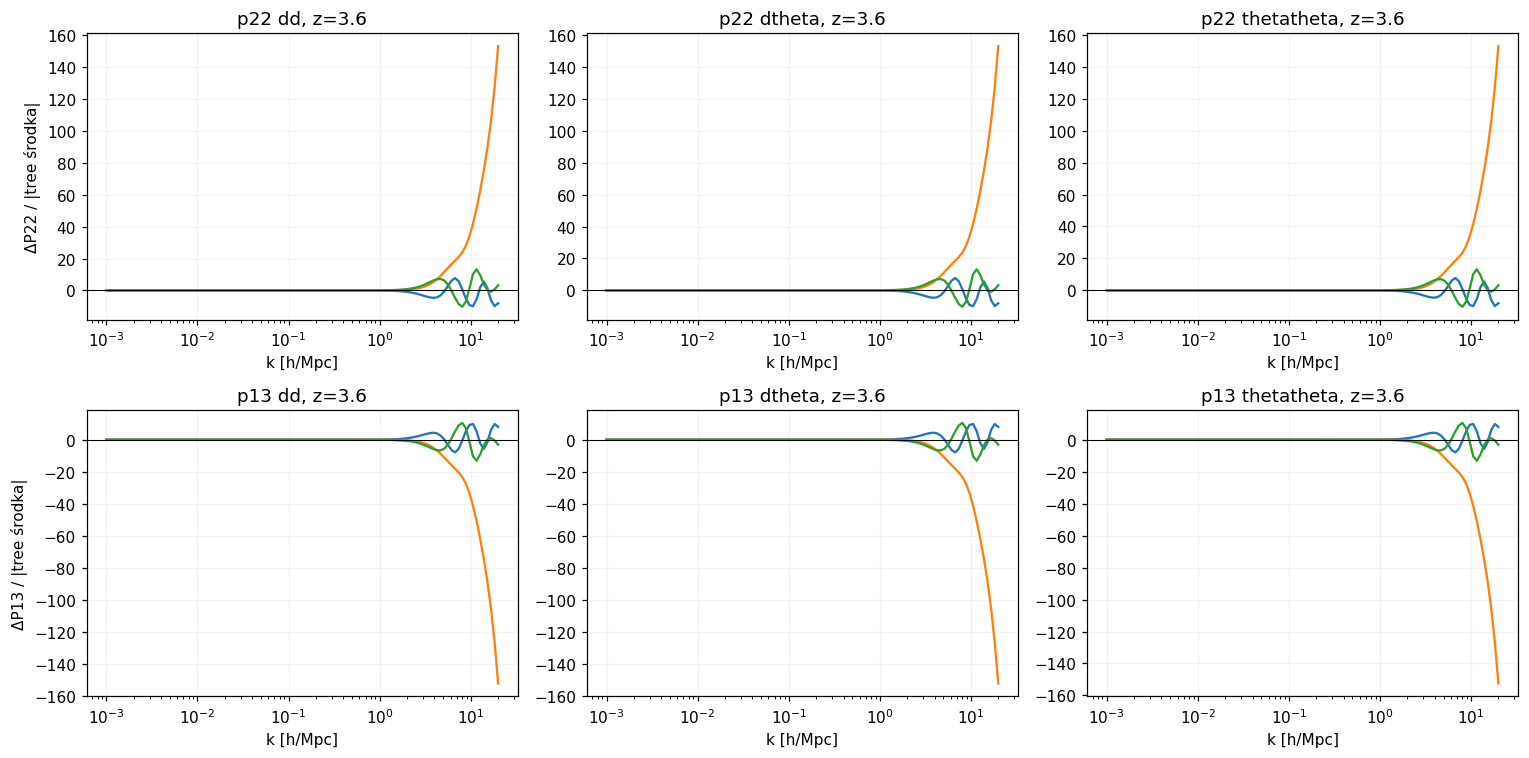

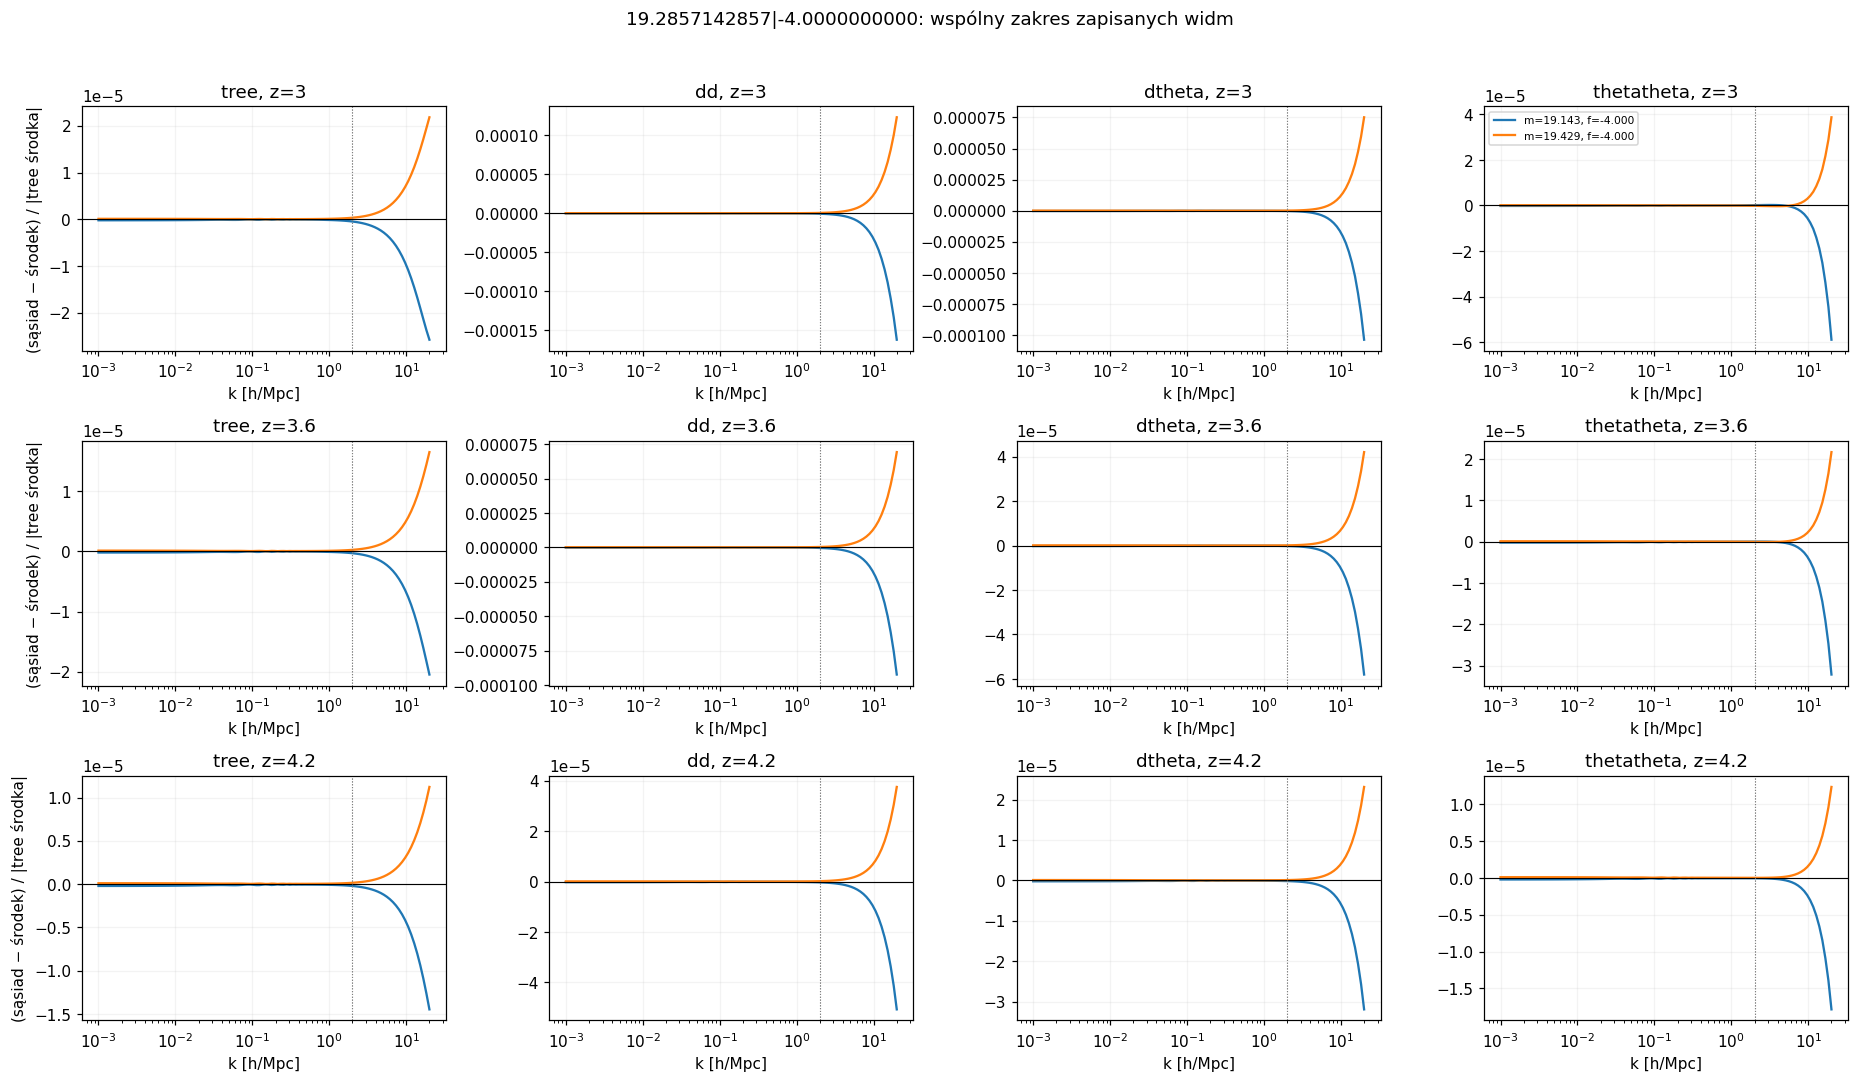

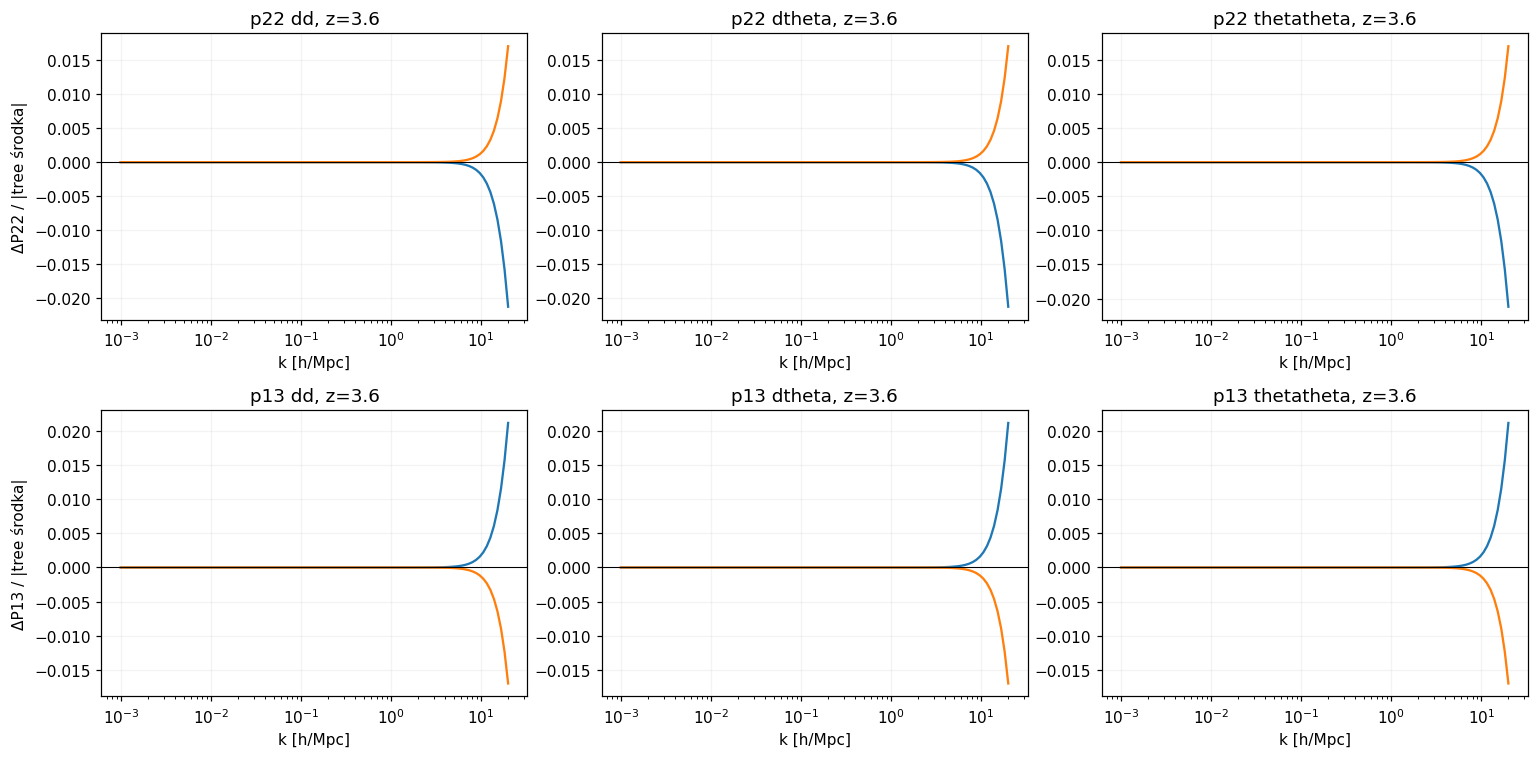

Wczytane widma: 23 ; błędy/braki: 0


,a,b,z,channel,scope,k_min,k_max,n_k,max_abs_diff_over_tree,rms_diff_over_tree,max_abs_difference,source_changed,resolution_changed
1600,17.2857142857|-0.3000000000,17.2857142857|-0.2000000000,3.0,dd,full_common_bundle,0.001,20.0,110,1.077409,0.317752,0.200186,False,False
1601,17.2857142857|-0.3000000000,17.2857142857|-0.2000000000,3.0,dd,common_projection_range,0.001,20.0,110,1.077409,0.317752,0.200186,False,False
1517,17.1428571429|-0.3000000000,17.1428571429|-0.2000000000,3.0,dd,common_projection_range,0.001,20.0,110,1.056098,0.319053,0.194376,False,False
1516,17.1428571429|-0.3000000000,17.1428571429|-0.2000000000,3.0,dd,full_common_bundle,0.001,20.0,110,1.056098,0.319053,0.194376,False,False
1432,17.1428571429|-0.4000000000,17.1428571429|-0.3000000000,3.0,dd,full_common_bundle,0.001,20.0,110,1.022142,0.300473,0.142121,False,False
1433,17.1428571429|-0.4000000000,17.1428571429|-0.3000000000,3.0,dd,common_projection_range,0.001,20.0,110,1.022142,0.300473,0.142121,False,False
1097,14.7142857143|-0.2000000000,14.7142857143|-0.1000000000,3.0,dd,common_projection_range,0.001,20.0,110,0.987892,0.318476,23.472697,False,False
1096,14.7142857143|-0.2000000000,14.7142857143|-0.1000000000,3.0,dd,full_common_bundle,0.001,20.0,110,0.987892,0.318476,23.472697,False,False
1612,17.2857142857|-0.3000000000,17.2857142857|-0.2000000000,3.2,dd,full_common_bundle,0.001,20.0,110,0.982590,0.290984,0.221651,False,False
1613,17.2857142857|-0.3000000000,17.2857142857|-0.2000000000,3.2,dd,common_projection_range,0.001,20.0,110,0.982590,0.290984,0.221651,False,False


In [14]:
THEORIES = {}
THEORY_ERRORS = []
theory_metadata_rows = []

def get_theory(key):
    if key in THEORIES:
        return THEORIES[key]
    if not (PROJECT_ROOT/'lyalpha_pt').is_dir():
        raise FileNotFoundError('Brak kodu lyalpha_pt w PROJECT_ROOT.')
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0,str(PROJECT_ROOT))
    from lyalpha_pt.theory import load_theory
    import inspect
    source=Path(inspect.getfile(load_theory)).resolve()
    if PROJECT_ROOT.resolve() not in source.parents:
        raise RuntimeError('Zaimportowano lyalpha_pt z innego projektu. Zrestartuj kernel.')
    path=remap_path(points.loc[key,'theory_path'])
    if path is None or not path.is_file():
        raise FileNotFoundError(f'Brak teorii: {path}')
    t=load_theory(path)
    k=np.asarray(t.k_loop,dtype=float)
    z=np.asarray(t.z,dtype=float)
    if k.ndim!=1 or np.any(k<=0) or np.any(np.diff(k)<=0):
        raise ValueError('Nieprawidłowa siatka k_loop.')
    if np.shape(t.p_tree)!=(len(z),len(k)) or np.shape(t.channels_one_loop)!=(len(z),len(k),3):
        raise ValueError('Format bundle nie odpowiada API z notebooka 04.')
    for arr in (t.p_tree,t.channels_one_loop):
        if not np.isfinite(arr).all(): raise ValueError('Widmo zawiera NaN/Inf.')
    THEORIES[key]=t
    meta=t.metadata
    theory_metadata_rows.append(dict(coordinate_key=key,theory_path=str(path),bundle_digest=meta.get('bundle_digest'),
        loop_weight=getattr(t,'loop_weight',None),loop_formula=meta.get('loop_formula'),
        loop_source=meta.get('loop_source'),p13_method=meta.get('p13_method'),
        k_min=float(k.min()),k_max=float(k.max()),n_k=len(k),redshifts=json.dumps(z.tolist()),
        numerics=json.dumps(meta.get('numerics',{}),sort_keys=True),
        model=json.dumps(meta.get('model',{}),sort_keys=True)))
    return t

def common_spectra(ta,tb,iz_a,iz_b,field,channel=None):
    lo=max(float(ta.k_loop[0]),float(tb.k_loop[0]))
    hi=min(float(ta.k_loop[-1]),float(tb.k_loop[-1]))
    if hi<=lo: raise ValueError('Brak wspólnego zakresu k.')
    k=np.unique(np.r_[ta.k_loop,tb.k_loop])
    k=k[(k>=lo)&(k<=hi)]
    aa=np.asarray(getattr(ta,field))[iz_a]
    bb=np.asarray(getattr(tb,field))[iz_b]
    if channel is not None: aa,bb=aa[:,channel],bb[:,channel]
    va=np.interp(np.log(k),np.log(ta.k_loop),aa)
    vb=np.interp(np.log(k),np.log(tb.k_loop),bb)
    tree=np.interp(np.log(k),np.log(ta.k_loop),ta.p_tree[iz_a])
    scale=np.maximum(np.abs(tree),max(float(np.median(np.abs(tree)))*1e-12,1e-300))
    return k,va,vb,scale

spectral_rows=[]
if RUN_SPECTRA:
    for key in selected_keys:
        try: get_theory(key)
        except Exception as exc: THEORY_ERRORS.append(dict(coordinate_key=key,error=str(exc)))
    spectral_pairs=pairs.loc[pairs.a.isin(selected_keys)&pairs.b.isin(selected_keys)]
    for pair in spectral_pairs.itertuples():
        if pair.a not in THEORIES or pair.b not in THEORIES: continue
        ta,tb=THEORIES[pair.a],THEORIES[pair.b]
        for ia,z in enumerate(ta.z):
            matches=np.flatnonzero(np.isclose(tb.z,z,rtol=0,atol=1e-8))
            if len(matches)!=1:
                THEORY_ERRORS.append(dict(coordinate_key=pair.b,error=f'Brak zgodnego z={z} z {pair.a}'))
                continue
            ib=int(matches[0])
            fields=[('p_tree',None,'tree')]+[('channels_one_loop',j,c) for j,c in enumerate(['dd','dtheta','thetatheta'])]
            for field,channel,label in fields:
                k,va,vb,scale=common_spectra(ta,tb,ia,ib,field,channel)
                difference=(vb-va)/scale
                ranges={'k_le_2':2.,'full_common_bundle':float(k[-1])}
                cutoffs=[number(points.loc[key].get('k_uv_cut_hmpc')) for key in (pair.a,pair.b)]
                if all(np.isfinite(cutoffs)):
                    ranges['common_projection_range']=min(cutoffs)
                for scope,upper in ranges.items():
                    mask=k<=upper*(1+1e-12)
                    if not mask.any(): continue
                    spectral_rows.append(dict(a=pair.a,b=pair.b,z=float(z),channel=label,scope=scope,
                        k_min=float(k[mask][0]),k_max=float(k[mask][-1]),n_k=int(mask.sum()),
                        max_abs_diff_over_tree=float(np.max(np.abs(difference[mask]))),
                        rms_diff_over_tree=float(np.sqrt(np.mean(difference[mask]**2))),
                        max_abs_difference=float(np.max(np.abs(vb[mask]-va[mask]))),
                        source_changed=pair.source_changed,resolution_changed=pair.resolution_changed))
    # Dla każdego sąsiedztwa porównanie liniowego widma i 3 kanałów na 3 redshiftach.
    for si,s in enumerate(stencils):
        center=s['center']
        if center not in THEORIES: continue
        ta=THEORIES[center]
        izs=sorted(set([0,len(ta.z)//2,len(ta.z)-1]))
        fig,axes=plt.subplots(len(izs),4,figsize=(17,3.2*len(izs)),squeeze=False)
        for row,ia in enumerate(izs):
            z=ta.z[ia]
            for key in s['keys']:
                if key==center or key not in THEORIES: continue
                tb=THEORIES[key]
                match=np.flatnonzero(np.isclose(tb.z,z,rtol=0,atol=1e-8))
                if len(match)!=1: continue
                for ax,(field,ch,label) in zip(axes[row],[('p_tree',None,'tree')]+[('channels_one_loop',j,c) for j,c in enumerate(['dd','dtheta','thetatheta'])]):
                    k,va,vb,scale=common_spectra(ta,tb,ia,int(match[0]),field,ch)
                    r=points.loc[key]
                    ax.plot(k,(vb-va)/scale,label=f'm={r.log10m_acc:.3f}, f={r.log10f_acc:.3f}')
                    ax.set(xscale='log',xlabel='k [h/Mpc]',title=f'{label}, z={z:g}')
                    ax.axhline(0,color='black',lw=.7)
                    ax.axvline(2,color='grey',ls=':',lw=.7)
            axes[row,0].set_ylabel('(sąsiad − środek) / |tree środka|')
        axes[0,-1].legend(fontsize=7)
        fig.suptitle(f'{center}: wspólny zakres zapisanych widm',y=1.02)
        show_figure(f'stencil_{si:02d}_spectra',fig)
        # P22/P13 są opcjonalne; iloraz względem dodatniego tree zamiast dzielenia przez P22/P13.
        if all(hasattr(ta,field) for field in ('p22','p13')):
            ia=len(ta.z)//2
            fig,axes=plt.subplots(2,3,figsize=(14,7),squeeze=False)
            for row,field in enumerate(('p22','p13')):
                for j,channel in enumerate(('dd','dtheta','thetatheta')):
                    ax=axes[row,j]
                    for key in s['keys']:
                        if key==center or key not in THEORIES or not hasattr(THEORIES[key],field): continue
                        tb=THEORIES[key]
                        match=np.flatnonzero(np.isclose(tb.z,ta.z[ia],atol=1e-8,rtol=0))
                        if len(match)!=1: continue
                        k,va,vb,scale=common_spectra(ta,tb,ia,int(match[0]),field,j)
                        ax.plot(k,(vb-va)/scale,label=key)
                    ax.set(xscale='log',xlabel='k [h/Mpc]',title=f'{field} {channel}, z={ta.z[ia]:g}')
                    ax.axhline(0,color='black',lw=.7)
            axes[0,0].set_ylabel('ΔP22 / |tree środka|')
            axes[1,0].set_ylabel('ΔP13 / |tree środka|')
            show_figure(f'stencil_{si:02d}_loop_components',fig)
spectral_comparison=pd.DataFrame(spectral_rows)
save_table('neighbor_spectral_comparison',spectral_comparison)
save_table('theory_metadata',pd.DataFrame(theory_metadata_rows))
save_table('theory_errors',pd.DataFrame(THEORY_ERRORS))
print('Wczytane widma:',len(THEORIES),'; błędy/braki:',len(THEORY_ERRORS))
if not spectral_comparison.empty:
    display(spectral_comparison.sort_values('max_abs_diff_over_tree',ascending=False).head(20))
if THEORY_ERRORS: display(pd.DataFrame(THEORY_ERRORS).head(10))


## 6. Odtworzenie likelihood i test zamiany nuisance

Ta część wykorzystuje publiczne API z `04_analyze_any_model.ipynb`:
`load_dr12`, `load_theory`, `EffectiveModelFit.model`, `.chi2` i `.chi2_by_redshift`.
Najpierw sprawdza kolejność nuisance, digest NPZ/JSON, dane, cutoff, granice oraz reprodukcję zapisanego χ².
Nie zakłada domyślnie `paper_diag` ani cutoffu 20: wartości muszą wynikać z JSON lub jawnego override.
Przy innej wersji API błąd zostaje zapisany w `likelihood_reproduction.csv`; testy tego punktu są pomijane.

Dla teorii i oraz zapisanych nuisance punktu j liczymy \(X_{ij}=\chi^2(\theta_i,\hat\eta_j)\).
Jeśli dopuszczalne nuisance dawcy dają χ² niższe od odtworzonego wyniku i ponad tolerancję,
jest to **dowód istnienia lepszego dopuszczalnego punktu**, a nie dowód znalezienia nowego minimum globalnego.
Nuisance poza zakresem docelowego punktu są oznaczane i nie są przycinane do granic.

Przy wykresach P1D „wspólne nuisance” oznaczają identyczne **współrzędne fitu**.
We wcześniejszej implementacji fizyczna amplituda countertermu zależała również od `i0_scale`.
Zatem identyczne `alpha_ct` przy różnych teoriach nie musi oznaczać identycznej amplitudy fizycznej.
Nie wykonujemy niepotwierdzonego przeskalowania; ta uwaga nie osłabia testu lepszego dopuszczalnego punktu.

Reszty na wykresach są wyrażone w błędach diagonalnych. Przy skorelowanej kowariancji nie są niezależnymi
whitened residuals. Wkłady per-z pochodzą z metody kanonicznej; ich niezależna interpretacja wymaga
braku korelacji między blokami redshiftu.


In [15]:
# Adapter do rzeczywistego API lyalpha_pt, potwierdzonego w notebooku
# 04_analyze_any_model.ipynb i zapisanym fit JSON wersji v3.3.
# Wymaga globals: PROJECT_ROOT, remap_path, PARAMETER_NAMES,
# DIAGONAL_ATOL, DIAGONAL_RTOL, FIT_CONFIG_OVERRIDE.
# JSON nie zawiera samych krzywych: potrzebne są source + NPZ + dane DR12.

def _require_file(raw_path, label):
    path = remap_path(raw_path)
    if path is None:
        raise FileNotFoundError(f'{label}: brak ścieżki')
    path = Path(path).expanduser()
    if not path.is_absolute():
        path = Path(PROJECT_ROOT) / path
    if not path.is_file():
        raise FileNotFoundError(f'{label}: {path}')
    return path.resolve()


def _saved_bounds(record):
    rows = record.get('boundary_diagnostics', [])
    by_name = {row['parameter']: row for row in rows}
    missing = [name for name in PARAMETER_NAMES if name not in by_name]
    if missing:
        raise ValueError('Brak zapisanych granic dla: ' + ', '.join(missing))
    bounds = np.array([[by_name[name]['lower'], by_name[name]['upper']]
                       for name in PARAMETER_NAMES], dtype=float)
    if bounds.shape != (len(PARAMETER_NAMES), 2):
        raise ValueError('Nieprawidłowy kształt zapisanych granic nuisance.')
    if not np.isfinite(bounds).all() or np.any(bounds[:, 1] <= bounds[:, 0]):
        raise ValueError('Nieprawidłowe zapisane granice nuisance.')
    return bounds


def nuisance_is_admissible(context, theta, tolerance=1.e-10):
    theta = np.asarray(theta, dtype=float)
    bounds = context['bounds']
    return bool(theta.shape == (len(PARAMETER_NAMES),)
                and np.isfinite(theta).all()
                and np.all(theta >= bounds[:, 0] - tolerance)
                and np.all(theta <= bounds[:, 1] + tolerance))


def load_diagnostic_context(row, mode='one_loop'):
    """Odtwórz likelihood; zwróć kontekst wyłącznie po kontroli digest i chi2.

    FIT_CONFIG_OVERRIDE może zawierać data_dir, k_uv_cut_hmpc,
    covariance_mode oraz constructor_kwargs. Każde nadpisanie jest raportowane.
    Dla brakujących kluczowych metadanych nie przyjmujemy liczby 20/paper_diag.
    """
    import sys
    import hashlib
    import inspect
    root = Path(PROJECT_ROOT).resolve()
    if not (root / 'lyalpha_pt').is_dir():
        raise FileNotFoundError('Brak lyalpha_pt w PROJECT_ROOT; potrzebny rzeczywisty kod projektu.')
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    from lyalpha_pt.data import load_dr12
    from lyalpha_pt.fit import EffectiveModelFit, PARAMETER_NAMES as API_NAMES
    from lyalpha_pt.theory import load_theory

    if tuple(API_NAMES) != tuple(PARAMETER_NAMES):
        raise ValueError(f'Kolejność parametrów API różni się od notebooka: {API_NAMES}')
    source_path = Path(inspect.getfile(EffectiveModelFit)).resolve()
    if root not in source_path.parents:
        raise RuntimeError(f'Import lyalpha_pt wskazuje inny projekt: {source_path}. Zrestartuj kernel.')

    fit_path = _require_file(row['fit_path'], 'Fit JSON')
    saved = json.loads(fit_path.read_text(encoding='utf-8'))
    if mode not in saved.get('fits', {}):
        raise ValueError(f'{fit_path}: brak fits[{mode!r}].')
    record = saved['fits'][mode]
    if record.get('mode', mode) != mode:
        raise ValueError('Niezgodne pole mode w zapisanym fit JSON.')
    parameters = record['parameters']
    theta = np.array([parameters[name] for name in PARAMETER_NAMES], dtype=float)
    if not np.isfinite(theta).all():
        raise ValueError('Niefinitywne zapisane nuisance.')
    bounds = _saved_bounds(record)
    chi2_saved = float(record['chi2'])
    if not np.isfinite(chi2_saved):
        raise ValueError('Niefinitywne zapisane chi2.')
    if mode == 'one_loop' and not np.isclose(chi2_saved, number(row.get('chi2_one_loop')), atol=DIAGONAL_ATOL, rtol=DIAGONAL_RTOL):
        raise ValueError('χ² aktualnego JSON różni się od tabeli; odśwież snapshot.')
    for name, value in zip(PARAMETER_NAMES, theta):
        previous = number(row.get('parameter_' + name))
        if np.isfinite(previous) and not np.isclose(previous, value, atol=1e-8, rtol=1e-8):
            raise ValueError(f'Nuisance {name} w JSON różni się od tabeli; odśwież snapshot.')

    override = dict(FIT_CONFIG_OVERRIDE)
    supported = {'data_dir', 'k_uv_cut_hmpc', 'covariance_mode', 'constructor_kwargs'}
    unknown = set(override) - supported
    if unknown:
        raise ValueError(f'Nieznane FIT_CONFIG_OVERRIDE: {sorted(unknown)}')
    config = {}
    for name in ('k_uv_cut_hmpc', 'covariance_mode'):
        value = override[name] if name in override else record.get(name)
        if value is None:
            raise ValueError(f'Brak {name} w fit JSON: uzupełnij FIT_CONFIG_OVERRIDE z dokumentacji kampanii.')
        config[name] = value
    config['k_uv_cut_hmpc'] = float(config['k_uv_cut_hmpc'])
    if not np.isfinite(config['k_uv_cut_hmpc']) or config['k_uv_cut_hmpc'] <= 0:
        raise ValueError('Nieprawidłowy cutoff zapisanej projekcji.')

    raw_data_dir = override.get('data_dir', saved.get('data_dir'))
    if raw_data_dir is None:
        raise ValueError('Brak data_dir w fit JSON; wskaż rzeczywiste dane w FIT_CONFIG_OVERRIDE.')
    data_dir = Path(remap_path(raw_data_dir)).expanduser()
    if not data_dir.is_absolute():
        data_dir = root / data_dir
    if not data_dir.is_dir():
        raise FileNotFoundError(f'Dane DR12: {data_dir}; ustaw FIT_CONFIG_OVERRIDE["data_dir"].')
    theory_path = _require_file(row['theory_path'], 'Theory NPZ')
    theory = load_theory(theory_path)  # canonical loader sprawdza integralność bundle
    digest = theory.metadata.get('bundle_digest')
    if not digest or not record.get('theory_digest'):
        raise ValueError('Brak digest teorii lub digest w fit JSON: nie można potwierdzić pary.')
    if record['theory_digest'] != digest:
        raise ValueError('Fit JSON i NPZ mają różne theory_digest / bundle_digest.')
    dataset = load_dr12(data_dir)
    if 'n_data' in record and dataset.n_data != int(record['n_data']):
        raise ValueError('Liczba punktów DR12 różni się od zapisanej w fit JSON.')
    if np.shape(dataset.z_unique) != np.shape(theory.z) or not np.allclose(dataset.z_unique, theory.z):
        raise ValueError('Redshifty danych i bundle teorii różnią się.')
    cutoff = config['k_uv_cut_hmpc']
    if cutoff > np.max(theory.k_loop) * (1 + 1.e-12):
        raise ValueError('Cutoff przekracza zakres zapisanych kanałów one-loop.')
    kwargs = dict(override.get('constructor_kwargs', {}))
    if set(kwargs) & {'mode', 'k_uv_cut', 'covariance_mode'}:
        raise ValueError('mode, k_uv_cut i covariance_mode nie mogą być w constructor_kwargs.')
    fitter = EffectiveModelFit(dataset, theory, mode=mode, k_uv_cut=cutoff,
                               covariance_mode=config['covariance_mode'], **kwargs)
    reconstructed = float(fitter.chi2(theta))
    context = {'fitter': fitter, 'theory': theory, 'dataset': dataset,
               'theta': theta, 'record': record, 'saved': saved, 'bounds': bounds,
               'chi2_saved': chi2_saved, 'chi2_recomputed': reconstructed,
               'fit_path': str(fit_path), 'theory_path': str(theory_path),
               'data_dir': str(data_dir), 'mode': mode, 'config': config,
               'overrides': override, 'validated': False,
               'source_path': str(source_path),
               'source_sha256': hashlib.sha256(source_path.read_bytes()).hexdigest()}
    if not nuisance_is_admissible(context, theta):
        raise ValueError('Zapisane minimum leży poza zapisanym zakresem nuisance.')
    if not np.isclose(reconstructed, chi2_saved, atol=DIAGONAL_ATOL, rtol=DIAGONAL_RTOL):
        raise RuntimeError(f'Nie odtworzono chi2: saved={chi2_saved:.12g}, '
                           f'recomputed={reconstructed:.12g}. '
                           'Sprawdź wersję kodu, dane, projekcję i ustawienia; test zamiany jest zablokowany.')
    context['validated'] = True
    return context


def evaluate_context(context, theta, enforce_bounds=True):
    """Canonical model/chi2; poza boxem nie wyciągamy wniosku o lepszym minimum."""
    if not context.get('validated', False):
        raise RuntimeError('Najpierw odtwórz zapisane chi2 i zweryfikuj digest.')
    theta = np.asarray(theta, dtype=float)
    if theta.shape != (len(PARAMETER_NAMES),) or not np.isfinite(theta).all():
        raise ValueError('Niewłaściwy wektor nuisance.')
    admissible = nuisance_is_admissible(context, theta)
    if enforce_bounds and not admissible:
        raise ValueError('Nuisance są poza zapisanym boxem punktu docelowego.')
    fitter = context['fitter']
    chi2 = float(fitter.chi2(theta))
    prediction = np.asarray(fitter.model(theta), dtype=float)
    if not np.isfinite(chi2) or not np.isfinite(prediction).all():
        raise ValueError('Niefinitywna predykcja lub chi2.')
    return {'chi2': chi2, 'p1d': prediction,
            'per_z': fitter.chi2_by_redshift(theta), 'admissible': admissible}


def neighbor_transfer_theta(target, source, preserve_physical_counterterm=False):
    """Surowy transfer współrzędnych optymalizatora; żadnego clipowania granic."""
    if not target.get('validated') or not source.get('validated'):
        raise RuntimeError('Oba konteksty muszą odtwarzać zapisane chi2.')
    if preserve_physical_counterterm:
        raise NotImplementedError('Transfer fizycznego countertermu wymaga potwierdzonego API i0_scale. '
                                  'Raw swap służy testowi optymalizatora, nie stałej fizycznej amplitudzie ct.')
    return np.asarray(source['theta'], dtype=float).copy()


# Opcjonalna późniejsza komórka refitu używa wyłącznie publicznego chi2,
# ze skalowaniem współrzędnych i zapisanymi granicami.


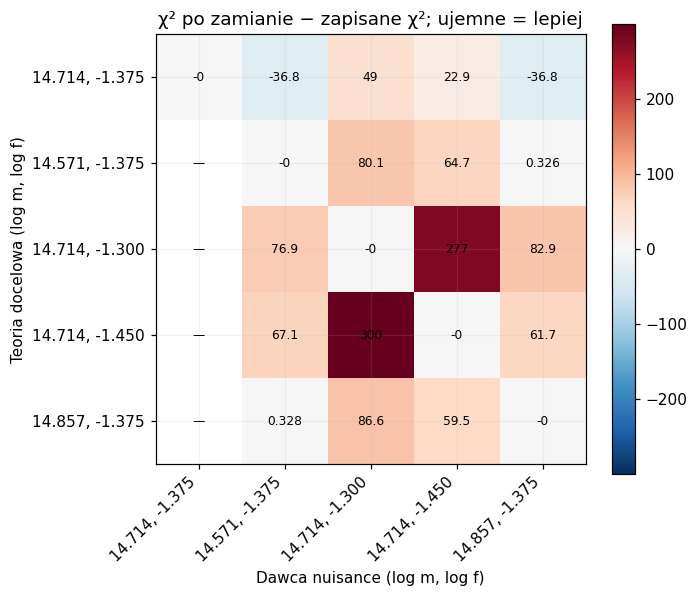

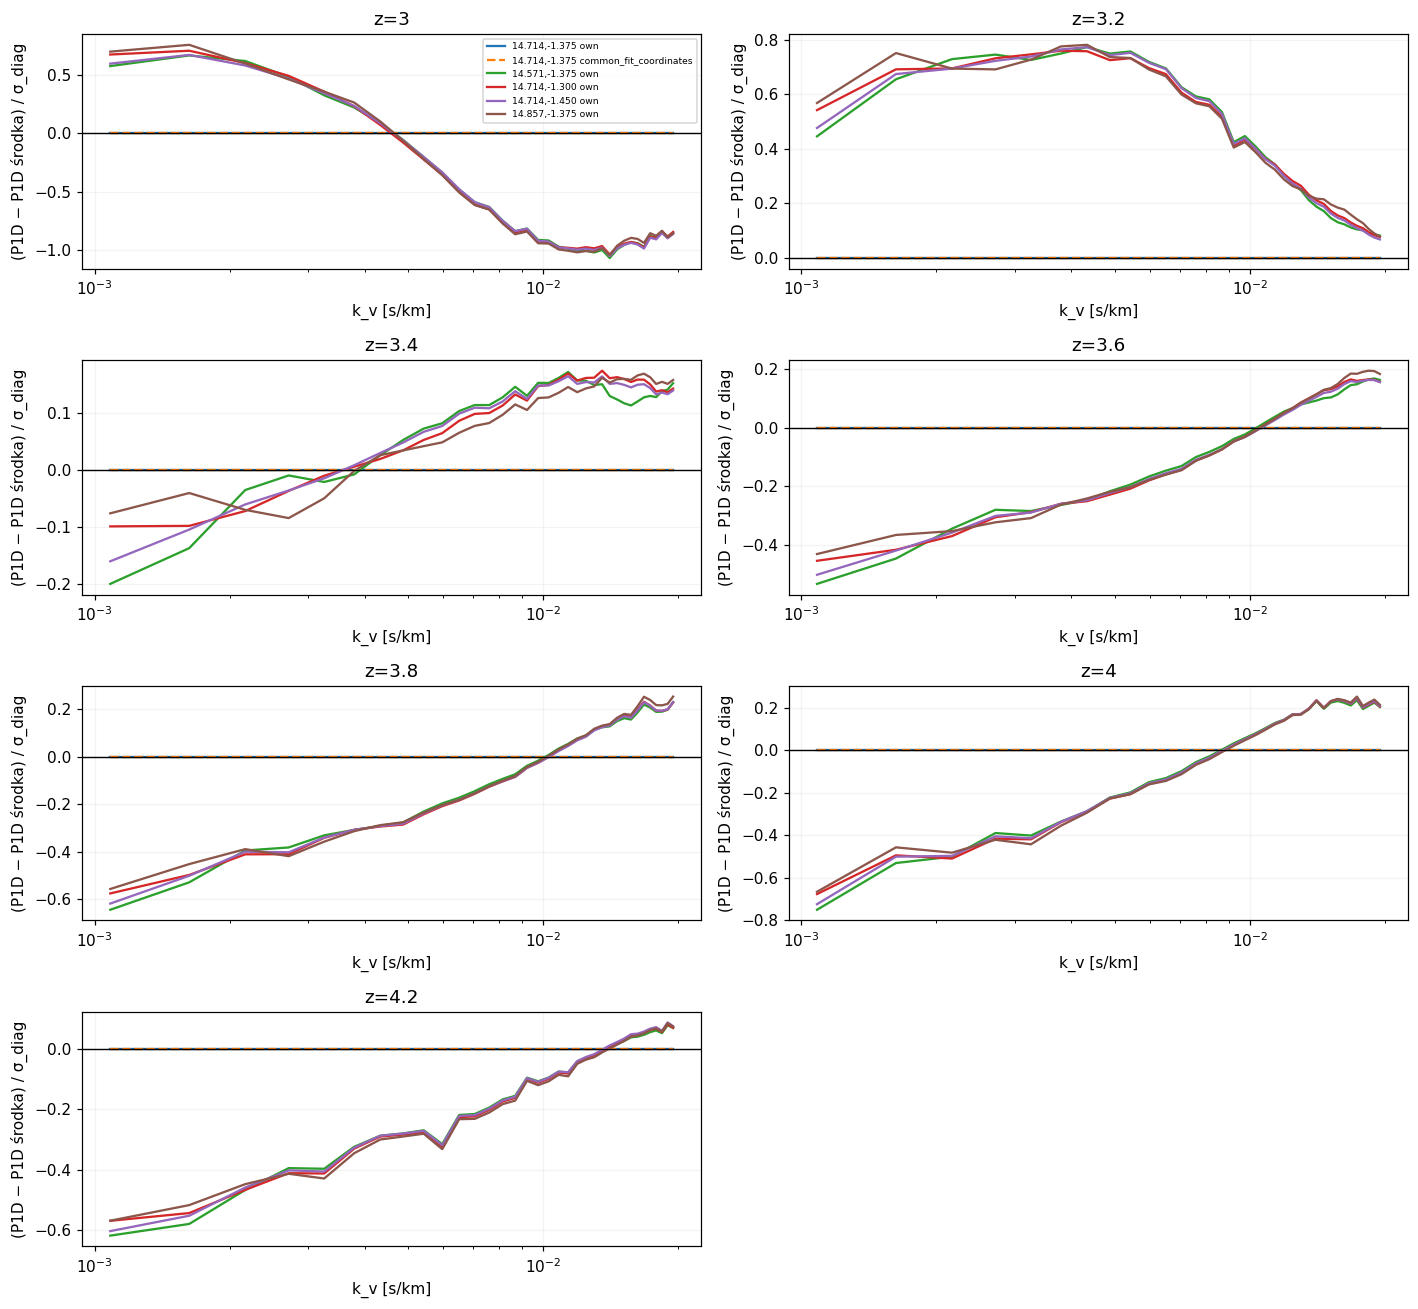

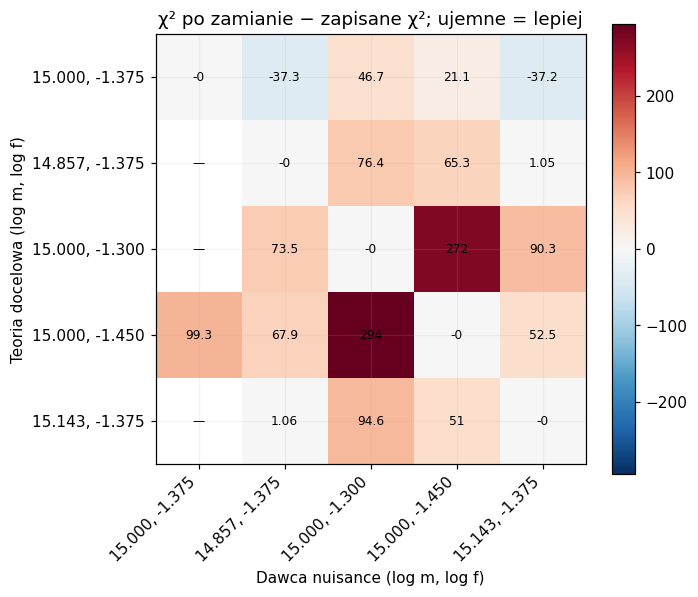

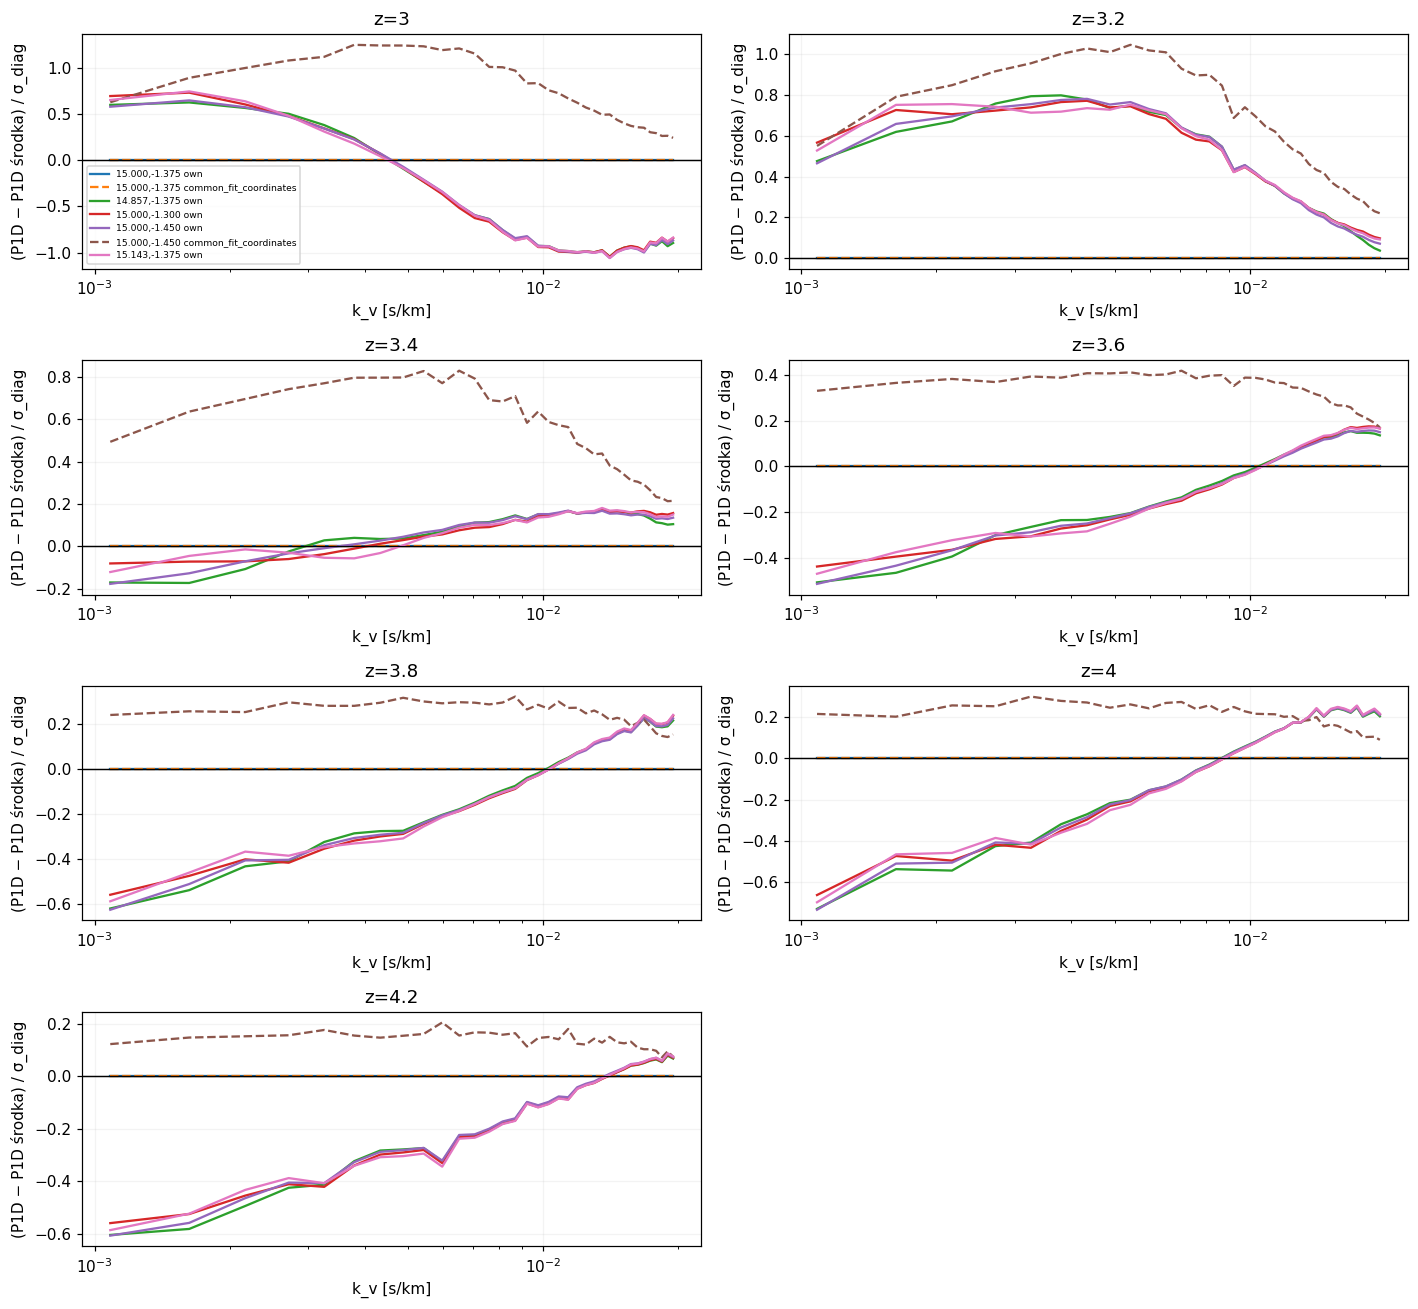

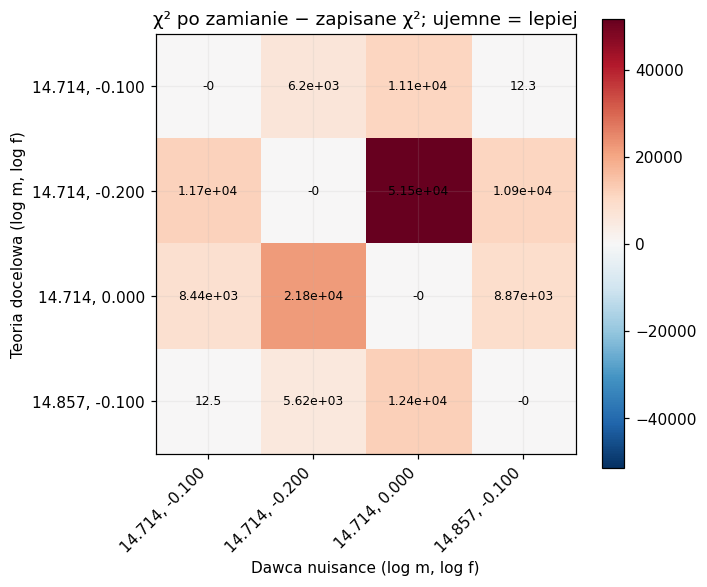

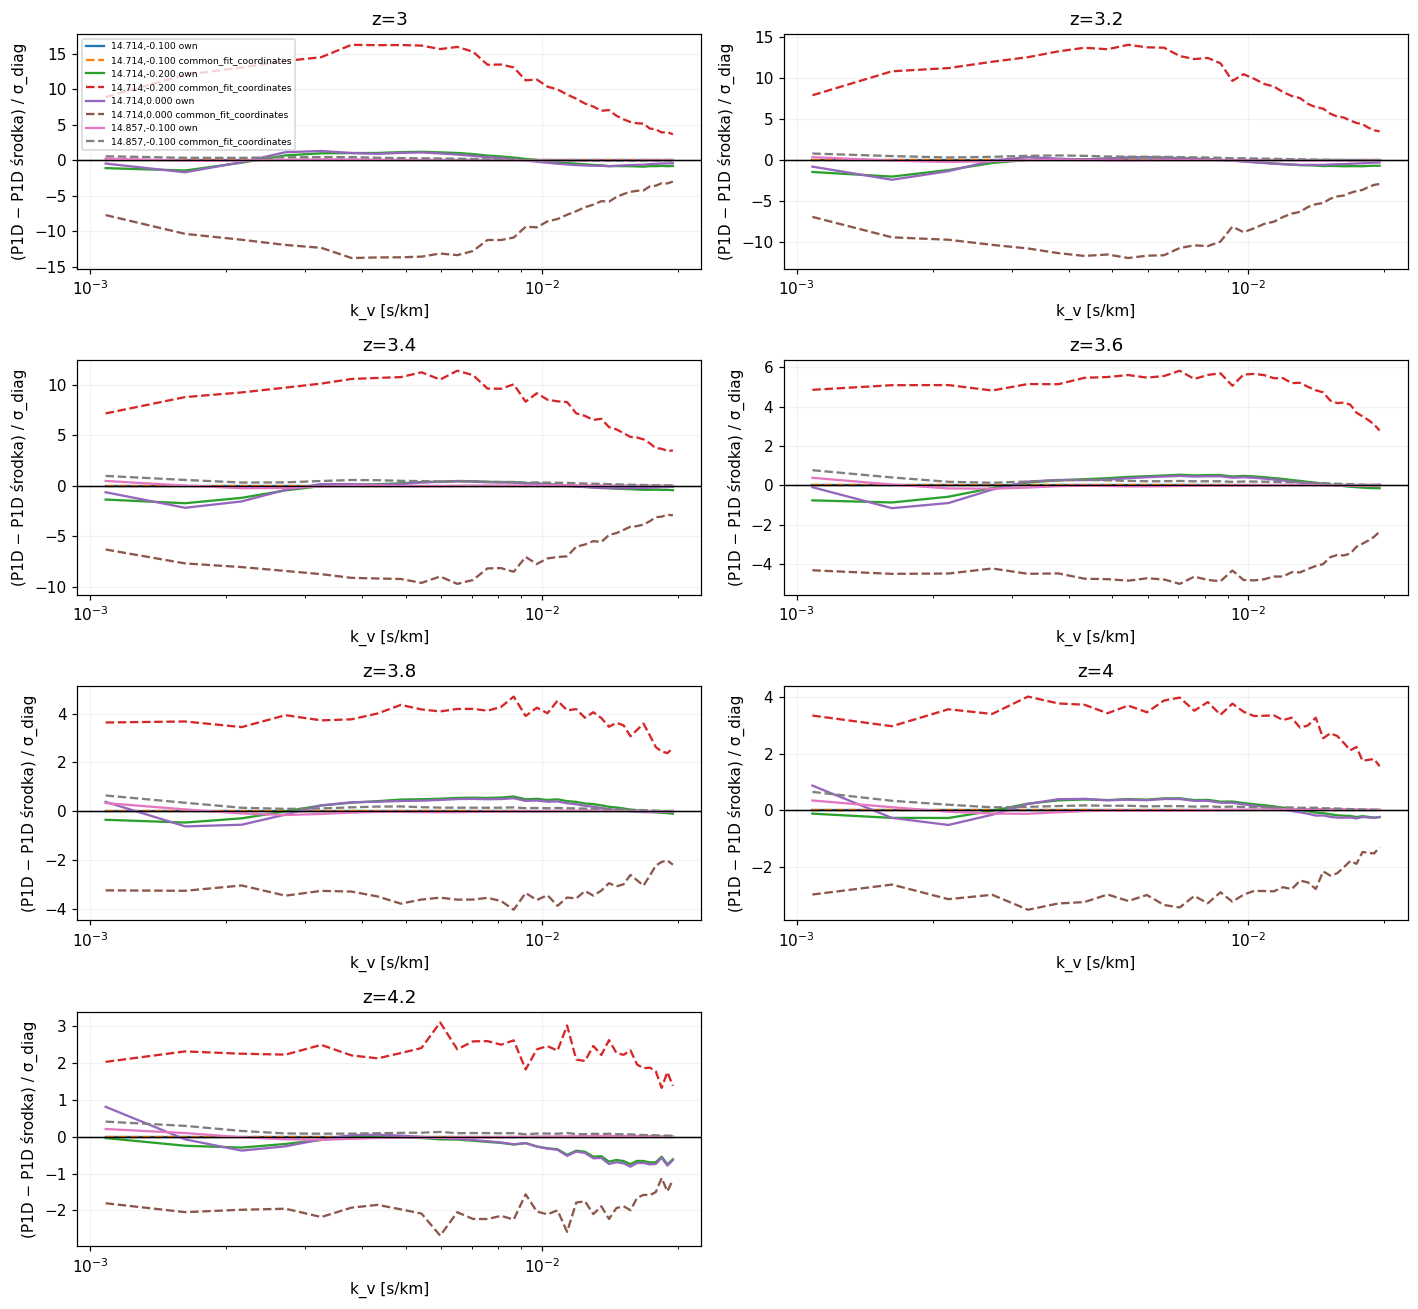

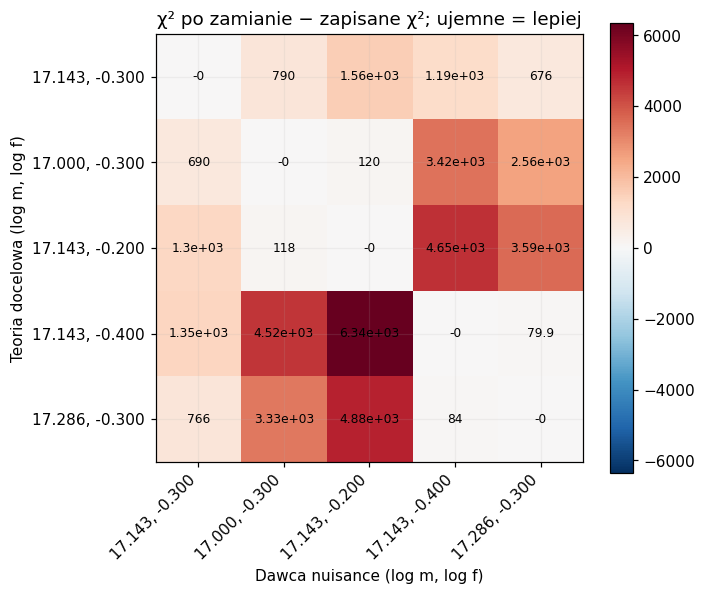

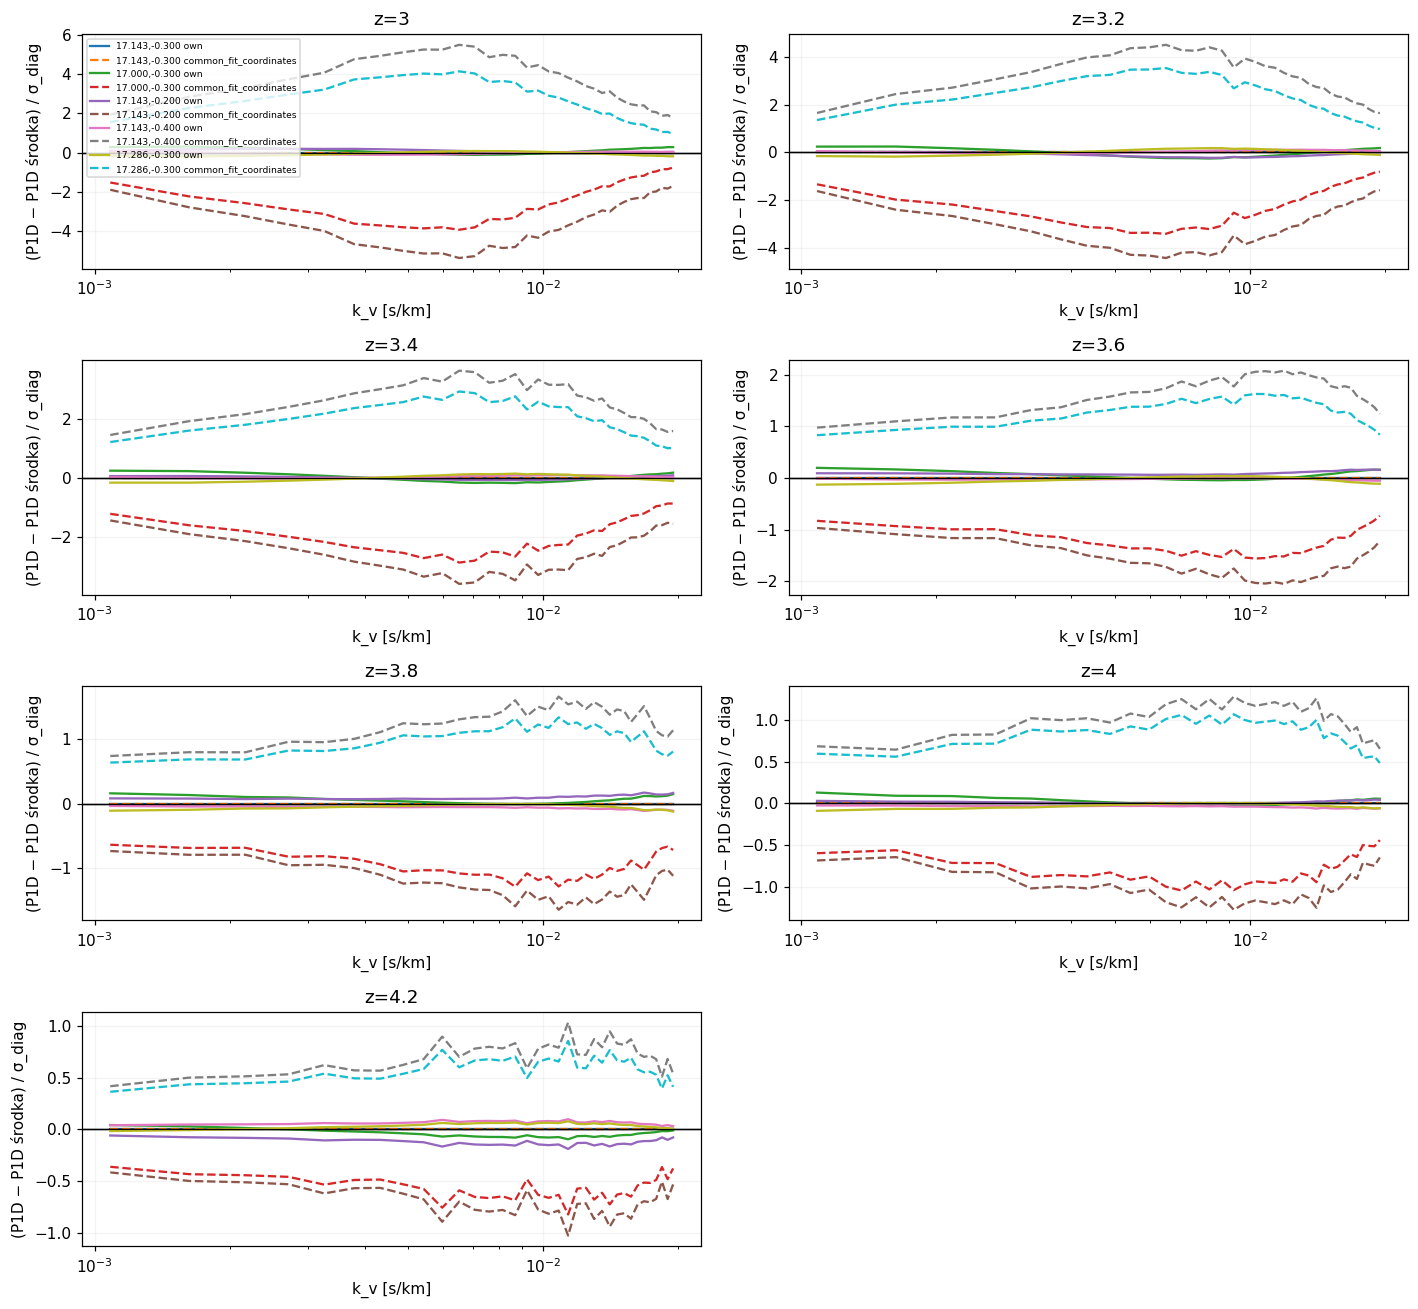

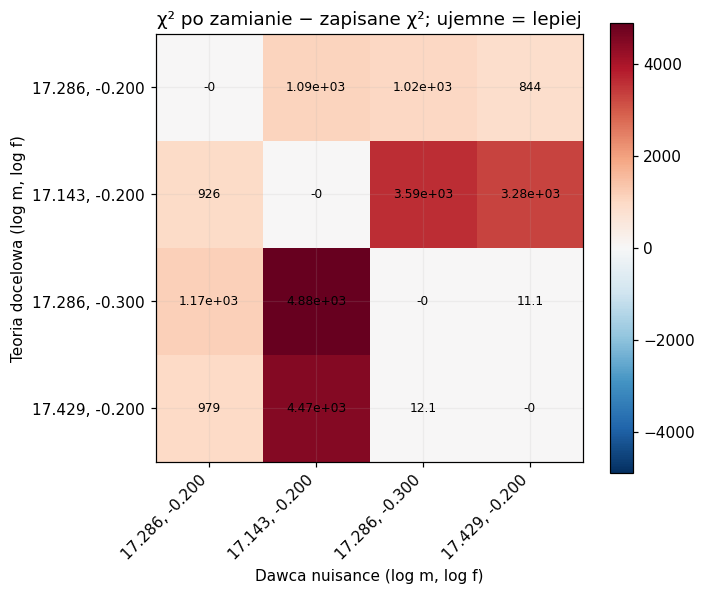

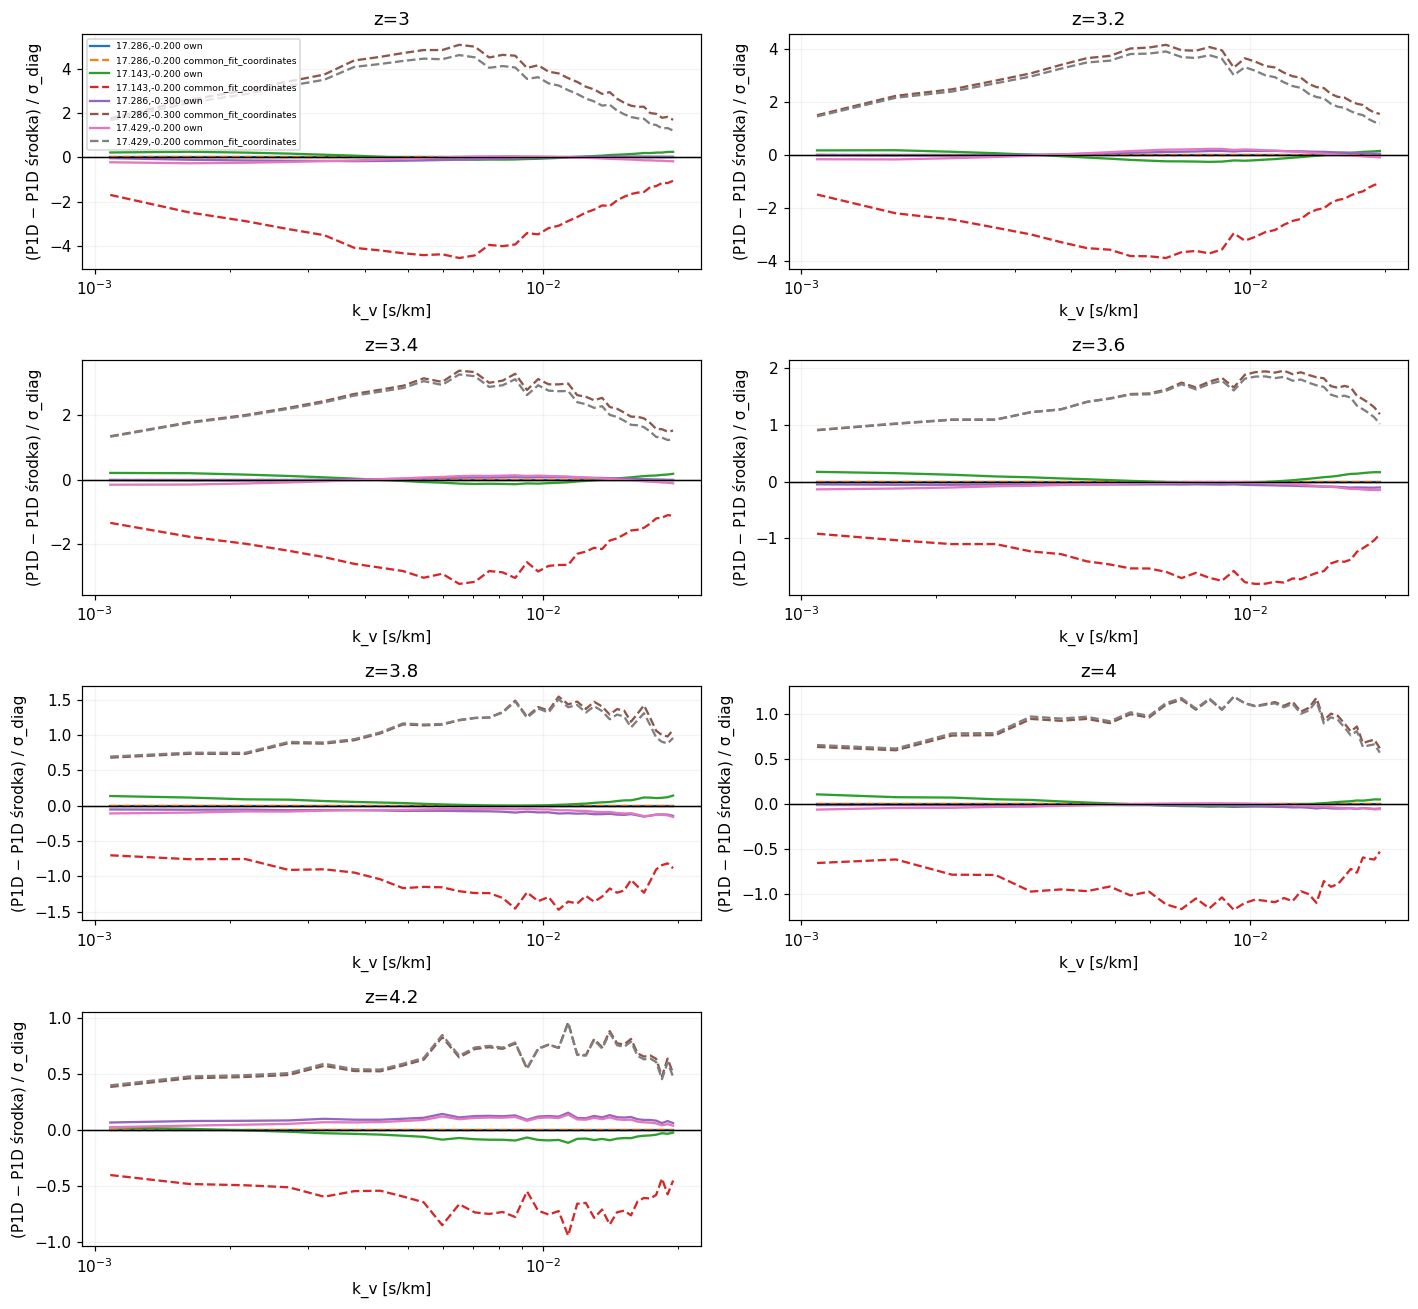

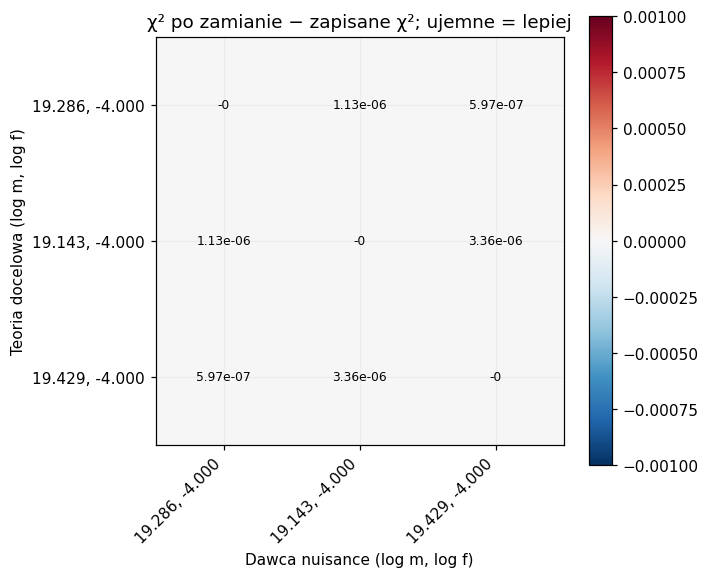

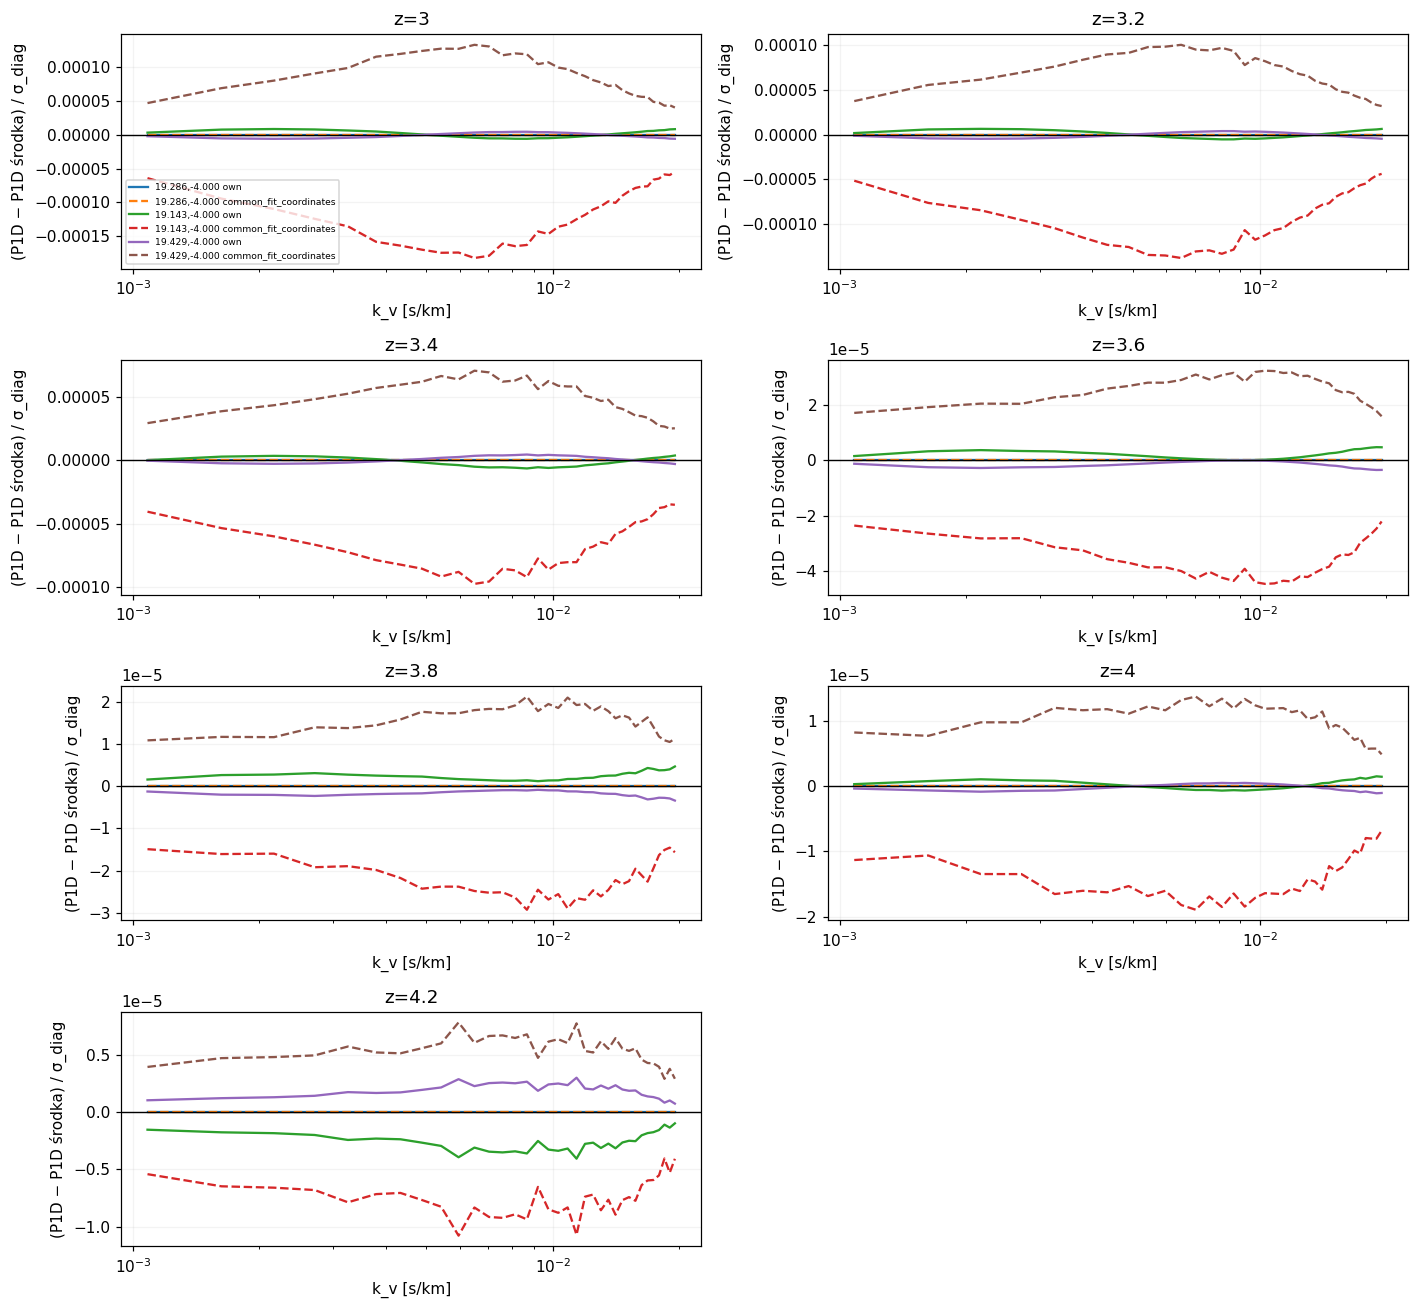

Odtworzone likelihood: 23 / 23


,coordinate_key,status,chi2_saved,chi2_recomputed,difference,cutoff,covariance,source_path,source_sha256,overrides,error
0,14.7142857143|-1.3750000000,validated,228.833338,228.833338,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
1,14.5714285714|-1.3750000000,validated,192.334840,192.334840,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
2,14.7142857143|-1.3000000000,validated,191.786268,191.786268,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
3,14.7142857143|-1.4500000000,validated,192.094637,192.094637,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
4,14.8571428571|-1.3750000000,validated,192.735457,192.735457,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
5,15.0000000000|-1.3750000000,validated,231.245070,231.245070,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
6,15.0000000000|-1.3000000000,validated,194.034045,194.034045,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
7,15.0000000000|-1.4500000000,validated,193.483125,193.483125,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
8,15.1428571429|-1.3750000000,validated,193.720937,193.720937,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},
9,14.7142857143|-0.1000000000,validated,259.808819,259.808819,0.0,20.0,paper_diag,/home/2/ks405818/Master/lyalpha_one_loop/lyalp...,845ec6896c8901df8535d2bc8069344842235e1fc38ba4...,{},


Znalezione dopuszczalne punkty lepsze od zapisanych: 4


,target,donor,admissible,chi2,gain,witness_better_point,status,witness_tolerance
26,15.0000000000|-1.3750000000,14.8571428571|-1.3750000000,True,193.904600,37.340471,True,evaluated,0.001231
29,15.0000000000|-1.3750000000,15.1428571429|-1.3750000000,True,194.039109,37.205961,True,evaluated,0.001231
4,14.7142857143|-1.3750000000,14.8571428571|-1.3750000000,True,192.053545,36.779793,True,evaluated,0.001229
1,14.7142857143|-1.3750000000,14.5714285714|-1.3750000000,True,192.068192,36.765146,True,evaluated,0.001229
65,17.1428571429|-0.3000000000,17.1428571429|-0.3000000000,True,194.352828,0.000000,False,evaluated,0.001194
36,15.0000000000|-1.3000000000,15.0000000000|-1.3000000000,True,194.034045,0.000000,False,evaluated,0.001194
42,15.0000000000|-1.4500000000,15.0000000000|-1.4500000000,True,193.483125,0.000000,False,evaluated,0.001193
48,15.1428571429|-1.3750000000,15.1428571429|-1.3750000000,True,193.720937,0.000000,False,evaluated,0.001194
49,14.7142857143|-0.1000000000,14.7142857143|-0.1000000000,True,259.808819,0.000000,False,evaluated,0.001260
54,14.7142857143|-0.2000000000,14.7142857143|-0.2000000000,True,207.804332,0.000000,False,evaluated,0.001208


In [16]:
CONTEXTS={}
context_rows=[]
cross_rows=[]
prediction_rows=[]
per_z_rows=[]

if RUN_CROSS_EVALUATION:
    for key in selected_keys:
        try:
            ctx=load_diagnostic_context(points.loc[key])
            # CSV może pochodzić ze starszej wersji fitu mimo poprawnej pary bieżący JSON/NPZ.
            if not np.isclose(ctx['chi2_saved'],points.loc[key,'chi2_one_loop'],atol=DIAGONAL_ATOL,rtol=DIAGONAL_RTOL):
                raise ValueError('χ² tabeli nie zgadza się z bieżącym JSON. Odśwież analizę w trybie auto.')
            CONTEXTS[key]=ctx
            context_rows.append(dict(coordinate_key=key,status='validated',chi2_saved=ctx['chi2_saved'],
                chi2_recomputed=ctx['chi2_recomputed'],difference=ctx['chi2_recomputed']-ctx['chi2_saved'],
                cutoff=ctx['config']['k_uv_cut_hmpc'],covariance=ctx['config']['covariance_mode'],
                source_path=ctx['source_path'],source_sha256=ctx['source_sha256'],
                overrides=json.dumps(ctx['overrides'],default=str),error=''))
        except Exception as exc:
            context_rows.append(dict(coordinate_key=key,status='unavailable_or_inconsistent',error=str(exc)))

    evaluated=set()
    for si,s in enumerate(stencils):
        keys=[k for k in s['keys'] if k in CONTEXTS]
        for target in keys:
            ct=CONTEXTS[target]
            for donor in keys:
                if (target,donor) in evaluated: continue
                evaluated.add((target,donor))
                cd=CONTEXTS[donor]
                theta=neighbor_transfer_theta(ct,cd)
                ok=nuisance_is_admissible(ct,theta)
                row=dict(target=target,donor=donor,admissible=ok,chi2=np.nan,gain=np.nan,
                    witness_better_point=False,status='outside_target_bounds' if not ok else 'pending')
                if ok:
                    try:
                        result=evaluate_context(ct,theta)
                        gain=ct['chi2_recomputed']-result['chi2']
                        tolerance=max(CROSS_IMPROVEMENT_TOL,10*(DIAGONAL_ATOL+DIAGONAL_RTOL*abs(ct['chi2_saved'])))
                        row.update(chi2=result['chi2'],gain=gain,witness_better_point=gain>tolerance,status='evaluated',witness_tolerance=tolerance)
                    except Exception as exc:
                        row.update(status='evaluation_failed',error=str(exc))
                cross_rows.append(row)
        if not keys: continue
        # Macierz χ²(target, donor)-χ²(target, saved): ujemne wartości = poprawa.
        local=pd.DataFrame([r for r in cross_rows if r['target'] in keys and r['donor'] in keys])
        matrix=local.pivot(index='target',columns='donor',values='gain').reindex(index=keys,columns=keys)
        fig,ax=plt.subplots(figsize=(6.5,5.5))
        arr=-matrix.to_numpy(float)
        limit=max(1e-3,float(np.nanmax(np.abs(arr))) if np.isfinite(arr).any() else 1.)
        im=ax.imshow(np.ma.masked_invalid(arr),cmap='RdBu_r',vmin=-limit,vmax=limit)
        labels=[f'{points.loc[k,"log10m_acc"]:.3f}, {points.loc[k,"log10f_acc"]:.3f}' for k in keys]
        ax.set_xticks(range(len(keys)),labels,rotation=45,ha='right')
        ax.set_yticks(range(len(keys)),labels)
        ax.set(xlabel='Dawca nuisance (log m, log f)',ylabel='Teoria docelowa (log m, log f)',title='χ² po zamianie − zapisane χ²; ujemne = lepiej')
        for i in range(len(keys)):
            for j in range(len(keys)):
                ax.text(j,i,f'{arr[i,j]:.3g}' if np.isfinite(arr[i,j]) else '—',ha='center',va='center',fontsize=8)
        fig.colorbar(im,ax=ax)
        show_figure(f'stencil_{si:02d}_cross_chi2',fig)

        # Krzywe przy nuisance środka i przy własnym minimum: wspólne współrzędne fitu.
        center=s['center']
        if center not in CONTEXTS: continue
        anchor=CONTEXTS[center]
        z_values=np.asarray(anchor['dataset'].z_unique)
        ncols=2
        nrows=int(np.ceil(len(z_values)/ncols))
        fig,axes=plt.subplots(nrows,ncols,figsize=(13,3*nrows),squeeze=False)
        best_anchor=evaluate_context(anchor,anchor['theta'])['p1d']
        for target in keys:
            ctx=CONTEXTS[target]
            data=ctx['dataset']
            # Wykresy różnic wymagają identycznego porządku i samych danych obserwacyjnych.
            same_data=all(np.shape(getattr(data,n))==np.shape(getattr(anchor['dataset'],n)) and np.allclose(getattr(data,n),getattr(anchor['dataset'],n),rtol=1e-10,atol=1e-12) for n in ('z','k_velocity','p1d'))
            same_cov=np.shape(ctx['fitter'].covariance)==np.shape(anchor['fitter'].covariance) and np.allclose(ctx['fitter'].covariance,anchor['fitter'].covariance,rtol=1e-10,atol=1e-15)
            if not same_data or not same_cov:
                context_rows.append(dict(coordinate_key=target,status='p1d_comparison_skipped',error='Niezgodne dane albo kowariancja w sąsiedztwie.'))
                continue
            sigma=np.sqrt(np.diag(anchor['fitter'].covariance))
            choices=[('own',ctx['theta'],'-'),('common_fit_coordinates',anchor['theta'],'--')]
            for label,theta,style in choices:
                if not nuisance_is_admissible(ctx,theta): continue
                result=evaluate_context(ctx,theta)
                for row in result['per_z']:
                    per_z_rows.append(dict(target=target,anchor=center,choice=label,**row))
                pred=result['p1d']
                for z,k,d,p,sg in zip(data.z,data.k_velocity,data.p1d,pred,sigma):
                    prediction_rows.append(dict(target=target,anchor=center,choice=label,z=float(z),k_velocity=float(k),data=float(d),prediction=float(p),sigma=float(sg)))
                for ax,z in zip(axes.flat,z_values):
                    mask=np.isclose(data.z,z,rtol=0,atol=1e-8)
                    order=np.argsort(data.k_velocity[mask])
                    # Jednostki błędu na punkt, nie whitened residual przy skorelowanym C.
                    delta=(pred-best_anchor)/sigma
                    r=points.loc[target]
                    ax.plot(data.k_velocity[mask][order],delta[mask][order],style,label=f'{r.log10m_acc:.3f},{r.log10f_acc:.3f} {label}')
                    ax.set(xscale='log',xlabel='k_v [s/km]',ylabel='(P1D − P1D środka) / σ_diag',title=f'z={z:g}')
                    ax.axhline(0,color='black',lw=.7)
        for ax in axes.flat[len(z_values):]: ax.set_visible(False)
        axes.flat[0].legend(fontsize=6)
        show_figure(f'stencil_{si:02d}_p1d_fixed_and_best',fig)

cross_results=pd.DataFrame(cross_rows)
context_audit=pd.DataFrame(context_rows)
save_table('likelihood_reproduction',context_audit)
save_table('cross_evaluation',cross_results)
save_table('p1d_fixed_and_best',pd.DataFrame(prediction_rows))
save_table('chi2_by_redshift',pd.DataFrame(per_z_rows))
print('Odtworzone likelihood:',len(CONTEXTS),'/',len(selected_keys))
if not context_audit.empty: display(context_audit)
if not cross_results.empty:
    print('Znalezione dopuszczalne punkty lepsze od zapisanych:',int(cross_results.witness_better_point.sum()))
    display(cross_results.sort_values('gain',ascending=False).head(20))


## 7. Opcjonalny kontrolny refit

Domyślnie wyłączony: `RUN_TARGETED_REFITS=False`. Po sprawdzeniu poprzednich tabel można włączyć go
i ponownie wykonać konfigurację oraz tę komórkę. Przy zmianie katalogów lub źródeł danych wykonaj **Run All**.
Metoda Powell minimalizuje publiczne `fitter.chi2`, ze zmiennymi przeskalowanymi do [0,1].
Zachowuje **dokładnie zapisane granice**, własny start oraz do dwóch najlepszych dopuszczalnych startów sąsiadów.
Wynik gorszy od punktu startowego nie zastępuje lepszego kandydata. Status zakończenia jest zapisany osobno.
To dodatkowy test optymalizacji, a nie zamiennik produkcyjnej procedury `fit_staged`.

Jeżeli podejrzenie dotyczy zbyt wąskiego zakresu nuisance, kolejny eksperyment powinien jawnie poszerzyć
wybrane **numeryczne** granice i porównać refity na tej samej teorii. Notebook nie rozszerza fizycznych priorów
automatycznie i nie uznaje `near_bound` za samodzielny dowód ucięcia minimum.


In [17]:
# Opcjonalny kontrolny refit publicznej funkcji chi2. Nie uruchamia CLASS.
# Metoda Powell pracuje na jednostkowym pudełku; zachowuje zapisane granice.
refit_rows=[]
if RUN_TARGETED_REFITS and CONTEXTS:
    from scipy.optimize import minimize
    for target,ctx in CONTEXTS.items():
        lower,upper=ctx['bounds'].T
        width=upper-lower
        starts=[('own',ctx['theta'].copy())]
        if not cross_results.empty:
            donors=cross_results.loc[(cross_results.target==target)&cross_results.admissible&cross_results.chi2.notna()&(cross_results.donor!=target)].sort_values('chi2').head(2)
            starts += [(r.donor,CONTEXTS[r.donor]['theta'].copy()) for r in donors.itertuples()]
        for label,x0 in starts:
            u0=(x0-lower)/width
            if np.any(u0<0) or np.any(u0>1): continue
            def objective(u):
                if np.any(u<0) or np.any(u>1): return np.inf
                value=float(ctx['fitter'].chi2(lower+width*u))
                return value if np.isfinite(value) else np.inf
            try:
                result=minimize(objective,u0,method='Powell',bounds=[(0.,1.)]*len(PARAMETER_NAMES),
                    options={'maxfev':REFIT_MAX_NFEV,'xtol':1e-7,'ftol':1e-10})
                choices=[(ctx['chi2_recomputed'],ctx['theta']),(objective(u0),x0)]
                if np.isfinite(result.fun) and np.all(result.x>=0) and np.all(result.x<=1):
                    choices.append((float(result.fun),lower+width*result.x))
                chi,theta=min(choices,key=lambda t:t[0])
                row=dict(target=target,start=label,method='Powell_scaled_saved_bounds',chi2=chi,
                    gain=ctx['chi2_recomputed']-chi,optimizer_success=bool(result.success),
                    message=str(result.message),nfev=result.nfev,
                    **{'parameter_'+n:float(v) for n,v in zip(PARAMETER_NAMES,theta)})
                refit_rows.append(row)
            except Exception as exc:
                refit_rows.append(dict(target=target,start=label,error=str(exc)))
    display(pd.DataFrame(refit_rows))
elif RUN_TARGETED_REFITS:
    print('Refity pominięte: brak poprawnie odtworzonych likelihood.')
else:
    print('Refity wyłączone. Po przeglądzie diagnostyki ustaw RUN_TARGETED_REFITS=True, jeżeli są potrzebne.')
save_table('targeted_refits',pd.DataFrame(refit_rows))


,target,start,method,chi2,gain,optimizer_success,message,nfev,parameter_log_alpha_F,parameter_beta_F,parameter_alpha_bias,parameter_beta_bias,parameter_alpha_ct,parameter_beta_ct
0,14.7142857143|-1.3750000000,own,Powell_scaled_saved_bounds,228.833338,0.000000e+00,True,Optimization terminated successfully.,117,-4.563828,5.733874,-3.355252,1.032337,2.999557e-87,-742.326581
1,14.7142857143|-1.3750000000,14.8571428571|-1.3750000000,Powell_scaled_saved_bounds,192.053545,3.677979e+01,True,Optimization terminated successfully.,120,-4.510742,5.022823,-3.297541,1.414745,-4.373736e-02,44.893997
2,14.7142857143|-1.3750000000,14.5714285714|-1.3750000000,Powell_scaled_saved_bounds,192.068192,3.676515e+01,True,Optimization terminated successfully.,122,-4.510772,5.038489,-3.301085,1.407995,-4.431631e-02,42.639566
3,14.5714285714|-1.3750000000,own,Powell_scaled_saved_bounds,192.334840,0.000000e+00,True,Optimization terminated successfully.,123,-4.510772,5.038489,-3.301085,1.407995,-4.431631e-02,42.639566
4,14.5714285714|-1.3750000000,14.8571428571|-1.3750000000,Powell_scaled_saved_bounds,192.334840,0.000000e+00,True,Optimization terminated successfully.,123,-4.510772,5.038489,-3.301085,1.407995,-4.431631e-02,42.639566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,19.1428571429|-4.0000000000,19.2857142857|-4.0000000000,Powell_scaled_saved_bounds,193.232406,0.000000e+00,True,Optimization terminated successfully.,121,-4.630899,5.159921,-3.267735,1.436371,-4.638910e-02,39.845937
65,19.1428571429|-4.0000000000,19.4285714286|-4.0000000000,Powell_scaled_saved_bounds,193.232406,0.000000e+00,True,Optimization terminated successfully.,121,-4.630899,5.159921,-3.267735,1.436371,-4.638910e-02,39.845937
66,19.4285714286|-4.0000000000,own,Powell_scaled_saved_bounds,193.232564,2.842171e-14,True,Optimization terminated successfully.,122,-4.630899,5.159922,-3.267721,1.436388,-4.639095e-02,39.843815
67,19.4285714286|-4.0000000000,19.2857142857|-4.0000000000,Powell_scaled_saved_bounds,193.232564,0.000000e+00,True,Optimization terminated successfully.,122,-4.630899,5.159922,-3.267721,1.436388,-4.639095e-02,39.843815


## 8. Podsumowanie i interpretacja

| Wynik | Co z niego wynika |
|---|---|
| Nieregularność istnieje tylko po dawnym wygładzeniu/interpolacji | Sprawdzić konstrukcję wizualizacji |
| Nieregularne widma liniowe | Sprawdzić CLASS, siatkę pędów i zgodność kampanii |
| Liniowe widma są gładkie, a jednoloopowe nieregularne | Sprawdzić całki, interpolacje i znoszenie P22/P13 |
| Widma są gładkie, ale test zamiany znajduje lepszy dopuszczalny punkt | Zapisana minimalizacja pominęła lepszy wynik |
| Nuisance skaczą, ale P1D i χ² są stabilne | Możliwa degeneracja lub zmiana gałęzi minimum |
| Nuisance leżą przy granicy | Sprawdzić znaczenie tej granicy i celowany refit |
| Brak JSON, NPZ albo nie udało się odtworzyć χ² | Test pozostaje niewykonany; nie jest to wynik negatywny |

Najważniejsze pliki do dalszej dyskusji: `neighbor_triples.csv`, `selected_stencil_points.csv`,
`nuisance_bounds_all_parameters.csv`, `neighbor_spectral_comparison.csv`,
`likelihood_reproduction.csv`, `cross_evaluation.csv` i `diagnostic_summary.json`.
Wszystkie pozostają w nowym katalogu wynikowym. Puste tabele oznaczają brak wykonanych przypadków,
co jest raportowane również w podsumowaniu.


In [18]:
# Wcześniejsze zestawienie rozdzielczości: jawnie osobne od bieżącej diagnostyki.
overlap_candidates=[ANALYSIS_DIR/'updated_raw_to_fit_overlap.csv']
if csv_path is not None: overlap_candidates.insert(0,csv_path.with_name('updated_raw_to_fit_overlap.csv'))
overlap_path=next((p for p in overlap_candidates if p.is_file()),None)
if overlap_path:
    old_overlap=pd.read_csv(overlap_path)
    col='delta_chi2_q5001_minus_q1001'
    if col in old_overlap:
        vals=pd.to_numeric(old_overlap[col],errors='coerce').dropna().to_numpy()
        print('Zapisane porównanie Nq=1001/5001 (osobny snapshot):',overlap_path)
        print(f'N={len(vals)}, RMS Δχ²={np.sqrt(np.mean(vals**2)):.5g}, max |Δχ²|={np.max(np.abs(vals)):.5g}')

summary={
    'created_utc':datetime.now(timezone.utc).isoformat(),
    'project_root':str(PROJECT_ROOT),'input_origin':input_origin,
    'csv_path':str(csv_path) if csv_path else None,
    'csv_sha256':hashlib.sha256(csv_path.read_bytes()).hexdigest() if csv_path else None,
    'n_points':len(points),'n_expected_identified':len(expected),'expected_grid_known_within_loaded_sources':expected_complete,
    'n_pairs':len(pairs),'n_triples':len(triples),'stencils':stencils,
    'n_theories_loaded':len(THEORIES),'n_validated_likelihoods':len(CONTEXTS),
    'cross_evaluation_requested':RUN_CROSS_EVALUATION,
    'cross_tests_completed':int(cross_results.status.eq('evaluated').sum()) if not cross_results.empty else 0,
    'better_admissible_points':int(cross_results.witness_better_point.sum()) if not cross_results.empty else None,
    'bound_warning_fraction':BOUND_WARNING_FRACTION,'fit_config_override':FIT_CONFIG_OVERRIDE,
    'refits_requested':RUN_TARGETED_REFITS,'refit_runs':len(refit_rows),
    'notes':[
        'No smoothing, filling missing chi2 or manual outlier correction.',
        'Local curvature and nuisance jumps are diagnostics, not proofs of numerical artifacts.',
        'Missing bounds are unknown, not interior.',
        'Cross evaluation uses raw optimizer coordinates; physical counterterm amplitudes may differ.',
        'Full tests require the same project code, observation data, fit JSON and matching theory NPZ.',
    ],
}
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
    (OUTPUT_DIR/'diagnostic_summary.json').write_text(json.dumps(summary,indent=2,ensure_ascii=False,default=str)+'\n',encoding='utf-8')
print(json.dumps({k:summary[k] for k in ['input_origin','n_points','n_pairs','n_theories_loaded','n_validated_likelihoods','cross_tests_completed','better_admissible_points']},indent=2,ensure_ascii=False))
if SAVE_OUTPUTS: print('Wszystkie tabele i wykresy:',OUTPUT_DIR)


Zapisane porównanie Nq=1001/5001 (osobny snapshot): /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1/updated_raw_to_fit_overlap.csv
N=546, RMS Δχ²=9.8836, max |Δχ²|=126.16
{
  "input_origin": "live_campaigns",
  "n_points": 1600,
  "n_pairs": 3056,
  "n_theories_loaded": 23,
  "n_validated_likelihoods": 23,
  "cross_tests_completed": 104,
  "better_admissible_points": 4
}
Wszystkie tabele i wykresy: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_neighbor_diagnostics/20260923T090610_432416Z
